<a href="https://colab.research.google.com/github/edwinlongjohn/Group_9_C_7_Financial_Churn_Project/blob/master/notebooks/Bank_Customer_Churn_Prediction_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bank Customer Churn Prediction Using Machine Learning

### TechCrush Cohort 7 — Group 9 Capstone Project

## Project Overview

Customer churn occurs when customers stop using a company's products or services. For banks, losing existing customers can reduce revenue and increase the cost of acquiring replacements.

This project uses machine-learning techniques to identify customers who may be at risk of leaving a bank within the next six months. The analysis considers customer demographics, account information, transaction behaviour, digital engagement, service experience and other banking-related characteristics.

## Project Objectives

The main objectives of this project are to:

1. Examine the characteristics and behaviours associated with customer churn.
2. prepare the dataset for machine-learning analysis.
3. Train and compare different classification models.
4. Evaluate the models using suitable performance metrics.
5. Identify the factors that contribute most to customer churn.
6. Suggest practical actions that may help improve customer retention.

## Dataset Note

The dataset used in this project is synthetic and was developed for academic purposes. It contains 15,000 customer records and 48 variables. It does not contain information belonging to real bank customers.

## 1. Importing the Required Libraries

The libraries below will be used for data handling, numerical operations, visualisation and machine-learning analysis.

In [1]:
# Libraries for data handling and visualisation

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Display all dataframe columns when necessary
pd.set_option("display.max_columns", None)

## 2. Loading the Dataset

The final synthetic bank-customer dataset is loaded directly from the project’s GitHub repository. This makes the notebook easier for other group members and the project tutors to reproduce without depending on an individual Google Drive account.|

In [2]:
DATA_URL = (
    "https://raw.githubusercontent.com/"
    "edwinlongjohn/Group_9_C_7_Financial_Churn_Project/"
    "master/data/nigerian_bank_churn_synthetic_v2.csv"
)

df = pd.read_csv(DATA_URL)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (15000, 48)


,Customer_ID,Reference_Date,Geopolitical_Zone,State,Residence_Type,Age,Gender,Marital_Status,Education_Level,Occupation,Income_Regularity,Monthly_Income_NGN,Account_Type,Salary_Account,Tenure_Years,Account_Balance_NGN,Account_Balance_3M_Ago_NGN,Balance_Change_Pct_3M,Number_of_Products,Has_Debit_Card,Has_Credit_Card,Mobile_Banking,Internet_Banking,USSD_Banking,Preferred_Channel,Digital_Transaction_Share,Digital_Engagement,Monthly_Transactions_3M_Ago,Monthly_Transactions_Current,Transaction_Change_Pct_3M,Transaction_Frequency,Monthly_Transaction_Value_NGN,Months_Inactive_12M,Days_Since_Last_Transaction,Active_Member,Failed_Transactions_3M,Customer_Service_Contacts_6M,Complaints_6M,Unresolved_Complaints_6M,Average_Resolution_Days,Monthly_Bank_Fees_NGN,Fee_to_Income_Pct,Satisfaction_Score,Loan_Status,Loan_Amount_NGN,Credit_Score,Active_Account_at_Another_Bank,Churn_Within_6M
0,NGBK000001,2024-12-31,North Central,Nasarawa,Urban,35,Female,Married,Secondary,Civil Servant,Regular,83000,Salary,Yes,4.5,12700,9700,0.308,2,Yes,No,Yes,Yes,Yes,POS,0.82,High,41,40,-0.024,Very High,259300,0,5,Yes,0,0,0,0,0.0,1900,2.29,3,No Loan,0,624,No,No
1,NGBK000002,2024-12-31,South East,Anambra,Rural,30,Female,Single,Secondary,Self-Employed,Regular,160000,Current,Yes,3.7,629400,558500,0.127,2,Yes,Yes,Yes,Yes,Yes,ATM,0.80,High,40,45,0.125,Very High,778500,0,5,Yes,3,2,1,0,5.1,2600,1.62,3,No Loan,0,626,No,No
2,NGBK000003,2024-12-31,North Central,FCT,Urban,57,Male,Married,Secondary,Artisan/Skilled Trade,Variable,92000,Savings,No,4.5,21500,21400,0.007,1,Yes,Yes,Yes,No,Yes,Mobile App,0.56,High,15,2,-0.867,Low,57800,3,9,No,1,0,0,0,0.0,1300,1.41,5,Completed,688000,721,No,No
3,NGBK000004,2024-12-31,South East,Abia,Urban,43,Male,Single,No formal,Artisan/Skilled Trade,Irregular,170000,Savings,No,7.6,64800,51800,0.252,1,Yes,No,Yes,No,No,ATM,0.52,Medium,8,8,0.000,Medium,148100,0,11,Yes,0,0,0,0,0.0,900,0.53,4,No Loan,0,625,No,No
4,NGBK000005,2024-12-31,South West,Ondo,Urban,36,Male,Married,Secondary,Trader,Variable,68000,Current,No,10.9,59600,60000,-0.007,3,Yes,No,Yes,Yes,No,Branch,0.66,High,25,33,0.320,Very High,243200,0,0,Yes,1,0,0,0,0.0,3200,4.71,4,Current,719000,674,No,No


In [3]:
# Check the dataset size
print("Dataset shape:", df.shape)

# Check the required columns
print(
    "Number of unique customer IDs:",
    df["Customer_ID"].nunique()
)

print(
    "Churn categories:",
    df["Churn_Within_6M"].unique()
)

assert df.shape == (15000, 48), (
    f"Unexpected dataset size. "
    f"Expected (15000, 48), but found {df.shape}."
)

assert "Customer_ID" in df.columns, (
    "The Customer_ID column is missing."
)

assert "Churn_Within_6M" in df.columns, (
    "The Churn_Within_6M column is missing."
)

# Check whether every customer ID is unique
assert df["Customer_ID"].is_unique, (
    "Customer_ID values are not unique."
)

# Check whether the churn target contains missing values
assert df["Churn_Within_6M"].notna().all(), (
    "The churn target contains missing values."
)

print("\nThe dataset has been loaded and verified successfully.")

Dataset shape: (15000, 48)
Number of unique customer IDs: 15000
Churn categories: ['No' 'Yes']

The dataset has been loaded and verified successfully.


## 3. Initial Dataset Inspection

The variables and their data types are reviewed to understand the structure of the dataset before carrying out the detailed data-quality checks and exploratory analysis.

In [4]:
# Review the column names and their data types

column_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values
})

column_summary.index = range(1, len(column_summary) + 1)

display(column_summary)

,Column,Data Type
1,Customer_ID,object
2,Reference_Date,object
3,Geopolitical_Zone,object
4,State,object
5,Residence_Type,object
6,Age,int64
7,Gender,object
8,Marital_Status,object
9,Education_Level,object
10,Occupation,object


### 3.1 Grouping Variables by Data Type

The variables are separated into numerical and categorical groups. This makes it easier to apply the correct inspection, visualisation and preprocessing methods to each type of variable.

In [5]:
# Separate the variables based on their current data types

numerical_columns = df.select_dtypes(include="number").columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Number of numerical columns:", len(numerical_columns))
print("Number of categorical columns:", len(categorical_columns))

print("\nNumerical columns:")
for column in numerical_columns:
    print("-", column)

print("\nCategorical columns:")
for column in categorical_columns:
    print("-", column)

Number of numerical columns: 24
Number of categorical columns: 24

Numerical columns:
- Age
- Monthly_Income_NGN
- Tenure_Years
- Account_Balance_NGN
- Account_Balance_3M_Ago_NGN
- Balance_Change_Pct_3M
- Number_of_Products
- Digital_Transaction_Share
- Monthly_Transactions_3M_Ago
- Monthly_Transactions_Current
- Transaction_Change_Pct_3M
- Monthly_Transaction_Value_NGN
- Months_Inactive_12M
- Days_Since_Last_Transaction
- Failed_Transactions_3M
- Customer_Service_Contacts_6M
- Complaints_6M
- Unresolved_Complaints_6M
- Average_Resolution_Days
- Monthly_Bank_Fees_NGN
- Fee_to_Income_Pct
- Satisfaction_Score
- Loan_Amount_NGN
- Credit_Score

Categorical columns:
- Customer_ID
- Reference_Date
- Geopolitical_Zone
- State
- Residence_Type
- Gender
- Marital_Status
- Education_Level
- Occupation
- Income_Regularity
- Account_Type
- Salary_Account
- Has_Debit_Card
- Has_Credit_Card
- Mobile_Banking
- Internet_Banking
- USSD_Banking
- Preferred_Channel
- Digital_Engagement
- Transaction_Freq

### 3.2 Overview of the Categorical Variables

The categorical variables are reviewed by checking the number of distinct values and a few examples from each column. This helps identify identifiers, dates, binary variables and variables with several categories.

In [6]:
# Summarise the categorical variables

categorical_summary = pd.DataFrame({
    "Column": categorical_columns,
    "Number of Unique Values": [
        df[column].nunique() for column in categorical_columns
    ],
    "Example Values": [
        ", ".join(
            df[column].dropna().astype(str).unique()[:5]
        )
        for column in categorical_columns
    ]
})

categorical_summary = categorical_summary.sort_values(
    by="Number of Unique Values",
    ascending=False
).reset_index(drop=True)

display(categorical_summary)

,Column,Number of Unique Values,Example Values
0,Customer_ID,15000,"NGBK000001, NGBK000002, NGBK000003, NGBK000004..."
1,State,37,"Nasarawa, Anambra, FCT, Abia, Ondo"
2,Occupation,12,"Civil Servant, Self-Employed, Artisan/Skilled ..."
3,Geopolitical_Zone,6,"North Central, South East, South West, South S..."
4,Preferred_Channel,6,"POS, ATM, Mobile App, Branch, Web Transfer"
5,Education_Level,6,"Secondary, No formal, OND/NCE, Primary, HND/Ba..."
6,Loan_Status,5,"No Loan, Completed, Current, Delinquent, Defau..."
7,Account_Type,4,"Salary, Current, Savings, Student"
8,Transaction_Frequency,4,"Very High, Low, Medium, High"
9,Digital_Engagement,3,"High, Medium, Low"


### 3.3 Overview of the Numerical Variables

Summary statistics are examined for the numerical variables to understand their central values, spread and observed ranges before carrying out the detailed sanity checks.

In [7]:
# Summarise the numerical variables

numerical_summary = df[numerical_columns].describe().T

numerical_summary = numerical_summary.rename(
    columns={"50%": "Median"}
)

numerical_summary = numerical_summary[
    ["count", "mean", "std", "min", "25%", "Median", "75%", "max"]
]

display(numerical_summary.round(2))

,count,mean,std,min,25%,Median,75%,max
Age,15000.0,40.87,10.72,18.00,33.00,39.00,48.00,75.00
Monthly_Income_NGN,15000.0,252206.87,233827.79,20000.00,101000.00,186000.00,323000.00,3500000.00
Tenure_Years,15000.0,4.70,3.77,0.20,2.00,3.70,6.30,25.00
Account_Balance_NGN,15000.0,195666.09,318777.91,-299100.00,41300.00,101000.00,226900.00,8212100.00
Account_Balance_3M_Ago_NGN,15000.0,198828.19,332795.99,-544100.00,41000.00,100600.00,228600.00,7732700.00
Balance_Change_Pct_3M,15000.0,0.02,0.18,-0.67,-0.10,0.02,0.14,0.65
Number_of_Products,15000.0,1.95,1.08,1.00,1.00,2.00,2.00,6.00
Digital_Transaction_Share,15000.0,0.58,0.19,0.02,0.45,0.58,0.71,0.98
Monthly_Transactions_3M_Ago,15000.0,19.69,9.01,1.00,13.00,19.00,25.00,65.00
Monthly_Transactions_Current,15000.0,20.25,10.79,0.00,12.00,19.00,27.00,86.00


## 4. Sanity Checks and Data-Quality Assessment

The dataset is checked for missing values, blank text entries and duplicated records before exploratory analysis and model development.|

In [8]:
# Check for missing values, blank entries and duplicated rows

missing_values = df.isna().sum()
columns_with_missing_values = missing_values[missing_values > 0]

if columns_with_missing_values.empty:
    print("No missing values were found in the dataset.")
else:
    print("Columns containing missing values:")
    display(columns_with_missing_values.to_frame(name="Missing Values"))


blank_entries = {}

for column in categorical_columns:
    number_of_blanks = df[column].astype(str).str.strip().eq("").sum()

    if number_of_blanks > 0:
        blank_entries[column] = number_of_blanks

if len(blank_entries) == 0:
    print("No blank text entries were found in the categorical columns.")
else:
    print("Categorical columns containing blank entries:")
    display(
        pd.DataFrame.from_dict(
            blank_entries,
            orient="index",
            columns=["Blank Entries"]
        )
    )


duplicate_rows = df.duplicated().sum()

print("Number of completely duplicated rows:", duplicate_rows)

No missing values were found in the dataset.
No blank text entries were found in the categorical columns.
Number of completely duplicated rows: 0


### 4.1 Target Variable and Class Distribution

The target variable is examined to confirm its valid categories and determine the proportion of customers who churned within the six-month period.

In [9]:
# Examine the distribution of the churn target

target_column = "Churn_Within_6M"

target_counts = df[target_column].value_counts()
target_percentages = (
    df[target_column]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_summary = pd.DataFrame({
    "Number of Customers": target_counts,
    "Percentage": target_percentages
})

target_summary.index.name = "Churn Within 6 Months"

display(target_summary)

actual_labels = set(df[target_column].dropna().unique())
expected_labels = {"Yes", "No"}

if actual_labels == expected_labels:
    print("The target variable contains the expected categories: Yes and No.")
else:
    print("Unexpected target categories were found:", actual_labels)

churn_rate = target_percentages.get("Yes", 0)

print(f"Overall churn rate: {churn_rate:.2f}%")

,Number of Customers,Percentage
Churn Within 6 Months,,
No,12251,81.67
Yes,2749,18.33


The target variable contains the expected categories: Yes and No.
Overall churn rate: 18.33%


### 4.2 Constant and Near-Constant Variables

Variables with the same value for every customer cannot help a model distinguish between customers. Variables dominated by one value are also reviewed because they may contribute little useful information.

In [10]:
# Check for constant and near-constant columns

unique_value_counts = df.nunique(dropna=False)

constant_columns = unique_value_counts[
    unique_value_counts == 1
].index.tolist()

print("Constant columns:")
if constant_columns:
    for column in constant_columns:
        print("-", column)
else:
    print("None found.")


near_constant_summary = []

for column in df.columns:
    value_counts = df[column].value_counts(
        dropna=False,
        normalize=True
    )

    highest_percentage = value_counts.iloc[0] * 100

    if unique_value_counts[column] > 1 and highest_percentage >= 95:
        near_constant_summary.append({
            "Column": column,
            "Most Common Value": value_counts.index[0],
            "Percentage of Records": round(highest_percentage, 2)
        })

print("\nNear-constant columns with one value appearing in at least 95% of records:")

if near_constant_summary:
    display(pd.DataFrame(near_constant_summary))
else:
    print("None found.")

Constant columns:
- Reference_Date

Near-constant columns with one value appearing in at least 95% of records:


,Column,Most Common Value,Percentage of Records
0,Unresolved_Complaints_6M,0,97.19


### 4.3 Numerical Validity Checks

The numerical variables are checked for infinite and negative values. Any unusual values identified at this stage are reviewed according to the meaning of the variable before deciding whether they require correction.

In [11]:
# Check numerical columns for infinite and negative values

numerical_checks = []

for column in numerical_columns:
    values = df[column]

    numerical_checks.append({
        "Column": column,
        "Minimum": values.min(),
        "Maximum": values.max(),
        "Negative Values": int((values < 0).sum()),
        "Infinite Values": int(np.isinf(values).sum())
    })

numerical_checks = pd.DataFrame(numerical_checks)

columns_to_review = numerical_checks[
    (numerical_checks["Negative Values"] > 0) |
    (numerical_checks["Infinite Values"] > 0)
].reset_index(drop=True)

if columns_to_review.empty:
    print("No negative or infinite numerical values were found.")
else:
    print("Numerical columns requiring further review:")
    display(columns_to_review)

Numerical columns requiring further review:


,Column,Minimum,Maximum,Negative Values,Infinite Values
0,Account_Balance_NGN,-299100.000,8212100.000,218,0
1,Account_Balance_3M_Ago_NGN,-544100.000,7732700.000,218,0
2,Balance_Change_Pct_3M,-0.671,0.646,6801,0
3,Transaction_Change_Pct_3M,-1.000,2.500,6258,0


**Finding:** Negative values were identified in the two account-balance variables and the two three-month change variables. These values were retained because they have valid interpretations. Negative account balances represent limited overdrafts, while negative balance and transaction changes indicate declines over the three-month period. No infinite numerical values were found.

### 4.4 Numerical Range Checks

Selected numerical variables are checked against the expected ranges stated in the data dictionary. This helps identify values that fall outside the rules used when the dataset was designed.

In [12]:
# Check selected numerical variables against their allowed ranges

expected_ranges = {
    "Age": (18, 75),
    "Tenure_Years": (0.2, 25),
    "Account_Balance_NGN": (-500000, 25000000),
    "Balance_Change_Pct_3M": (-0.80, 1.20),
    "Number_of_Products": (1, 6),
    "Digital_Transaction_Share": (0.02, 0.98),
    "Monthly_Transactions_3M_Ago": (1, 120),
    "Monthly_Transactions_Current": (0, 140),
    "Monthly_Transaction_Value_NGN": (5000, 20000000),
    "Months_Inactive_12M": (0, 8),
    "Days_Since_Last_Transaction": (0, 365),
    "Failed_Transactions_3M": (0, 20),
    "Customer_Service_Contacts_6M": (0, 12),
    "Complaints_6M": (0, 8),
    "Average_Resolution_Days": (0, 45),
    "Monthly_Bank_Fees_NGN": (200, 15000),
    "Satisfaction_Score": (1, 5)
}

range_results = []

for column, limits in expected_ranges.items():
    lower_limit, upper_limit = limits

    violations = (
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ).sum()

    range_results.append({
        "Column": column,
        "Allowed Minimum": lower_limit,
        "Observed Minimum": df[column].min(),
        "Allowed Maximum": upper_limit,
        "Observed Maximum": df[column].max(),
        "Values Outside Range": int(violations)
    })

range_results = pd.DataFrame(range_results)

display(range_results)

total_violations = range_results[
    "Values Outside Range"
].sum()

if total_violations == 0:
    print(
        "All selected numerical variables are within "
        "their allowed ranges."
    )
else:
    print(
        "Total values outside the allowed ranges:",
        total_violations
    )

,Column,Allowed Minimum,Observed Minimum,Allowed Maximum,Observed Maximum,Values Outside Range
0,Age,18.00,18.000,75.00,7.500000e+01,0
1,Tenure_Years,0.20,0.200,25.00,2.500000e+01,0
2,Account_Balance_NGN,-500000.00,-299100.000,25000000.00,8.212100e+06,0
3,Balance_Change_Pct_3M,-0.80,-0.671,1.20,6.460000e-01,0
4,Number_of_Products,1.00,1.000,6.00,6.000000e+00,0
5,Digital_Transaction_Share,0.02,0.020,0.98,9.800000e-01,0
6,Monthly_Transactions_3M_Ago,1.00,1.000,120.00,6.500000e+01,0
7,Monthly_Transactions_Current,0.00,0.000,140.00,8.600000e+01,0
8,Monthly_Transaction_Value_NGN,5000.00,7300.000,20000000.00,1.092270e+07,0
9,Months_Inactive_12M,0.00,0.000,8.00,8.000000e+00,0


All selected numerical variables are within their allowed ranges.


**Finding:** All selected numerical variables were within their documented allowed ranges, and no invalid numerical values were identified. The allowed minimum of −₦500,000 for `Account_Balance_NGN` represents the dataset's overdraft limit, not the lowest balance observed. The actual minimum balance was −₦299,100. Therefore, no numerical corrections were required at this stage.

### 4.5 Categorical Label Checks

Selected categorical variables are checked against their expected labels. This helps identify inconsistent spellings, capitalisation differences or unexpected categories that could affect the analysis.

In [13]:
# Check selected categorical columns for unexpected labels

yes_no_columns = [
    "Salary_Account",
    "Has_Debit_Card",
    "Has_Credit_Card",
    "Mobile_Banking",
    "Internet_Banking",
    "USSD_Banking",
    "Active_Member",
    "Active_Account_at_Another_Bank",
    "Churn_Within_6M"
]

expected_categories = {
    "Geopolitical_Zone": {
        "North Central", "North East", "North West",
        "South East", "South South", "South West"
    },
    "Residence_Type": {"Urban", "Rural"},
    "Gender": {"Male", "Female"},
    "Marital_Status": {
        "Single", "Married", "Separated/Widowed"
    },
    "Education_Level": {
        "No formal", "Primary", "Secondary",
        "OND/NCE", "HND/Bachelor", "Postgraduate"
    },
    "Income_Regularity": {
        "Regular", "Variable", "Irregular"
    },
    "Account_Type": {
        "Savings", "Current", "Salary", "Student"
    },
    "Preferred_Channel": {
        "Mobile App", "Web Transfer", "POS",
        "USSD", "ATM", "Branch"
    },
    "Digital_Engagement": {
        "Low", "Medium", "High"
    },
    "Transaction_Frequency": {
        "Low", "Medium", "High", "Very High"
    },
    "Loan_Status": {
        "No Loan", "Current", "Completed",
        "Delinquent", "Defaulted"
    }
}

for column in yes_no_columns:
    expected_categories[column] = {"Yes", "No"}

category_check_results = []

for column, allowed_values in expected_categories.items():
    observed_values = set(
        df[column].dropna().astype(str).str.strip().unique()
    )

    unexpected_values = sorted(observed_values - allowed_values)

    category_check_results.append({
        "Column": column,
        "Number of Observed Categories": len(observed_values),
        "Unexpected Values": (
            ", ".join(unexpected_values)
            if unexpected_values
            else "None"
        )
    })

category_check_results = pd.DataFrame(category_check_results)

display(category_check_results)

unexpected_count = (
    category_check_results["Unexpected Values"] != "None"
).sum()

if unexpected_count == 0:
    print("No unexpected categorical labels were found.")
else:
    print(
        "Number of columns with unexpected labels:",
        unexpected_count
    )

,Column,Number of Observed Categories,Unexpected Values
0,Geopolitical_Zone,6,None
1,Residence_Type,2,None
2,Gender,2,None
3,Marital_Status,3,None
4,Education_Level,6,None
5,Income_Regularity,3,None
6,Account_Type,4,None
7,Preferred_Channel,6,None
8,Digital_Engagement,3,None
9,Transaction_Frequency,4,None


No unexpected categorical labels were found.


**Finding:** All selected categorical variables contained the expected labels. No unexpected categories, spelling inconsistencies or capitalisation differences were identified.

### 4.6 Logical Consistency Checks

Related variables are compared to confirm that their values agree with the rules used when the dataset was designed. These checks cover geographic information, customer tenure, loan records, transaction behaviour, activity status and complaint handling.

In [14]:
# Check whether related variables agree with one another

zone_states = {
    "North Central": {
        "Benue", "Kogi", "Kwara", "Nasarawa",
        "Niger", "Plateau", "FCT"
    },
    "North East": {
        "Adamawa", "Bauchi", "Borno",
        "Gombe", "Taraba", "Yobe"
    },
    "North West": {
        "Jigawa", "Kaduna", "Kano", "Katsina",
        "Kebbi", "Sokoto", "Zamfara"
    },
    "South East": {
        "Abia", "Anambra", "Ebonyi", "Enugu", "Imo"
    },
    "South South": {
        "Akwa Ibom", "Bayelsa", "Cross River",
        "Delta", "Edo", "Rivers"
    },
    "South West": {
        "Ekiti", "Lagos", "Ogun",
        "Ondo", "Osun", "Oyo"
    }
}

state_zone_violations = df.apply(
    lambda row: row["State"] not in zone_states.get(
        row["Geopolitical_Zone"], set()
    ),
    axis=1
).sum()


current_transactions = df["Monthly_Transactions_Current"]

expected_transaction_frequency = np.select(
    [
        current_transactions <= 5,
        current_transactions.between(6, 15),
        current_transactions.between(16, 30),
        current_transactions > 30
    ],
    [
        "Low",
        "Medium",
        "High",
        "Very High"
    ],
    default="Unexpected"
)


expected_active_member = np.where(
    (df["Monthly_Transactions_Current"] >= 6) &
    (df["Days_Since_Last_Transaction"] <= 30) &
    (df["Months_Inactive_12M"] <= 3),
    "Yes",
    "No"
)


logical_checks = {
    "State does not match geopolitical zone": state_zone_violations,

    "Tenure exceeds Age minus 15": (
        df["Tenure_Years"] > (df["Age"] - 15)
    ).sum(),

    "No-loan customer has a non-zero loan amount": (
        (df["Loan_Status"] == "No Loan") &
        (df["Loan_Amount_NGN"] != 0)
    ).sum(),

    "Customer with a loan has a non-positive loan amount": (
        (df["Loan_Status"] != "No Loan") &
        (df["Loan_Amount_NGN"] <= 0)
    ).sum(),

    "Transaction frequency does not match current count": (
        df["Transaction_Frequency"] != expected_transaction_frequency
    ).sum(),

    "Active-member status does not match activity rule": (
        df["Active_Member"] != expected_active_member
    ).sum(),

    "Unresolved complaints exceed total complaints": (
        df["Unresolved_Complaints_6M"] > df["Complaints_6M"]
    ).sum(),

    "No-complaint record has non-zero resolution days": (
        (df["Complaints_6M"] == 0) &
        (df["Average_Resolution_Days"] != 0)
    ).sum()
}


logical_check_results = pd.DataFrame({
    "Check": logical_checks.keys(),
    "Number of Violations": logical_checks.values()
})

display(logical_check_results)

total_logical_violations = logical_check_results[
    "Number of Violations"
].sum()

if total_logical_violations == 0:
    print("All logical consistency checks passed.")
else:
    print(
        "Total logical consistency violations:",
        total_logical_violations
    )

,Check,Number of Violations
0,State does not match geopolitical zone,0
1,Tenure exceeds Age minus 15,0
2,No-loan customer has a non-zero loan amount,0
3,Customer with a loan has a non-positive loan a...,0
4,Transaction frequency does not match current c...,0
5,Active-member status does not match activity rule,0
6,Unresolved complaints exceed total complaints,0
7,No-complaint record has non-zero resolution days,0


All logical consistency checks passed.


**Finding:** All logical-consistency checks passed. The related geographic, demographic, loan, transaction, activity and complaint variables agreed with the rules used to design the dataset.

### 4.7 Consistency of Calculated Variables

Selected derived variables are recalculated from their source columns and compared with the stored values. Small rounding differences are allowed where percentages were rounded during dataset creation.

In [15]:
# Recalculate selected derived variables

expected_transaction_change = (
    (
        df["Monthly_Transactions_Current"]
        - df["Monthly_Transactions_3M_Ago"]
    )
    / df["Monthly_Transactions_3M_Ago"]
).round(3)

expected_fee_to_income = (
    100
    * df["Monthly_Bank_Fees_NGN"]
    / df["Monthly_Income_NGN"]
).round(2)


transaction_change_violations = (
    ~np.isclose(
        df["Transaction_Change_Pct_3M"],
        expected_transaction_change,
        atol=0.001
    )
).sum()

fee_to_income_violations = (
    ~np.isclose(
        df["Fee_to_Income_Pct"],
        expected_fee_to_income,
        atol=0.01
    )
).sum()


derived_variable_checks = pd.DataFrame({
    "Check": [
        "Transaction-change percentage",
        "Fee-to-income percentage"
    ],
    "Number of Violations": [
        transaction_change_violations,
        fee_to_income_violations
    ]
})

display(derived_variable_checks)

if derived_variable_checks["Number of Violations"].sum() == 0:
    print("The selected calculated variables are consistent.")
else:
    print("Some calculated values require further review.")

,Check,Number of Violations
0,Transaction-change percentage,0
1,Fee-to-income percentage,0


The selected calculated variables are consistent.


**Finding:** The recalculated transaction-change and fee-to-income percentages agreed with the stored values. No inconsistencies were found in the selected derived variables.

### 4.8 Target-Leakage Screening

The variables are reviewed for obvious target leakage. The check looks for another column that directly duplicates or reverses the churn outcome, which could give a model access to the answer during training.

In [16]:
# Check for columns that directly reveal the churn target

target_column = "Churn_Within_6M"
target_numeric = df[target_column].map({"No": 0, "Yes": 1})

exact_target_copies = []
reversed_target_copies = []

for column in df.columns:
    if column == target_column:
        continue

    column_values = df[column]

    # Check for an exact text copy of the target
    if column_values.astype(str).equals(
        df[target_column].astype(str)
    ):
        exact_target_copies.append(column)

    # Check Yes/No columns for a reversed target copy
    if set(column_values.dropna().unique()).issubset({"Yes", "No"}):
        column_numeric = column_values.map({"No": 0, "Yes": 1})

        if column_numeric.equals(1 - target_numeric):
            reversed_target_copies.append(column)


other_churn_named_columns = [
    column
    for column in df.columns
    if "churn" in column.lower() and column != target_column
]


print("Columns that exactly copy the target:", exact_target_copies)
print("Columns that reverse the target:", reversed_target_copies)
print("Other columns containing 'churn' in their name:", other_churn_named_columns)

if (
    len(exact_target_copies) == 0
    and len(reversed_target_copies) == 0
    and len(other_churn_named_columns) == 0
):
    print("\nNo obvious target-leakage columns were found.")
else:
    print("\nSome columns require further investigation.")

Columns that exactly copy the target: []
Columns that reverse the target: []
Other columns containing 'churn' in their name: []

No obvious target-leakage columns were found.


### 4.9 Data-Quality Assessment Summary

The dataset passed the required sanity and data-quality checks. No missing values, blank entries or duplicate records were found. Customer identifiers were unique, numerical variables remained within their documented ranges, and categorical labels were consistent.

The negative account balances were retained because they represent limited overdrafts, while negative balance and transaction changes represent declines over the three-month period. All geographic, tenure, loan, transaction, activity and complaint-related consistency checks passed. The selected calculated variables were also reproduced correctly.

`Reference_Date` was identified as a constant contextual variable, while `Customer_ID` is an identifier. Neither variable will be used as a model predictor. No obvious target-leakage columns were identified.

Based on these findings, no substantial data cleaning is required before exploratory analysis.

## 5. Exploratory Data Analysis

Exploratory data analysis is carried out to understand the distribution of the variables and examine how customer characteristics and banking behaviour relate to churn.

### 5.1 Distribution of the Target Variable

The number and proportion of customers who churned are visualised to show the balance between the two target classes.

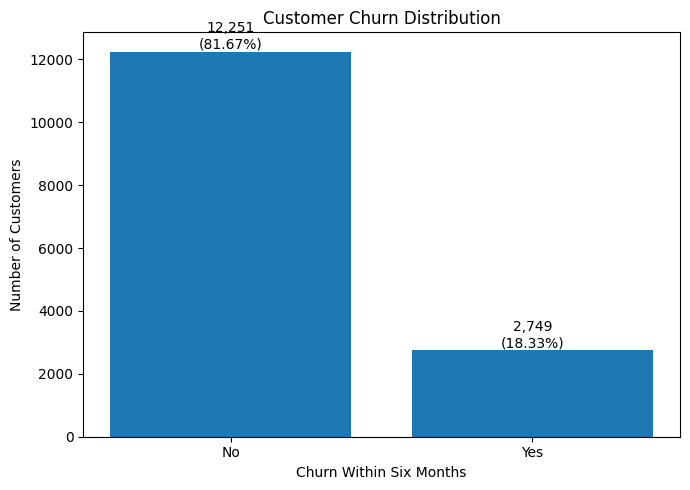

In [17]:
# Visualise the distribution of the churn target

target_order = ["No", "Yes"]

target_counts = (
    df["Churn_Within_6M"]
    .value_counts()
    .reindex(target_order)
)

target_percentages = (
    target_counts
    .div(len(df))
    .mul(100)
)

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    target_counts.index,
    target_counts.values
)

for bar, percentage in zip(bars, target_percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom"
    )

ax.set_title("Customer Churn Distribution")
ax.set_xlabel("Churn Within Six Months")
ax.set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

**Interpretation:** Most customers did not churn within the six-month period. Approximately 18.33% of customers churned, compared with 81.67% who remained. This class imbalance will be considered during model evaluation, and the models will not be judged by accuracy alone.

### 5.2 Customer Satisfaction and Churn

The churn rate is compared across satisfaction scores to examine whether customers with lower satisfaction are more likely to leave the bank.

,Satisfaction_Score,Total_Customers,Churned_Customers,Churn_Rate_Pct
0,1,72,30,41.67
1,2,786,219,27.86
2,3,3774,718,19.02
3,4,6213,1100,17.70
4,5,4155,682,16.41


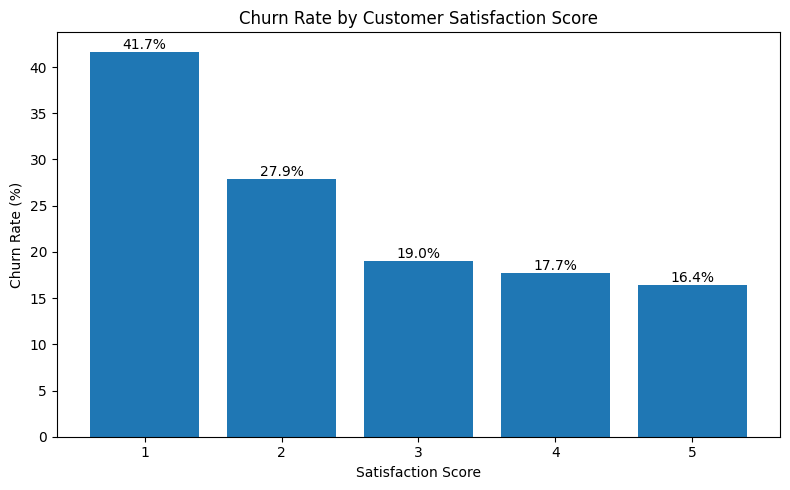

In [18]:
# Compare churn rates across satisfaction scores

satisfaction_summary = (
    df.groupby("Satisfaction_Score")["Churn_Within_6M"]
    .agg(
        Total_Customers="count",
        Churned_Customers=lambda values: (values == "Yes").sum()
    )
    .reset_index()
)

satisfaction_summary["Churn_Rate_Pct"] = (
    satisfaction_summary["Churned_Customers"]
    / satisfaction_summary["Total_Customers"]
    * 100
).round(2)

display(satisfaction_summary)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    satisfaction_summary["Satisfaction_Score"],
    satisfaction_summary["Churn_Rate_Pct"]
)

for bar, rate in zip(
    bars,
    satisfaction_summary["Churn_Rate_Pct"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Churn Rate by Customer Satisfaction Score")
plt.xlabel("Satisfaction Score")
plt.ylabel("Churn Rate (%)")
plt.xticks(satisfaction_summary["Satisfaction_Score"])
plt.tight_layout()
plt.show()

**Interpretation:** Customer churn generally decreased as satisfaction increased. Customers with a satisfaction score of 1 recorded the highest churn rate at 41.67%, followed by 27.86% among customers with a score of 2. In comparison, customers with satisfaction scores of 4 and 5 recorded lower churn rates of 17.70% and 16.41%, respectively.

This suggests that lower customer satisfaction is associated with a greater likelihood of churn. However, the score-1 category contained only 72 customers, so its comparatively high churn rate should be interpreted cautiously. The relationship observed here indicates association and does not by itself prove that dissatisfaction directly caused churn.

### 5.3 Customer Inactivity and Churn

The churn rate is examined across the number of months a customer was inactive during the previous 12 months. This helps determine whether prolonged inactivity is associated with a greater likelihood of churn.

,Months_Inactive_12M,Total_Customers,Churned_Customers,Churn_Rate_Pct
0,0,2900,212,7.31
1,1,4453,500,11.23
2,2,3662,604,16.49
3,3,2351,578,24.59
4,4,1063,481,45.25
5,5,384,232,60.42
6,6,133,94,70.68
7,7,40,35,87.50
8,8,14,13,92.86


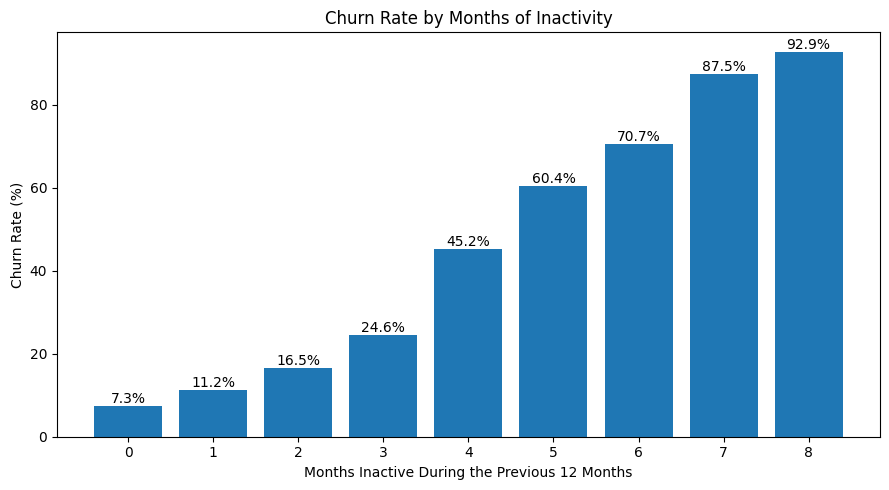

In [19]:
# Compare churn rates across months of inactivity

inactivity_summary = (
    df.groupby("Months_Inactive_12M")["Churn_Within_6M"]
    .agg(
        Total_Customers="count",
        Churned_Customers=lambda values: (values == "Yes").sum()
    )
    .reset_index()
)

inactivity_summary["Churn_Rate_Pct"] = (
    inactivity_summary["Churned_Customers"]
    / inactivity_summary["Total_Customers"]
    * 100
).round(2)

display(inactivity_summary)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    inactivity_summary["Months_Inactive_12M"],
    inactivity_summary["Churn_Rate_Pct"]
)

for bar, rate in zip(
    bars,
    inactivity_summary["Churn_Rate_Pct"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Churn Rate by Months of Inactivity")
plt.xlabel("Months Inactive During the Previous 12 Months")
plt.ylabel("Churn Rate (%)")
plt.xticks(inactivity_summary["Months_Inactive_12M"])
plt.tight_layout()
plt.show()

**Interpretation:** Customer churn increased consistently as the number of inactive months increased. Customers with no inactive months recorded a churn rate of only 7.31%, while the churn rate rose to 24.59% among customers inactive for three months and 45.25% among those inactive for four months.

Customers inactive for five or more months recorded particularly high churn rates. This suggests that prolonged account inactivity is strongly associated with customer churn and may be an important predictor in the modelling stage. However, the estimates for seven and eight inactive months should be interpreted cautiously because those categories contained relatively few customers.

### 5.4 Transaction Frequency and Churn

The churn rate is compared across transaction-frequency categories to examine whether customers with lower account activity are more likely to leave the bank.

,Transaction_Frequency,Total_Customers,Churned_Customers,Churn_Rate_Pct
0,Low,699,340,48.64
1,Medium,4958,1099,22.17
2,High,6907,1047,15.16
3,Very High,2436,263,10.80


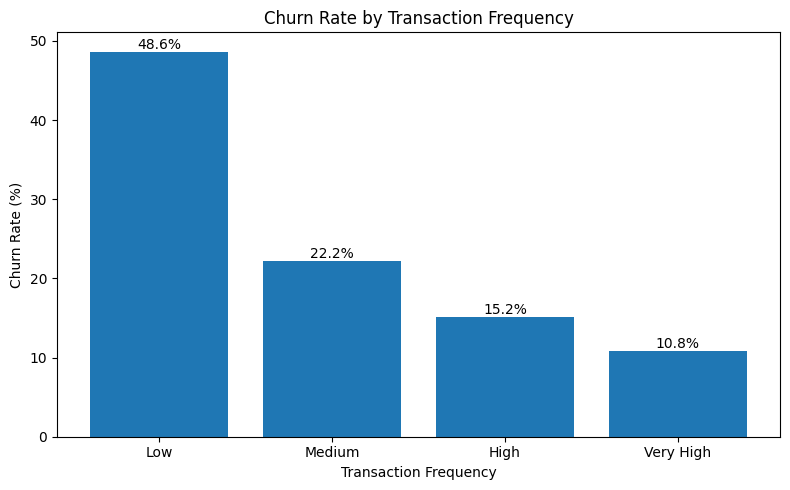

In [20]:
# Compare churn rates across transaction-frequency categories

frequency_order = [
    "Low",
    "Medium",
    "High",
    "Very High"
]

transaction_frequency_summary = (
    df.groupby("Transaction_Frequency")["Churn_Within_6M"]
    .agg(
        Total_Customers="count",
        Churned_Customers=lambda values: (values == "Yes").sum()
    )
    .reindex(frequency_order)
    .reset_index()
)

transaction_frequency_summary["Churn_Rate_Pct"] = (
    transaction_frequency_summary["Churned_Customers"]
    / transaction_frequency_summary["Total_Customers"]
    * 100
).round(2)

display(transaction_frequency_summary)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    transaction_frequency_summary["Transaction_Frequency"],
    transaction_frequency_summary["Churn_Rate_Pct"]
)

for bar, rate in zip(
    bars,
    transaction_frequency_summary["Churn_Rate_Pct"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Churn Rate by Transaction Frequency")
plt.xlabel("Transaction Frequency")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

**Interpretation:** Churn decreased steadily as transaction frequency increased. Customers in the low-frequency category recorded the highest churn rate at 48.64%, compared with 22.17% for medium-frequency customers, 15.16% for high-frequency customers and 10.80% for very-high-frequency customers.

This indicates that customers who transact less frequently are considerably more likely to churn. Transaction activity may therefore provide an important early warning signal for identifying customers at risk of leaving the bank. However, this relationship represents an association and does not by itself prove that low transaction frequency directly causes churn.

### 5.5 Loan Status and Churn

The churn rate is compared across loan-status categories to examine whether repayment difficulty or other loan conditions are associated with a greater likelihood of customer churn.

,Loan_Status,Total_Customers,Churned_Customers,Churn_Rate_Pct
0,No Loan,8570,1621,18.91
1,Current,3848,619,16.09
2,Completed,1717,312,18.17
3,Delinquent,609,122,20.03
4,Defaulted,256,75,29.30


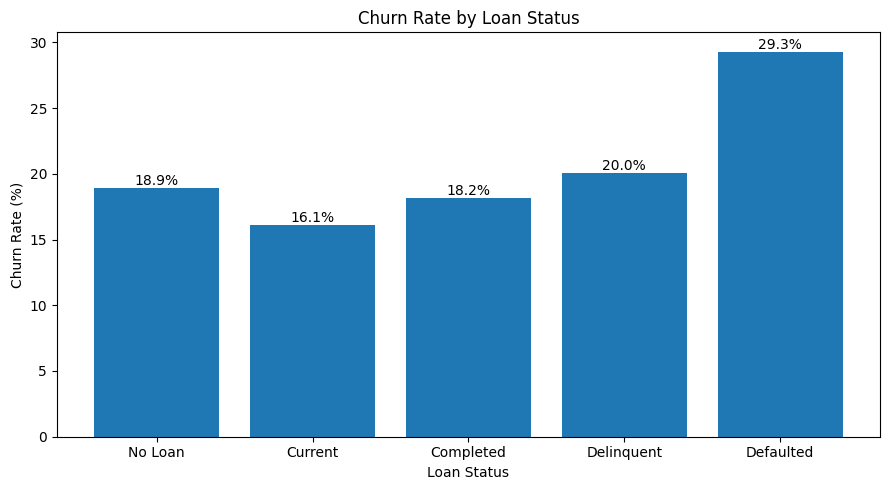

In [21]:
# Compare churn rates across loan-status categories

loan_order = [
    "No Loan",
    "Current",
    "Completed",
    "Delinquent",
    "Defaulted"
]

loan_status_summary = (
    df.groupby("Loan_Status")["Churn_Within_6M"]
    .agg(
        Total_Customers="count",
        Churned_Customers=lambda values: (values == "Yes").sum()
    )
    .reindex(loan_order)
    .reset_index()
)

loan_status_summary["Churn_Rate_Pct"] = (
    loan_status_summary["Churned_Customers"]
    / loan_status_summary["Total_Customers"]
    * 100
).round(2)

display(loan_status_summary)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    loan_status_summary["Loan_Status"],
    loan_status_summary["Churn_Rate_Pct"]
)

for bar, rate in zip(
    bars,
    loan_status_summary["Churn_Rate_Pct"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Churn Rate by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

**Interpretation:** Customers with defaulted loans recorded the highest churn rate at 29.30%, followed by delinquent customers at 20.03%. Customers whose loans were current recorded the lowest churn rate at 16.09%.

The differences among customers with no loan, completed loans, current loans and delinquent loans were relatively modest. However, the noticeably higher churn rate among defaulted customers suggests that serious repayment difficulty may be associated with a greater likelihood of leaving the bank. This relationship is associative and does not establish that loan default directly caused churn.

### 5.6 Unresolved Complaints and Churn

Customers are grouped according to the number of unresolved complaints recorded during the previous six months. Their churn rates are compared to determine whether unresolved service issues are associated with a greater likelihood of leaving the bank.

,Unresolved_Complaint_Group,Total_Customers,Churned_Customers,Churn_Rate_Pct
0,0,14579.0,2617.0,17.95
1,1,416.0,129.0,31.01
2,2,5.0,3.0,60.00
3,3 or more,NaN,NaN,NaN


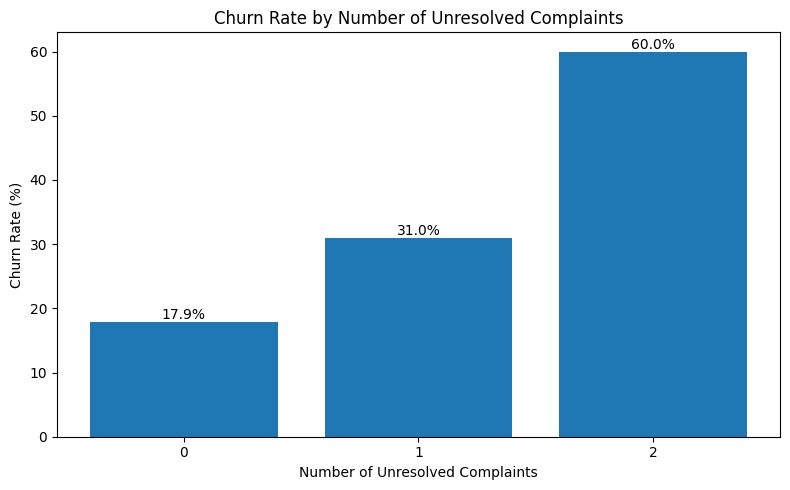

In [22]:
# Group customers by number of unresolved complaints

unresolved_complaint_group = np.select(
    [
        df["Unresolved_Complaints_6M"] == 0,
        df["Unresolved_Complaints_6M"] == 1,
        df["Unresolved_Complaints_6M"] == 2
    ],
    [
        "0",
        "1",
        "2"
    ],
    default="3 or more"
)

complaint_group_order = [
    "0",
    "1",
    "2",
    "3 or more"
]

unresolved_complaint_summary = (
    df.assign(
        Unresolved_Complaint_Group=unresolved_complaint_group
    )
    .groupby("Unresolved_Complaint_Group")["Churn_Within_6M"]
    .agg(
        Total_Customers="count",
        Churned_Customers=lambda values: (values == "Yes").sum()
    )
    .reindex(complaint_group_order)
    .reset_index()
)

unresolved_complaint_summary["Churn_Rate_Pct"] = (
    unresolved_complaint_summary["Churned_Customers"]
    / unresolved_complaint_summary["Total_Customers"]
    * 100
).round(2)

display(unresolved_complaint_summary)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    unresolved_complaint_summary["Unresolved_Complaint_Group"],
    unresolved_complaint_summary["Churn_Rate_Pct"]
)

for bar, rate in zip(
    bars,
    unresolved_complaint_summary["Churn_Rate_Pct"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Churn Rate by Number of Unresolved Complaints")
plt.xlabel("Number of Unresolved Complaints")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

In [23]:
# Remove the empty complaint category from the summary table

unresolved_complaint_summary = (
    unresolved_complaint_summary
    .dropna(subset=["Total_Customers"])
    .reset_index(drop=True)
)

display(unresolved_complaint_summary)

,Unresolved_Complaint_Group,Total_Customers,Churned_Customers,Churn_Rate_Pct
0,0,14579.0,2617.0,17.95
1,1,416.0,129.0,31.01
2,2,5.0,3.0,60.00


**Interpretation:** Customers with unresolved complaints recorded higher churn rates. The churn rate increased from 17.95% among customers with no unresolved complaints to 31.01% among those with one unresolved complaint.

Customers with two unresolved complaints recorded a churn rate of 60.00%. However, this category contained only five customers, so the result should be interpreted cautiously and should not be treated as a stable estimate.

Overall, the results suggest that unresolved service issues may be associated with a greater likelihood of customer churn. The relationship is associative and does not by itself establish causation.

### 5.7 Account-Balance Change and Churn

Customers are grouped according to whether their account balance decreased, remained relatively stable or increased during the previous three months. Their churn rates are compared to examine whether declining balances are associated with a greater likelihood of churn.

,Balance_Change_Group,Total_Customers,Churned_Customers,Churn_Rate_Pct
0,Decreased by more than 10%,3741,735,19.65
1,Relatively stable,6338,1177,18.57
2,Increased by more than 10%,4921,837,17.01


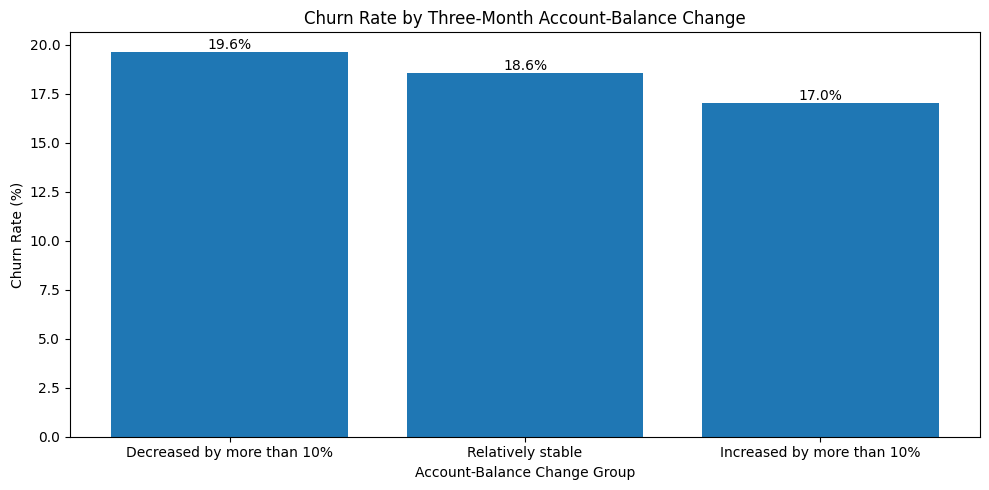

In [24]:
# Group customers according to their three-month balance change

balance_change_group = np.select(
    [
        df["Balance_Change_Pct_3M"] < -0.10,
        df["Balance_Change_Pct_3M"].between(-0.10, 0.10),
        df["Balance_Change_Pct_3M"] > 0.10
    ],
    [
        "Decreased by more than 10%",
        "Relatively stable",
        "Increased by more than 10%"
    ],
    default="Unknown"
)

balance_group_order = [
    "Decreased by more than 10%",
    "Relatively stable",
    "Increased by more than 10%"
]

balance_change_summary = (
    df.assign(Balance_Change_Group=balance_change_group)
    .groupby("Balance_Change_Group")["Churn_Within_6M"]
    .agg(
        Total_Customers="count",
        Churned_Customers=lambda values: (values == "Yes").sum()
    )
    .reindex(balance_group_order)
    .reset_index()
)

balance_change_summary["Churn_Rate_Pct"] = (
    balance_change_summary["Churned_Customers"]
    / balance_change_summary["Total_Customers"]
    * 100
).round(2)

display(balance_change_summary)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    balance_change_summary["Balance_Change_Group"],
    balance_change_summary["Churn_Rate_Pct"]
)

for bar, rate in zip(
    bars,
    balance_change_summary["Churn_Rate_Pct"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Churn Rate by Three-Month Account-Balance Change")
plt.xlabel("Account-Balance Change Group")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

**Interpretation:** Customers whose account balances decreased by more than 10% recorded the highest churn rate at 19.65%. This was followed by 18.57% among customers whose balances remained relatively stable and 17.01% among customers whose balances increased by more than 10%.

The pattern suggests that declining account balances may be associated with a slightly greater likelihood of churn. However, the differences between the three groups were relatively modest, indicating that balance change alone may not be a strong indicator of churn compared with variables such as inactivity and transaction frequency.

### 5.8 Number of Banking Products and Churn

The churn rate is compared across the number of banking products held by each customer. This helps examine whether customers with more extensive relationships with the bank are less likely to churn.

,Number_of_Products,Total_Customers,Churned_Customers,Churn_Rate_Pct
0,1,6424,1404,21.86
1,2,4858,893,18.38
2,3,2332,325,13.94
3,4,934,95,10.17
4,5,325,23,7.08
5,6,127,9,7.09


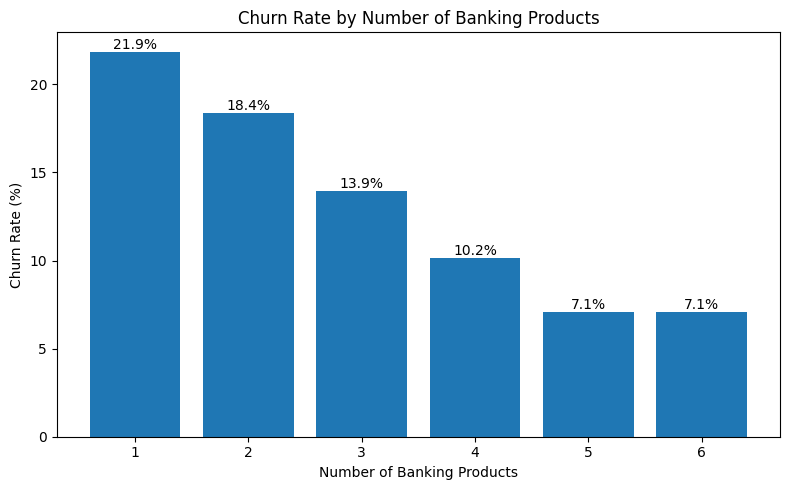

In [25]:
# Compare churn rates by number of banking products

product_summary = (
    df.groupby("Number_of_Products")["Churn_Within_6M"]
    .agg(
        Total_Customers="count",
        Churned_Customers=lambda values: (values == "Yes").sum()
    )
    .reset_index()
    .sort_values("Number_of_Products")
)

product_summary["Churn_Rate_Pct"] = (
    product_summary["Churned_Customers"]
    / product_summary["Total_Customers"]
    * 100
).round(2)

display(product_summary)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    product_summary["Number_of_Products"],
    product_summary["Churn_Rate_Pct"]
)

for bar, rate in zip(
    bars,
    product_summary["Churn_Rate_Pct"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Churn Rate by Number of Banking Products")
plt.xlabel("Number of Banking Products")
plt.ylabel("Churn Rate (%)")
plt.xticks(product_summary["Number_of_Products"])
plt.tight_layout()
plt.show()

**Interpretation:** Churn generally decreased as the number of banking products held by a customer increased. Customers with only one banking product recorded the highest churn rate at 21.86%, while the churn rate declined to 13.94% among customers with three products and approximately 7.1% among customers with five or six products.

This pattern suggests that customers with broader relationships with the bank may be less likely to churn. Holding multiple products may reflect greater engagement or stronger dependence on the bank's services. However, the six-product category contained only 127 customers, so its churn rate should be interpreted cautiously. The result shows association and does not prove that adding more products will directly prevent churn.

### 5.9 Active-Member Status and Churn

The churn rate is compared between active and inactive customers. This helps determine whether customers who regularly use their accounts are less likely to leave the bank.

,Active_Member,Total_Customers,Churned_Customers,Churn_Rate_Pct
0,Yes,12819,1661,12.96
1,No,2181,1088,49.89


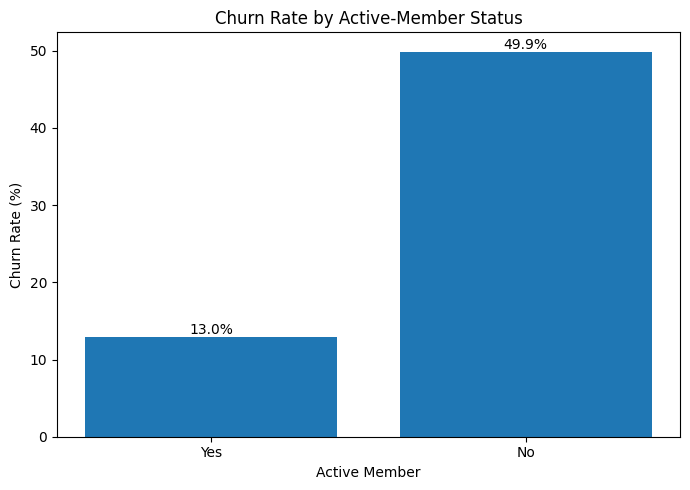

In [26]:
# Compare churn rates by active-member status

active_member_order = ["Yes", "No"]

active_member_summary = (
    df.groupby("Active_Member")["Churn_Within_6M"]
    .agg(
        Total_Customers="count",
        Churned_Customers=lambda values: (values == "Yes").sum()
    )
    .reindex(active_member_order)
    .reset_index()
)

active_member_summary["Churn_Rate_Pct"] = (
    active_member_summary["Churned_Customers"]
    / active_member_summary["Total_Customers"]
    * 100
).round(2)

display(active_member_summary)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    active_member_summary["Active_Member"],
    active_member_summary["Churn_Rate_Pct"]
)

for bar, rate in zip(
    bars,
    active_member_summary["Churn_Rate_Pct"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Churn Rate by Active-Member Status")
plt.xlabel("Active Member")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

**Interpretation:** Inactive customers recorded a churn rate of 49.89%, compared with only 12.96% among active customers. This indicates that customers classified as inactive were considerably more likely to leave the bank.

Active-member status may therefore be useful for identifying customers at risk of churn. However, this variable was derived from transaction activity, recency and months of inactivity, so its relationship with churn partly reflects information already contained in those underlying behavioural variables. The result represents association rather than proof of causation.

### 5.10 Account at Another Bank and Churn

The churn rate is compared between customers who have an active account at another bank and those who do not. This helps examine whether customers with alternative banking relationships are more likely to churn.

,Active_Account_at_Another_Bank,Total_Customers,Churned_Customers,Churn_Rate_Pct
0,No,8800,1457,16.56
1,Yes,6200,1292,20.84


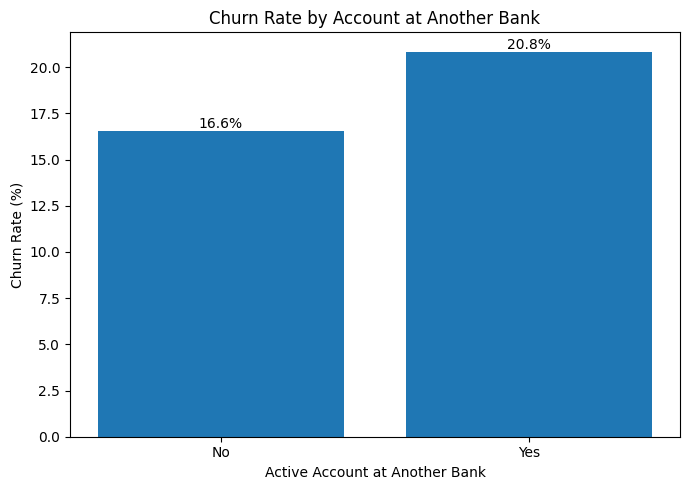

In [27]:
# Compare churn rates by whether the customer has an account at another bank

another_bank_order = ["No", "Yes"]

another_bank_summary = (
    df.groupby("Active_Account_at_Another_Bank")["Churn_Within_6M"]
    .agg(
        Total_Customers="count",
        Churned_Customers=lambda values: (values == "Yes").sum()
    )
    .reindex(another_bank_order)
    .reset_index()
)

another_bank_summary["Churn_Rate_Pct"] = (
    another_bank_summary["Churned_Customers"]
    / another_bank_summary["Total_Customers"]
    * 100
).round(2)

display(another_bank_summary)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    another_bank_summary["Active_Account_at_Another_Bank"],
    another_bank_summary["Churn_Rate_Pct"]
)

for bar, rate in zip(
    bars,
    another_bank_summary["Churn_Rate_Pct"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Churn Rate by Account at Another Bank")
plt.xlabel("Active Account at Another Bank")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

**Interpretation:** Customers with an active account at another bank recorded a churn rate of 20.84%, compared with 16.56% among customers without another active banking relationship.

This suggests that customers who maintain accounts with competing banks may be somewhat more likely to churn, possibly because they have an available alternative when they become dissatisfied or less engaged. However, the difference was moderate, and the result shows association rather than proving that having another bank account directly caused churn.

### 5.11 Fee Burden and Churn

Customers are divided into four groups based on their monthly bank fees as a percentage of income. The churn rates are compared to examine whether a higher fee burden is associated with a greater likelihood of leaving the bank.

,Fee_Burden_Group,Minimum_Fee_to_Income_Pct,Maximum_Fee_to_Income_Pct,Total_Customers,Churned_Customers,Churn_Rate_Pct
0,Lowest 25%,0.04,0.53,3793,719,18.96
1,Low-Middle 25%,0.54,0.94,3717,672,18.08
2,High-Middle 25%,0.95,1.74,3748,607,16.20
3,Highest 25%,1.75,17.00,3742,751,20.07


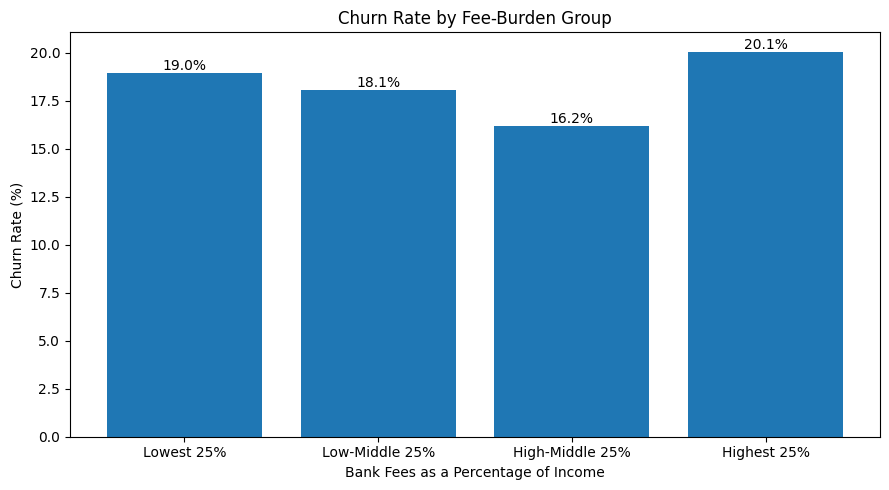

In [28]:
# Divide customers into four fee-burden groups

fee_analysis = df[
    ["Fee_to_Income_Pct", "Churn_Within_6M"]
].copy()

fee_group_order = [
    "Lowest 25%",
    "Low-Middle 25%",
    "High-Middle 25%",
    "Highest 25%"
]

fee_analysis["Fee_Burden_Group"] = pd.qcut(
    fee_analysis["Fee_to_Income_Pct"],
    q=4,
    labels=fee_group_order
)

fee_burden_summary = (
    fee_analysis
    .groupby("Fee_Burden_Group", observed=False)
    .agg(
        Minimum_Fee_to_Income_Pct=(
            "Fee_to_Income_Pct", "min"
        ),
        Maximum_Fee_to_Income_Pct=(
            "Fee_to_Income_Pct", "max"
        ),
        Total_Customers=(
            "Churn_Within_6M", "count"
        ),
        Churned_Customers=(
            "Churn_Within_6M",
            lambda values: (values == "Yes").sum()
        )
    )
    .reindex(fee_group_order)
    .reset_index()
)

fee_burden_summary["Churn_Rate_Pct"] = (
    fee_burden_summary["Churned_Customers"]
    / fee_burden_summary["Total_Customers"]
    * 100
).round(2)

display(fee_burden_summary)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    fee_burden_summary["Fee_Burden_Group"],
    fee_burden_summary["Churn_Rate_Pct"]
)

for bar, rate in zip(
    bars,
    fee_burden_summary["Churn_Rate_Pct"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Churn Rate by Fee-Burden Group")
plt.xlabel("Bank Fees as a Percentage of Income")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

**Interpretation:** Customers in the highest fee-burden group recorded the highest churn rate at 20.07%, compared with 16.20% among customers in the high-middle group. However, the relationship was not consistently increasing across all four groups, because the lowest fee-burden group also recorded a relatively high churn rate of 18.96%.

This suggests that customers facing the greatest fee burden may be somewhat more likely to churn, but fee burden alone does not show a strong or perfectly linear relationship with churn. Its effect may also interact with other factors such as income, transaction activity, customer satisfaction and account type.

### 5.12 Customer Age and Churn

Customers are grouped into age categories, and their churn rates are compared to examine whether the likelihood of leaving the bank differs across stages of adulthood.

,Age_Group,Total_Customers,Churned_Customers,Churn_Rate_Pct
0,18–25,572,119,20.80
1,26–35,5003,997,19.93
2,36–45,4703,822,17.48
3,46–55,3063,506,16.52
4,56–65,1389,251,18.07
5,66–75,270,54,20.00


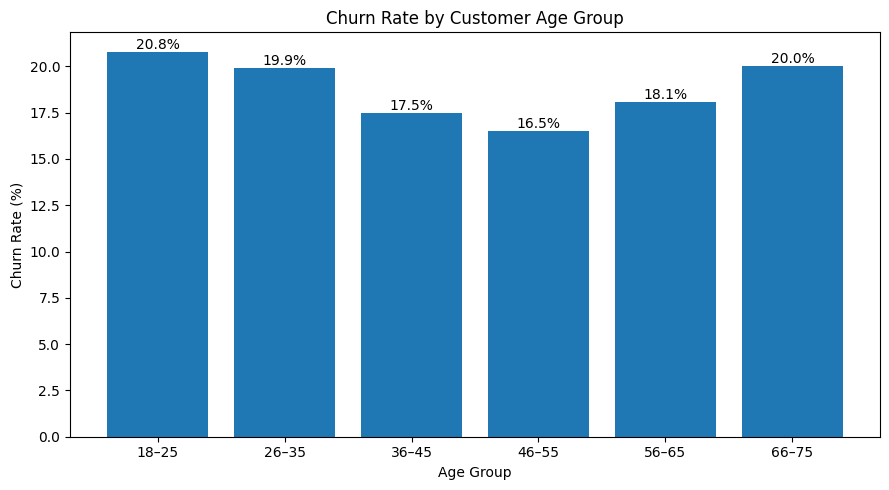

In [29]:
# Group customers into age categories

age_bins = [17, 25, 35, 45, 55, 65, 75]

age_labels = [
    "18–25",
    "26–35",
    "36–45",
    "46–55",
    "56–65",
    "66–75"
]

age_analysis = df[
    ["Age", "Churn_Within_6M"]
].copy()

age_analysis["Age_Group"] = pd.cut(
    age_analysis["Age"],
    bins=age_bins,
    labels=age_labels
)

age_summary = (
    age_analysis
    .groupby("Age_Group", observed=False)
    .agg(
        Total_Customers=(
            "Churn_Within_6M", "count"
        ),
        Churned_Customers=(
            "Churn_Within_6M",
            lambda values: (values == "Yes").sum()
        )
    )
    .reindex(age_labels)
    .reset_index()
)

age_summary["Churn_Rate_Pct"] = (
    age_summary["Churned_Customers"]
    / age_summary["Total_Customers"]
    * 100
).round(2)

display(age_summary)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    age_summary["Age_Group"],
    age_summary["Churn_Rate_Pct"]
)

for bar, rate in zip(
    bars,
    age_summary["Churn_Rate_Pct"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Churn Rate by Customer Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

**Interpretation:** Churn varied moderately across customer age groups. Customers aged 18–25 recorded the highest churn rate at 20.80%, followed closely by customers aged 66–75 at 20.00% and those aged 26–35 at 19.93%.

The lowest churn rate was recorded among customers aged 46–55 at 16.52%. Overall, the pattern was mildly U-shaped, with somewhat higher churn among younger and older customers and lower churn among middle-aged customers. However, the youngest and oldest age groups contained fewer customers, particularly the 66–75 category, so their estimates should be interpreted cautiously. Age alone does not appear to be as strongly associated with churn as behavioural variables such as inactivity and transaction frequency.

### 5.13 Gender and Churn

The churn rate is compared across gender categories as part of the demographic and fairness assessment. The purpose is to identify whether meaningful differences appear in the dataset, not to treat gender as a direct cause of churn.

,Gender,Total_Customers,Churned_Customers,Churn_Rate_Pct
0,Female,7253,1323,18.24
1,Male,7747,1426,18.41


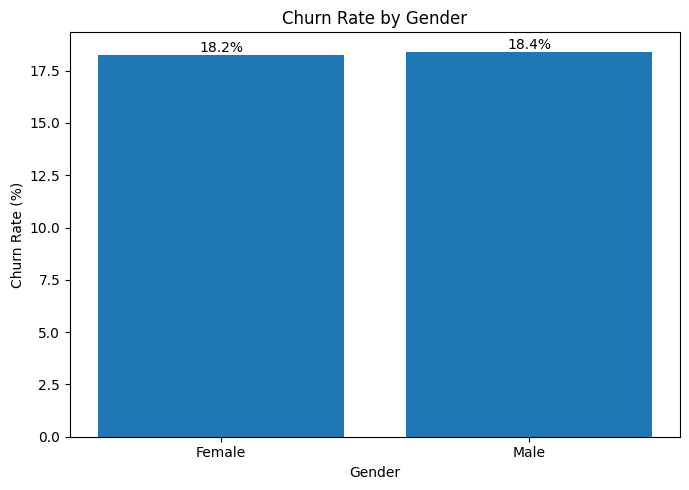

In [30]:
# Compare churn rates across gender categories

gender_summary = (
    df.groupby("Gender")["Churn_Within_6M"]
    .agg(
        Total_Customers="count",
        Churned_Customers=lambda values: (values == "Yes").sum()
    )
    .reset_index()
)

gender_summary["Churn_Rate_Pct"] = (
    gender_summary["Churned_Customers"]
    / gender_summary["Total_Customers"]
    * 100
).round(2)

display(gender_summary)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    gender_summary["Gender"],
    gender_summary["Churn_Rate_Pct"]
)

for bar, rate in zip(
    bars,
    gender_summary["Churn_Rate_Pct"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

**Interpretation:** Churn rates were nearly identical across gender categories. Female customers recorded a churn rate of 18.24%, while male customers recorded a churn rate of 18.41%, representing a difference of only 0.17 percentage points.

This suggests that gender is not meaningfully associated with churn in this dataset. The result is also important from a fairness perspective because it does not indicate a substantial churn disparity between the two gender groups.

### 5.14 Account Type and Churn

The churn rate is compared across account types to examine whether customers using different banking-account products have different likelihoods of leaving the bank.

,Account_Type,Total_Customers,Churned_Customers,Churn_Rate_Pct
0,Savings,8260,1573,19.04
1,Current,3014,569,18.88
2,Salary,3505,550,15.69
3,Student,221,57,25.79


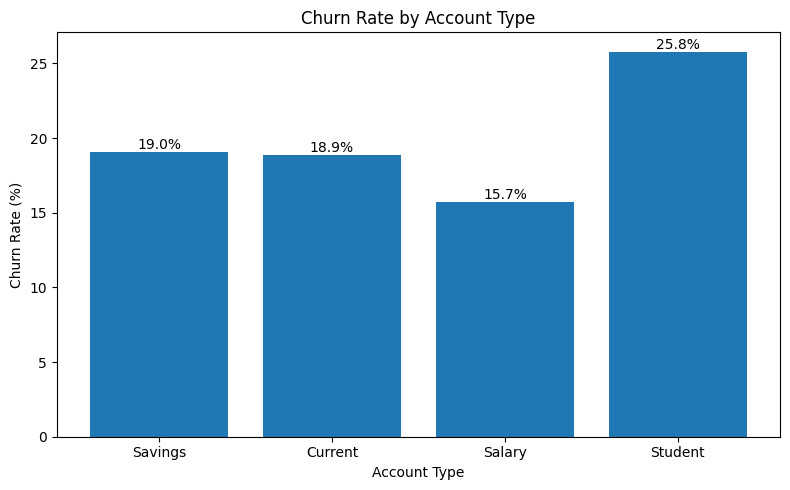

In [31]:
# Compare churn rates across account types

account_type_order = [
    "Savings",
    "Current",
    "Salary",
    "Student"
]

account_type_summary = (
    df.groupby("Account_Type")["Churn_Within_6M"]
    .agg(
        Total_Customers="count",
        Churned_Customers=lambda values: (values == "Yes").sum()
    )
    .reindex(account_type_order)
    .reset_index()
)

account_type_summary["Churn_Rate_Pct"] = (
    account_type_summary["Churned_Customers"]
    / account_type_summary["Total_Customers"]
    * 100
).round(2)

display(account_type_summary)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    account_type_summary["Account_Type"],
    account_type_summary["Churn_Rate_Pct"]
)

for bar, rate in zip(
    bars,
    account_type_summary["Churn_Rate_Pct"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Churn Rate by Account Type")
plt.xlabel("Account Type")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

**Interpretation:** Customers with student accounts recorded the highest churn rate at 25.79%, while salary-account customers recorded the lowest churn rate at 15.69%. Savings and current accounts had similar churn rates of 19.04% and 18.88%, respectively.

The relatively low churn rate among salary-account customers may reflect a more stable relationship with the bank through regular salary inflows. However, the student-account group contained only 221 customers, which was considerably smaller than the other groups. Its comparatively high churn rate should therefore be interpreted cautiously. Account type is associated with churn in this comparison, but it does not independently explain why customers leave.

### 5.15 Digital Engagement and Churn

The churn rate is compared across digital-engagement categories to examine whether customers who engage more actively with the bank's digital channels are less likely to leave.

,Digital_Engagement,Total_Customers,Churned_Customers,Churn_Rate_Pct
0,Low,401,129,32.17
1,Medium,3487,745,21.37
2,High,11112,1875,16.87


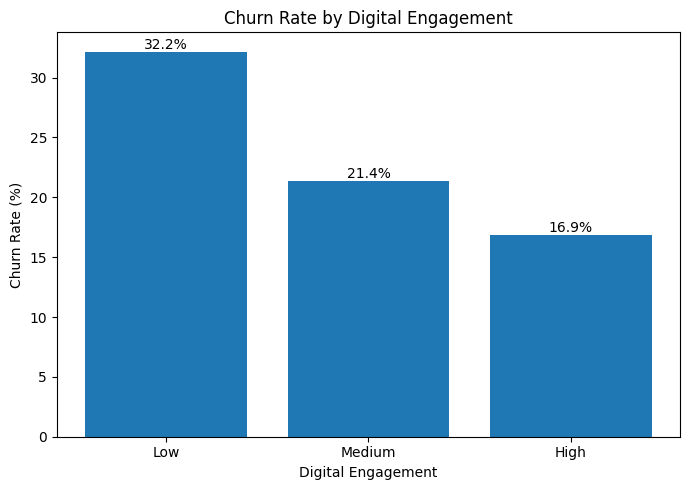

In [32]:
# Compare churn rates across digital-engagement categories

digital_engagement_order = [
    "Low",
    "Medium",
    "High"
]

digital_engagement_summary = (
    df.groupby("Digital_Engagement")["Churn_Within_6M"]
    .agg(
        Total_Customers="count",
        Churned_Customers=lambda values: (values == "Yes").sum()
    )
    .reindex(digital_engagement_order)
    .reset_index()
)

digital_engagement_summary["Churn_Rate_Pct"] = (
    digital_engagement_summary["Churned_Customers"]
    / digital_engagement_summary["Total_Customers"]
    * 100
).round(2)

display(digital_engagement_summary)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    digital_engagement_summary["Digital_Engagement"],
    digital_engagement_summary["Churn_Rate_Pct"]
)

for bar, rate in zip(
    bars,
    digital_engagement_summary["Churn_Rate_Pct"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Churn Rate by Digital Engagement")
plt.xlabel("Digital Engagement")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

**Interpretation:** Churn decreased as digital engagement increased. Customers with low digital engagement recorded the highest churn rate at 32.17%, followed by 21.37% among customers with medium engagement and 16.87% among highly engaged customers.

This suggests that customers who engage more actively with the bank's digital services are less likely to churn. However, the low-engagement group contained only 401 customers, so its estimated churn rate should be interpreted cautiously. Digital engagement was also derived partly from transaction activity and digital-channel usage, meaning that its relationship with churn may overlap with other behavioural variables already examined.

### 5.16 Correlation of Numerical Variables with Churn

Selected numerical variables are correlated with the churn outcome to examine the direction and strength of their linear relationships. For this analysis, churn is temporarily encoded as 1 for customers who churned and 0 for customers who remained.

,Correlation_with_Churn
Months_Inactive_12M,0.328
Days_Since_Last_Transaction,0.182
Unresolved_Complaints_6M,0.058
Fee_to_Income_Pct,0.052
Complaints_6M,0.035
Customer_Service_Contacts_6M,0.007
Failed_Transactions_3M,-0.016
Age,-0.022
Balance_Change_Pct_3M,-0.033
Account_Balance_NGN,-0.034


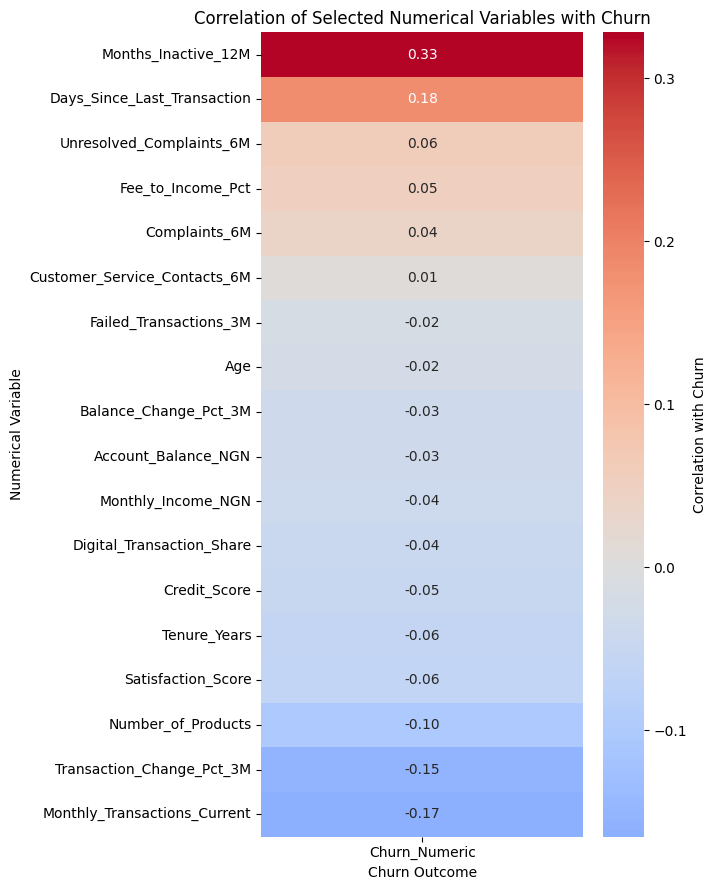

In [33]:
# Examine correlations between selected numerical variables and churn

correlation_features = [
    "Age",
    "Monthly_Income_NGN",
    "Tenure_Years",
    "Account_Balance_NGN",
    "Balance_Change_Pct_3M",
    "Number_of_Products",
    "Digital_Transaction_Share",
    "Monthly_Transactions_Current",
    "Transaction_Change_Pct_3M",
    "Months_Inactive_12M",
    "Days_Since_Last_Transaction",
    "Failed_Transactions_3M",
    "Customer_Service_Contacts_6M",
    "Complaints_6M",
    "Unresolved_Complaints_6M",
    "Fee_to_Income_Pct",
    "Satisfaction_Score",
    "Credit_Score"
]

correlation_data = df[correlation_features].copy()

correlation_data["Churn_Numeric"] = (
    df["Churn_Within_6M"]
    .map({"No": 0, "Yes": 1})
)

churn_correlations = (
    correlation_data
    .corr(numeric_only=True)[["Churn_Numeric"]]
    .drop(index="Churn_Numeric")
    .sort_values(
        by="Churn_Numeric",
        ascending=False
    )
)

display(
    churn_correlations.rename(
        columns={"Churn_Numeric": "Correlation_with_Churn"}
    ).round(3)
)

plt.figure(figsize=(7, 9))

sns.heatmap(
    churn_correlations,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    cbar_kws={
        "label": "Correlation with Churn"
    }
)

plt.title("Correlation of Selected Numerical Variables with Churn")
plt.xlabel("Churn Outcome")
plt.ylabel("Numerical Variable")
plt.tight_layout()
plt.show()

**Interpretation:** Months of inactivity had the strongest positive numerical correlation with churn at 0.328, indicating that customers with longer periods of inactivity were more likely to leave. Days since the last transaction also showed a positive relationship with churn at 0.182.

Current monthly transaction count recorded the strongest negative correlation with churn at −0.165, followed by the three-month transaction-change percentage at −0.154. This indicates that customers with greater transaction activity and improving transaction patterns were generally less likely to churn. The number of banking products also had a negative correlation of −0.104.

Most remaining numerical variables had relatively weak linear correlations with churn. This does not necessarily mean that they are unimportant, because some relationships may be non-linear or may become useful when combined with other variables. Overall, the findings suggest that customer inactivity and declining engagement are more closely associated with churn than most demographic or financial variables.

### 5.17 Exploratory Data Analysis Summary

The exploratory analysis identified customer activity and engagement as the most noticeable indicators of churn. Churn increased substantially as the number of inactive months rose, while customers with higher transaction frequency, greater digital engagement and active-member status recorded considerably lower churn rates.

Customer satisfaction was also associated with churn. Customers with lower satisfaction scores were more likely to leave, although some of the lowest-score categories contained relatively few customers. Customers with unresolved complaints and defaulted loans also recorded higher churn rates, but estimates based on small groups were interpreted cautiously.

Customers holding more banking products generally had lower churn rates, suggesting that broader relationships with the bank may be associated with stronger retention. Customers with active accounts at other banks had a moderately higher churn rate, while declining account balances and high fee burden showed weaker associations.

Demographic variables were less strongly associated with churn. Gender showed almost no difference, while age displayed a mild U-shaped pattern, with somewhat higher churn among younger and older customers. Account type showed some variation, although the relatively small student-account group limits the strength of conclusions about that category.

The correlation analysis supported the graphical findings. Months of inactivity had the strongest positive numerical correlation with churn, while current transaction count and transaction change had the strongest negative correlations. No single numerical variable had an extremely high correlation with churn, indicating that the prediction task requires the combined contribution of multiple customer characteristics.

These results represent associations within a synthetic educational dataset and should not be interpreted as proof of causal relationships or as conclusions about all Nigerian bank customers.

## 6. Data Preprocessing and Model Development

The dataset is prepared for machine-learning modelling. The preprocessing approach separates the churn outcome from the predictor variables, preserves customer identifiers for later individual explanations, and prevents identifiers or constant contextual variables from entering the models.

### 6.1 Prepare the Predictors and Target

The churn outcome is encoded as 0 for customers who did not churn and 1 for customers who churned. `Customer_ID` is retained separately for later customer-level reporting, while `Customer_ID` and `Reference_Date` are excluded from the predictor variables because they should not be used to train the models.

In [34]:
# Make a separate copy for the modelling stage

duplicate_count = df.duplicated().sum()

model_data = (
    df
    .drop_duplicates()
    .reset_index(drop=True)
    .copy()
)

print("Exact duplicate rows removed:", duplicate_count)


# Define and encode the churn target

target_column = "Churn_Within_6M"

target_mapping = {
    "No": 0,
    "Yes": 1
}

y = (
    model_data[target_column]
    .astype(str)
    .str.strip()
    .map(target_mapping)
)


# Keep the original customer identifiers for later reporting

customer_ids = model_data["Customer_ID"].copy()


# Remove columns that should not enter the models

columns_excluded_from_modelling = [
    target_column,
    "Customer_ID",
    "Reference_Date"
]

X = model_data.drop(
    columns=columns_excluded_from_modelling
)


# Confirm that the separation was completed correctly

assert y.notna().all(), (
    "The churn target contains an unrecognised or missing value."
)

assert set(y.unique()) == {0, 1}, (
    "The encoded target should contain only 0 and 1."
)

assert target_column not in X.columns, (
    "The churn target was not removed from the predictors."
)

assert "Customer_ID" not in X.columns, (
    "Customer_ID should not be used as a model predictor."
)

assert "Reference_Date" not in X.columns, (
    "Reference_Date should not be used as a model predictor."
)

assert len(X) == len(y) == len(customer_ids), (
    "The predictors, target and customer identifiers are not aligned."
)


# Display the preparation summary

print("\nColumns excluded from modelling:")
for column in columns_excluded_from_modelling:
    print("-", column)

print("\nPredictor shape:", X.shape)
print("Target shape:", y.shape)
print("Stored Customer_ID values:", customer_ids.shape)

target_distribution = pd.DataFrame({
    "Number of Customers": y.value_counts().sort_index(),
    "Percentage": (
        y.value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

target_distribution.index = [
    "0 = Did not churn",
    "1 = Churned"
]

print("\nEncoded target distribution:")
display(target_distribution)

print("Predictors and target were separated successfully.")

Exact duplicate rows removed: 0

Columns excluded from modelling:
- Churn_Within_6M
- Customer_ID
- Reference_Date

Predictor shape: (15000, 45)
Target shape: (15000,)
Stored Customer_ID values: (15000,)

Encoded target distribution:


,Number of Customers,Percentage
0 = Did not churn,12251,81.67
1 = Churned,2749,18.33


Predictors and target were separated successfully.


 ### 6.2 Create the Training and Test Sets

The dataset is divided into training and test sets using an 80:20 ratio. Stratification is applied to maintain approximately the same churn distribution in both sets. The training set will be used for model development and cross-validation, while the test set will remain separate until the final model evaluation.

Customer identifiers are split using the same row indices so that later predictions and recommendations can be linked to the correct customers.

In [35]:
from sklearn.model_selection import train_test_split


# Split the row indices so that predictors, targets and customer IDs stay aligned

train_indices, test_indices = train_test_split(
    X.index,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# Create the training and test datasets

X_train = X.loc[train_indices].copy()
X_test = X.loc[test_indices].copy()

y_train = y.loc[train_indices].copy()
y_test = y.loc[test_indices].copy()

customer_ids_train = customer_ids.loc[train_indices].copy()
customer_ids_test = customer_ids.loc[test_indices].copy()


# Check that the split was completed correctly

assert len(X_train) == len(y_train) == len(customer_ids_train), (
    "The training data is not properly aligned."
)

assert len(X_test) == len(y_test) == len(customer_ids_test), (
    "The test data is not properly aligned."
)

assert set(train_indices).isdisjoint(set(test_indices)), (
    "Some rows appear in both the training and test sets."
)

assert len(train_indices) + len(test_indices) == len(X), (
    "Some dataset rows were lost during the split."
)

assert list(X_train.columns) == list(X_test.columns), (
    "The training and test sets do not contain the same predictor columns."
)


# Summarise the split sizes and target distributions

split_summary = pd.DataFrame({
    "Dataset": [
        "Full dataset",
        "Training set",
        "Test set"
    ],
    "Number of Customers": [
        len(y),
        len(y_train),
        len(y_test)
    ],
    "Did Not Churn": [
        (y == 0).sum(),
        (y_train == 0).sum(),
        (y_test == 0).sum()
    ],
    "Churned": [
        (y == 1).sum(),
        (y_train == 1).sum(),
        (y_test == 1).sum()
    ],
    "Churn Rate (%)": [
        (y == 1).mean() * 100,
        (y_train == 1).mean() * 100,
        (y_test == 1).mean() * 100
    ]
})

split_summary["Churn Rate (%)"] = (
    split_summary["Churn Rate (%)"].round(2)
)

display(split_summary)

print("Training predictor shape:", X_train.shape)
print("Test predictor shape:", X_test.shape)
print("\nThe training and test sets were created successfully.")

,Dataset,Number of Customers,Did Not Churn,Churned,Churn Rate (%)
0,Full dataset,15000,12251,2749,18.33
1,Training set,12000,9801,2199,18.32
2,Test set,3000,2450,550,18.33


Training predictor shape: (12000, 45)
Test predictor shape: (3000, 45)

The training and test sets were created successfully.


#### Interpretation of the Train–Test Split

The dataset was divided into 12,000 training observations and 3,000 held-out test observations, representing an 80:20 split. Stratification preserved the original churn distribution of approximately 18.33% churners and 81.67% non-churners in both subsets.

At this stage, the test set was reserved for the final evaluation and was not used during preprocessing, cross-validation, model comparison, hyperparameter tuning or threshold selection. This separation provides a more reliable estimate of performance on previously unseen customers.

### 6.3 Identify Numerical and Categorical Predictors

The predictor variables are separated according to their data types. Numerical variables will later receive median imputation and standardisation, while categorical variables will receive most-frequent imputation and one-hot encoding.

The classification is determined from the training data and checked against the test data to ensure that both sets have consistent structures.

In [36]:
# Separate the predictors according to their data types

numerical_features = (
    X_train
    .select_dtypes(include="number")
    .columns
    .tolist()
)

categorical_features = (
    X_train
    .select_dtypes(exclude="number")
    .columns
    .tolist()
)


# Check that every predictor belongs to one group only

assert set(numerical_features).isdisjoint(
    set(categorical_features)
), "A predictor appears in both feature groups."

assert (
    len(numerical_features) + len(categorical_features)
    == X_train.shape[1]
), "Some predictors were not assigned to a feature group."


# Confirm that training and test data types agree

dtype_mismatches = [
    column
    for column in X_train.columns
    if X_train[column].dtype != X_test[column].dtype
]

assert not dtype_mismatches, (
    f"Training and test data types differ for: {dtype_mismatches}"
)


# Check whether any remaining predictor has only one value

constant_predictors = [
    column
    for column in X_train.columns
    if X_train[column].nunique(dropna=False) <= 1
]


# Display the feature-group summary

feature_type_summary = pd.DataFrame({
    "Predictor Type": [
        "Numerical",
        "Categorical",
        "Total"
    ],
    "Number of Predictors": [
        len(numerical_features),
        len(categorical_features),
        X_train.shape[1]
    ]
})

display(feature_type_summary)

print("Numerical predictors:")
print(numerical_features)

print("\nCategorical predictors:")
print(categorical_features)

print("\nData-type mismatches:", dtype_mismatches)
print("Constant predictors:", constant_predictors)

print(
    "\nAll predictors were classified successfully, "
    "and the training and test structures are consistent."
)

,Predictor Type,Number of Predictors
0,Numerical,24
1,Categorical,21
2,Total,45


Numerical predictors:
['Age', 'Monthly_Income_NGN', 'Tenure_Years', 'Account_Balance_NGN', 'Account_Balance_3M_Ago_NGN', 'Balance_Change_Pct_3M', 'Number_of_Products', 'Digital_Transaction_Share', 'Monthly_Transactions_3M_Ago', 'Monthly_Transactions_Current', 'Transaction_Change_Pct_3M', 'Monthly_Transaction_Value_NGN', 'Months_Inactive_12M', 'Days_Since_Last_Transaction', 'Failed_Transactions_3M', 'Customer_Service_Contacts_6M', 'Complaints_6M', 'Unresolved_Complaints_6M', 'Average_Resolution_Days', 'Monthly_Bank_Fees_NGN', 'Fee_to_Income_Pct', 'Satisfaction_Score', 'Loan_Amount_NGN', 'Credit_Score']

Categorical predictors:
['Geopolitical_Zone', 'State', 'Residence_Type', 'Gender', 'Marital_Status', 'Education_Level', 'Occupation', 'Income_Regularity', 'Account_Type', 'Salary_Account', 'Has_Debit_Card', 'Has_Credit_Card', 'Mobile_Banking', 'Internet_Banking', 'USSD_Banking', 'Preferred_Channel', 'Digital_Engagement', 'Transaction_Frequency', 'Active_Member', 'Loan_Status', 'Active_Ac

### 6.4 Build the Preprocessing Transformer

Separate preprocessing pipelines are created for numerical and categorical predictors.

For numerical predictors, missing values will be replaced using the median learned from the relevant training data, after which the variables will be standardised. For categorical predictors, missing values will be replaced using the most frequent category, followed by one-hot encoding.

The preprocessing transformer is defined at this stage but is not fitted yet. It will later be included inside each model pipeline so that all preprocessing rules are learned separately within each cross-validation training fold.

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Create an encoder that works with both newer and older
# versions of scikit-learn

def create_one_hot_encoder():
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False
        )


# Prepare numerical variables

numerical_pipeline = Pipeline(
    steps=[
        (
            "median_imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "standard_scaler",
            StandardScaler()
        )
    ]
)


# Prepare categorical variables

categorical_pipeline = Pipeline(
    steps=[
        (
            "most_frequent_imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "one_hot_encoder",
            create_one_hot_encoder()
        )
    ]
)


# Apply the appropriate preparation to each feature group

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop",
    verbose_feature_names_out=True
)


# Confirm that every raw predictor has been assigned

assigned_predictors = (
    len(numerical_features)
    + len(categorical_features)
)

assert assigned_predictors == X_train.shape[1], (
    "Not all training predictors were assigned "
    "to the preprocessing transformer."
)

assert not hasattr(preprocessor, "transformers_"), (
    "The preprocessor should remain unfitted at this stage."
)


# Display the preprocessing plan

preprocessing_summary = pd.DataFrame({
    "Predictor Type": [
        "Numerical",
        "Categorical",
        "Total"
    ],
    "Number of Predictors": [
        len(numerical_features),
        len(categorical_features),
        assigned_predictors
    ],
    "Preparation": [
        "Median imputation and standardisation",
        "Most-frequent imputation and one-hot encoding",
        "Not applicable"
    ]
})

display(preprocessing_summary)

print(
    "Unknown categorical values will be ignored:",
    preprocessor
    .transformers[1][1]
    .named_steps["one_hot_encoder"]
    .handle_unknown
    == "ignore"
)

print("\nPreprocessing transformer created successfully.")
print("The transformer has not yet been fitted to any data.")

,Predictor Type,Number of Predictors,Preparation
0,Numerical,24,Median imputation and standardisation
1,Categorical,21,Most-frequent imputation and one-hot encoding
2,Total,45,Not applicable


Unknown categorical values will be ignored: True

Preprocessing transformer created successfully.
The transformer has not yet been fitted to any data.


### 6.5 Validate the Preprocessing Transformer

Before model development, a cloned copy of the preprocessing transformer is tested using only the training data. A temporary stratified split is created within the training set, and the cloned transformer is fitted on one portion before transforming the other portion.

This check verifies that the transformer produces consistent numerical outputs, handles unseen categories, removes missing or infinite values, and retains accessible transformed feature names. The held-out test set remains untouched, and the temporary transformed data will not be used for model selection.

In [38]:
import numpy as np

from sklearn.base import clone
from sklearn.model_selection import train_test_split


# Create a temporary split using only the training data

preprocessing_fit_indices, preprocessing_validation_indices = (
    train_test_split(
        X_train.index,
        test_size=0.20,
        random_state=42,
        stratify=y_train
    )
)

X_preprocessing_fit = X_train.loc[
    preprocessing_fit_indices
].copy()

X_preprocessing_validation = X_train.loc[
    preprocessing_validation_indices
].copy()


# Fit and test a cloned transformer

preprocessor_check = clone(preprocessor)

X_preprocessing_fit_transformed = (
    preprocessor_check.fit_transform(
        X_preprocessing_fit
    )
)

X_preprocessing_validation_transformed = (
    preprocessor_check.transform(
        X_preprocessing_validation
    )
)


# Recover the names of the transformed predictors

transformed_feature_names = (
    preprocessor_check.get_feature_names_out()
)


# Convert the results to arrays for validation

X_preprocessing_fit_array = np.asarray(
    X_preprocessing_fit_transformed
)

X_preprocessing_validation_array = np.asarray(
    X_preprocessing_validation_transformed
)


# Check the transformed structures

assert (
    X_preprocessing_fit_array.shape[0]
    == len(X_preprocessing_fit)
), "The transformed fitting rows are incomplete."

assert (
    X_preprocessing_validation_array.shape[0]
    == len(X_preprocessing_validation)
), "The transformed validation rows are incomplete."

assert (
    X_preprocessing_fit_array.shape[1]
    == X_preprocessing_validation_array.shape[1]
), "The transformed datasets have different numbers of predictors."

assert (
    len(transformed_feature_names)
    == X_preprocessing_fit_array.shape[1]
), "The transformed feature names are incomplete."

assert np.isfinite(
    X_preprocessing_fit_array
).all(), "The transformed fitting data contains missing or infinite values."

assert np.isfinite(
    X_preprocessing_validation_array
).all(), "The transformed validation data contains missing or infinite values."

assert not hasattr(
    preprocessor,
    "transformers_"
), "The main preprocessor should remain unfitted."

assert hasattr(
    preprocessor_check,
    "transformers_"
), "The cloned preprocessor was not fitted successfully."


# Summarise the validation results

transformed_predictor_count = (
    X_preprocessing_fit_array.shape[1]
)

one_hot_predictor_count = (
    transformed_predictor_count
    - len(numerical_features)
)

preprocessing_validation_summary = pd.DataFrame({
    "Validation Item": [
        "Rows used to fit the cloned transformer",
        "Rows used to validate the cloned transformer",
        "Original predictors",
        "Transformed numerical predictors",
        "One-hot encoded predictors",
        "Total transformed predictors",
        "Missing or infinite values"
    ],
    "Result": [
        len(X_preprocessing_fit),
        len(X_preprocessing_validation),
        X_train.shape[1],
        len(numerical_features),
        one_hot_predictor_count,
        transformed_predictor_count,
        0
    ]
})

display(preprocessing_validation_summary)


# Display a small sample of the transformed feature names

feature_name_preview = pd.DataFrame({
    "Transformed Feature": transformed_feature_names[:15]
})

display(feature_name_preview)

print(
    "Main preprocessor remains unfitted:",
    not hasattr(preprocessor, "transformers_")
)

print(
    "\nPreprocessing validation completed successfully."
)

print(
    "The held-out test set was not used during this check."
)

,Validation Item,Result
0,Rows used to fit the cloned transformer,9600
1,Rows used to validate the cloned transformer,2400
2,Original predictors,45
3,Transformed numerical predictors,24
4,One-hot encoded predictors,109
5,Total transformed predictors,133
6,Missing or infinite values,0


,Transformed Feature
0,numerical__Age
1,numerical__Monthly_Income_NGN
2,numerical__Tenure_Years
3,numerical__Account_Balance_NGN
4,numerical__Account_Balance_3M_Ago_NGN
5,numerical__Balance_Change_Pct_3M
6,numerical__Number_of_Products
7,numerical__Digital_Transaction_Share
8,numerical__Monthly_Transactions_3M_Ago
9,numerical__Monthly_Transactions_Current


Main preprocessor remains unfitted: True

Preprocessing validation completed successfully.
The held-out test set was not used during this check.


### 6.6 Establish the Majority-Class Baseline

A Dummy Classifier is used to establish the minimum performance benchmark for the predictive models. It follows the most-frequent strategy and therefore predicts the majority class for every customer.

The baseline is evaluated through stratified five-fold cross-validation using only the training data. The preprocessing transformer is included inside the pipeline so that it is fitted independently within each training fold.

In addition to accuracy, precision, recall, F1-score, balanced accuracy, ROC-AUC and precision-recall AUC are reported. This is important because the dataset is imbalanced, and a high accuracy score can be achieved without identifying customers who churn.

In [39]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    make_scorer
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline


# Use the same stratified folds for every model comparison

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# Define the evaluation measures

evaluation_metrics = {
    "accuracy": "accuracy",
    "precision": make_scorer(
        precision_score,
        pos_label=1,
        zero_division=0
    ),
    "recall": make_scorer(
        recall_score,
        pos_label=1,
        zero_division=0
    ),
    "f1_score": make_scorer(
        f1_score,
        pos_label=1,
        zero_division=0
    ),
    "balanced_accuracy": make_scorer(
        balanced_accuracy_score
    ),
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}


metric_display_names = {
    "accuracy": "Accuracy",
    "precision": "Churn Precision",
    "recall": "Churn Recall",
    "f1_score": "Churn F1-Score",
    "balanced_accuracy": "Balanced Accuracy",
    "roc_auc": "ROC-AUC",
    "pr_auc": "Precision-Recall AUC"
}


# Place preprocessing and the baseline model in one pipeline

dummy_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            clone(preprocessor)
        ),
        (
            "model",
            DummyClassifier(
                strategy="most_frequent",
                random_state=42
            )
        )
    ]
)


# Evaluate the baseline using training data only

dummy_cv_results = cross_validate(
    estimator=dummy_pipeline,
    X=X_train,
    y=y_train,
    cv=cross_validation,
    scoring=evaluation_metrics,
    return_train_score=False,
    n_jobs=-1
)


# Organise the results from the five validation folds

dummy_fold_results = pd.DataFrame({
    metric_display_names[metric]:
        dummy_cv_results[f"test_{metric}"]
    for metric in evaluation_metrics
})

dummy_fold_results.index = [
    f"Fold {fold_number}"
    for fold_number in range(
        1,
        len(dummy_fold_results) + 1
    )
]


dummy_baseline_summary = pd.DataFrame({
    "Metric": [
        metric_display_names[metric]
        for metric in evaluation_metrics
    ],
    "Mean Score": [
        dummy_fold_results[
            metric_display_names[metric]
        ].mean()
        for metric in evaluation_metrics
    ],
    "Standard Deviation": [
        dummy_fold_results[
            metric_display_names[metric]
        ].std()
        for metric in evaluation_metrics
    ]
})

dummy_baseline_summary[
    ["Mean Score", "Standard Deviation"]
] = dummy_baseline_summary[
    ["Mean Score", "Standard Deviation"]
].round(4)


# Confirm that no held-out test data was used

assert len(dummy_fold_results) == 5, (
    "The baseline should be evaluated across five folds."
)

assert not hasattr(preprocessor, "transformers_"), (
    "The main preprocessor should remain unfitted."
)

assert not hasattr(
    dummy_pipeline.named_steps["model"],
    "classes_"
), (
    "The original pipeline should remain unfitted because "
    "cross-validation works with cloned copies."
)


print("Dummy Classifier results for each validation fold:")
display(dummy_fold_results.round(4))

print("\nMean cross-validation performance:")
display(dummy_baseline_summary)

print(
    "Majority-class training accuracy:",
    round(y_train.value_counts(normalize=True).max(), 4)
)

print(
    "Main preprocessor remains unfitted:",
    not hasattr(preprocessor, "transformers_")
)

print(
    "\nThe baseline was evaluated using training data only."
)

print(
    "The held-out test set remains untouched."
)

Dummy Classifier results for each validation fold:


,Accuracy,Churn Precision,Churn Recall,Churn F1-Score,Balanced Accuracy,ROC-AUC,Precision-Recall AUC
Fold 1,0.8171,0.0,0.0,0.0,0.5,0.5,0.1829
Fold 2,0.8167,0.0,0.0,0.0,0.5,0.5,0.1833
Fold 3,0.8167,0.0,0.0,0.0,0.5,0.5,0.1833
Fold 4,0.8167,0.0,0.0,0.0,0.5,0.5,0.1833
Fold 5,0.8167,0.0,0.0,0.0,0.5,0.5,0.1833



Mean cross-validation performance:


,Metric,Mean Score,Standard Deviation
0,Accuracy,0.8167,0.0002
1,Churn Precision,0.0000,0.0000
2,Churn Recall,0.0000,0.0000
3,Churn F1-Score,0.0000,0.0000
4,Balanced Accuracy,0.5000,0.0000
5,ROC-AUC,0.5000,0.0000
6,Precision-Recall AUC,0.1832,0.0002


Majority-class training accuracy: 0.8167
Main preprocessor remains unfitted: True

The baseline was evaluated using training data only.
The held-out test set remains untouched.


#### Interpretation of the Dummy Classifier Baseline

The Dummy Classifier provides a minimum reference point rather than a useful churn-prediction model. Because non-churners constitute approximately 81.67% of the dataset, a model that consistently predicts the majority class can achieve apparently high accuracy while failing to identify customers who churn.

Its churn recall and churn F1-score demonstrate that majority-class accuracy alone is misleading for this imbalanced problem. The balanced accuracy of approximately 0.50, ROC-AUC of approximately 0.50 and precision-recall AUC close to the churn prevalence of 0.1833 represent the performance expected from a model with no meaningful discriminatory ability.

Therefore, the trained machine-learning models should be judged by whether they improve churn recall, churn F1-score, balanced accuracy and precision-recall AUC beyond this baseline, rather than by accuracy alone.

### 6.7 Define the Candidate Models

Four candidate models are prepared for comparison with the majority-class baseline:

1. Logistic Regression provides an interpretable linear classification model.
2. Random Forest captures nonlinear relationships and interactions through an ensemble of decision trees.
3. Gradient Boosting retains the original boosting model without class weighting.
4. Weighted Gradient Boosting uses the same underlying algorithm but applies balanced sample weights during training.

Balanced class weights are used for Logistic Regression and Random Forest to reduce the influence of the class imbalance. Because `GradientBoostingClassifier` does not provide a direct `class_weight` parameter, its weighted version will receive balanced sample weights separately within each cross-validation training fold.

All models use the same preprocessing structure and will later be evaluated using the same five stratified validation folds. The models are defined here but are not fitted, and the held-out test set remains untouched.

In [40]:
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier
)
from sklearn.linear_model import LogisticRegression


# Define the candidate models retained from the original workflow

candidate_models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "Weighted Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}


# Record how class imbalance will be handled for each model

model_weighting_methods = {
    "Logistic Regression": (
        "Balanced class weights through the model"
    ),
    "Random Forest": (
        "Balanced class weights through the model"
    ),
    "Gradient Boosting": (
        "No class weighting"
    ),
    "Weighted Gradient Boosting": (
        "Balanced sample weights within each training fold"
    )
}


# Place preprocessing and each model in a separate pipeline

candidate_pipelines = {
    model_name: Pipeline(
        steps=[
            (
                "preprocessing",
                clone(preprocessor)
            ),
            (
                "model",
                clone(model)
            )
        ]
    )
    for model_name, model in candidate_models.items()
}


# Confirm that all pipelines remain unfitted

for model_name, model_pipeline in candidate_pipelines.items():

    assert not hasattr(
        model_pipeline.named_steps["preprocessing"],
        "transformers_"
    ), (
        f"The preprocessor for {model_name} "
        "should remain unfitted."
    )

    assert not hasattr(
        model_pipeline.named_steps["model"],
        "classes_"
    ), (
        f"{model_name} should remain unfitted."
    )


# Summarise the candidate models

candidate_model_summary = pd.DataFrame({
    "Candidate Model": list(candidate_models.keys()),

    "Model Type": [
        type(model).__name__
        for model in candidate_models.values()
    ],

    "Class-Imbalance Treatment": [
        model_weighting_methods[model_name]
        for model_name in candidate_models
    ]
})

display(candidate_model_summary)

print(
    "Number of candidate models:",
    len(candidate_pipelines)
)

print(
    "All candidate pipelines remain unfitted:",
    all(
        not hasattr(
            model_pipeline.named_steps["model"],
            "classes_"
        )
        for model_pipeline
        in candidate_pipelines.values()
    )
)

print(
    "Main preprocessor remains unfitted:",
    not hasattr(preprocessor, "transformers_")
)

print("\nCandidate models were defined successfully.")
print("The held-out test set remains untouched.")

,Candidate Model,Model Type,Class-Imbalance Treatment
0,Logistic Regression,LogisticRegression,Balanced class weights through the model
1,Random Forest,RandomForestClassifier,Balanced class weights through the model
2,Gradient Boosting,GradientBoostingClassifier,No class weighting
3,Weighted Gradient Boosting,GradientBoostingClassifier,Balanced sample weights within each training fold


Number of candidate models: 4
All candidate pipelines remain unfitted: True
Main preprocessor remains unfitted: True

Candidate models were defined successfully.
The held-out test set remains untouched.


### 6.8 Compare the Candidate Models Using Cross-Validation

The four candidate models are compared using the same five stratified cross-validation folds and the same evaluation measures used for the majority-class baseline.

For every fold, the preprocessing transformer is fitted only on that fold's training portion before transforming its validation portion. Logistic Regression and Random Forest calculate their balanced class weights from the relevant training fold. For Weighted Gradient Boosting, balanced sample weights are calculated separately within each training fold and supplied during model fitting.

Precision-recall AUC is used as the primary preliminary comparison measure because churned customers form the minority class. Churn recall, F1-score, balanced accuracy and ROC-AUC are considered supporting measures. Accuracy is reported but is not used alone to judge model usefulness.

This comparison uses only the training data. The candidate models are not yet tuned, and the held-out test set remains untouched.

In [41]:
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.utils.class_weight import compute_sample_weight


# Store the validation results from every candidate model and fold

candidate_fold_records = []
weighted_fold_records = []


# Evaluate every model using the same stratified folds

for model_name, original_pipeline in candidate_pipelines.items():

    print(f"Evaluating {model_name}...")

    for fold_number, (
        fold_training_positions,
        fold_validation_positions
    ) in enumerate(
        cross_validation.split(X_train, y_train),
        start=1
    ):

        # Select this fold's training and validation rows

        X_fold_train = X_train.iloc[
            fold_training_positions
        ].copy()

        X_fold_validation = X_train.iloc[
            fold_validation_positions
        ].copy()

        y_fold_train = y_train.iloc[
            fold_training_positions
        ].copy()

        y_fold_validation = y_train.iloc[
            fold_validation_positions
        ].copy()


        # Clone the unfitted pipeline for this fold

        fold_pipeline = clone(original_pipeline)
        fitting_parameters = {}


        # Calculate balanced weights using only this training fold

        if model_name == "Weighted Gradient Boosting":

            fold_sample_weights = compute_sample_weight(
                class_weight="balanced",
                y=y_fold_train
            )

            fitting_parameters[
                "model__sample_weight"
            ] = fold_sample_weights


            # Retain a small record showing how the weights were formed

            y_fold_train_array = y_fold_train.to_numpy()

            non_churn_weight = fold_sample_weights[
                y_fold_train_array == 0
            ][0]

            churn_weight = fold_sample_weights[
                y_fold_train_array == 1
            ][0]

            weighted_fold_records.append({
                "Fold": f"Fold {fold_number}",
                "Training Rows": len(y_fold_train),
                "Did Not Churn": int(
                    (y_fold_train == 0).sum()
                ),
                "Churned": int(
                    (y_fold_train == 1).sum()
                ),
                "Non-Churn Weight": non_churn_weight,
                "Churn Weight": churn_weight
            })


        # Fit only on this fold's training portion

        fold_pipeline.fit(
            X_fold_train,
            y_fold_train,
            **fitting_parameters
        )


        # Generate predictions for this fold's validation portion

        fold_predictions = fold_pipeline.predict(
            X_fold_validation
        )

        fold_probabilities = (
            fold_pipeline.predict_proba(
                X_fold_validation
            )[:, 1]
        )


        # Record the validation performance

        candidate_fold_records.append({
            "Model": model_name,
            "Fold": f"Fold {fold_number}",

            "Accuracy": accuracy_score(
                y_fold_validation,
                fold_predictions
            ),

            "Churn Precision": precision_score(
                y_fold_validation,
                fold_predictions,
                pos_label=1,
                zero_division=0
            ),

            "Churn Recall": recall_score(
                y_fold_validation,
                fold_predictions,
                pos_label=1,
                zero_division=0
            ),

            "Churn F1-Score": f1_score(
                y_fold_validation,
                fold_predictions,
                pos_label=1,
                zero_division=0
            ),

            "Balanced Accuracy": balanced_accuracy_score(
                y_fold_validation,
                fold_predictions
            ),

            "ROC-AUC": roc_auc_score(
                y_fold_validation,
                fold_probabilities
            ),

            "Precision-Recall AUC": average_precision_score(
                y_fold_validation,
                fold_probabilities
            )
        })


# Convert the candidate-model results into a table

candidate_fold_results = pd.DataFrame(
    candidate_fold_records
)

metric_columns = list(
    metric_display_names.values()
)


# Add the earlier Dummy Classifier results for comparison

dummy_results_for_comparison = (
    dummy_fold_results
    .copy()
    .reset_index()
    .rename(columns={"index": "Fold"})
)

dummy_results_for_comparison.insert(
    0,
    "Model",
    "Dummy Classifier"
)


all_model_fold_results = pd.concat(
    [
        dummy_results_for_comparison,
        candidate_fold_results
    ],
    ignore_index=True
)


# Calculate the mean performance across the five folds

model_mean_scores = (
    all_model_fold_results
    .groupby("Model", sort=False)[metric_columns]
    .mean()
    .round(4)
    .reset_index()
)


# Rank the models provisionally using precision-recall AUC

model_cv_ranking = (
    model_mean_scores
    .sort_values(
        by=[
            "Precision-Recall AUC",
            "Churn F1-Score",
            "Churn Recall"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

model_cv_ranking.insert(
    0,
    "Preliminary CV Rank",
    range(1, len(model_cv_ranking) + 1)
)


# Calculate fold-to-fold variability

model_score_variability = (
    all_model_fold_results
    .groupby("Model", sort=False)[metric_columns]
    .std()
    .round(4)
    .reset_index()
)


# Summarise the weights used by Weighted Gradient Boosting

weighted_gradient_boosting_checks = pd.DataFrame(
    weighted_fold_records
)

weighted_gradient_boosting_checks[
    ["Non-Churn Weight", "Churn Weight"]
] = weighted_gradient_boosting_checks[
    ["Non-Churn Weight", "Churn Weight"]
].round(4)


# Validate the comparison results

assert len(candidate_fold_results) == (
    len(candidate_pipelines) * 5
), "Every candidate model should have five validation results."

assert candidate_fold_results[
    metric_columns
].apply(
    lambda column: column.between(0, 1).all()
).all(), "One or more evaluation scores fall outside 0 and 1."

assert len(weighted_gradient_boosting_checks) == 5, (
    "Weighted Gradient Boosting should have "
    "one weighting record per fold."
)

assert (
    weighted_gradient_boosting_checks["Churn Weight"]
    > weighted_gradient_boosting_checks["Non-Churn Weight"]
).all(), (
    "The minority churn class should receive the larger weight."
)

assert not hasattr(preprocessor, "transformers_"), (
    "The main preprocessor should remain unfitted."
)

assert all(
    not hasattr(
        model_pipeline.named_steps["model"],
        "classes_"
    )
    for model_pipeline in candidate_pipelines.values()
), "The original candidate pipelines should remain unfitted."


# Display the comparison outputs

print("\nMean cross-validation scores and preliminary ranking:")
display(model_cv_ranking)

print("\nStandard deviation across the five folds:")
display(model_score_variability)

print(
    "\nWeighted Gradient Boosting fold-specific "
    "sample-weight checks:"
)
display(weighted_gradient_boosting_checks)

print(
    "Candidate-model validation records:",
    len(candidate_fold_results)
)

print(
    "All original candidate pipelines remain unfitted:",
    all(
        not hasattr(
            model_pipeline.named_steps["model"],
            "classes_"
        )
        for model_pipeline in candidate_pipelines.values()
    )
)

print(
    "Main preprocessor remains unfitted:",
    not hasattr(preprocessor, "transformers_")
)

print(
    "\nCandidate-model comparison completed successfully."
)

print(
    "The comparison used training data only."
)

print(
    "The held-out test set remains untouched."
)

Evaluating Logistic Regression...
Evaluating Random Forest...
Evaluating Gradient Boosting...
Evaluating Weighted Gradient Boosting...

Mean cross-validation scores and preliminary ranking:


,Preliminary CV Rank,Model,Accuracy,Churn Precision,Churn Recall,Churn F1-Score,Balanced Accuracy,ROC-AUC,Precision-Recall AUC
0,1,Logistic Regression,0.7269,0.3609,0.6357,0.4603,0.6916,0.7535,0.4730
1,2,Gradient Boosting,0.8345,0.6304,0.2342,0.3414,0.6017,0.7550,0.4678
2,3,Weighted Gradient Boosting,0.7453,0.3781,0.6044,0.4651,0.6907,0.7522,0.4676
3,4,Random Forest,0.8271,0.6050,0.1637,0.2575,0.5698,0.7374,0.4297
4,5,Dummy Classifier,0.8168,0.0000,0.0000,0.0000,0.5000,0.5000,0.1832



Standard deviation across the five folds:


,Model,Accuracy,Churn Precision,Churn Recall,Churn F1-Score,Balanced Accuracy,ROC-AUC,Precision-Recall AUC
0,Dummy Classifier,0.0002,0.0000,0.0000,0.0000,0.0000,0.0000,0.0002
1,Logistic Regression,0.0064,0.0093,0.0233,0.0129,0.0115,0.0134,0.0205
2,Random Forest,0.0066,0.0661,0.0188,0.0283,0.0109,0.0182,0.0332
3,Gradient Boosting,0.0039,0.0277,0.0133,0.0175,0.0073,0.0159,0.0313
4,Weighted Gradient Boosting,0.0055,0.0091,0.0207,0.0123,0.0103,0.0133,0.0296



Weighted Gradient Boosting fold-specific sample-weight checks:


,Fold,Training Rows,Did Not Churn,Churned,Non-Churn Weight,Churn Weight
0,Fold 1,9600,7840,1760,0.6122,2.7273
1,Fold 2,9600,7841,1759,0.6122,2.7288
2,Fold 3,9600,7841,1759,0.6122,2.7288
3,Fold 4,9600,7841,1759,0.6122,2.7288
4,Fold 5,9600,7841,1759,0.6122,2.7288


Candidate-model validation records: 20
All original candidate pipelines remain unfitted: True
Main preprocessor remains unfitted: True

Candidate-model comparison completed successfully.
The comparison used training data only.
The held-out test set remains untouched.


#### 6.8.1 Interpretation of the Initial Model Comparison

The candidate models were evaluated using the same stratified five-fold cross-validation procedure, allowing their performance to be compared under consistent conditions.

Gradient Boosting, Weighted Gradient Boosting and Logistic Regression produced the strongest overall performance on the churn-sensitive evaluation measures and were therefore retained for hyperparameter tuning. Random Forest did not provide sufficient comparative improvement under the principal selection criteria and was not shortlisted for further optimisation.

The results also show why several evaluation measures are necessary. A model may achieve higher accuracy by favouring the majority non-churn class, while another may identify more churners at the cost of additional false-positive alerts. Consequently, precision-recall AUC, churn F1-score, churn recall and balanced accuracy were considered alongside accuracy.

The initial results demonstrated meaningful improvement over the Dummy Classifier, but the performance differences among the leading models were not large enough to identify an unquestionable winner before hyperparameter tuning and threshold analysis.

### 6.9 Interpret the Preliminary Results and Select Models for Tuning

Logistic Regression achieved the highest precision-recall AUC, churn recall and balanced accuracy, making it the preliminary leading model. Weighted Gradient Boosting produced the highest churn F1-score and performance close to Logistic Regression. Standard Gradient Boosting achieved strong probability-ranking performance and the highest churn precision, although its recall at the default classification threshold was comparatively low.

Because the precision-recall AUC differences among these three models are small, all three are retained for hyperparameter tuning. Random Forest is excluded because it produced lower precision-recall AUC, balanced accuracy and churn recall than the shortlisted alternatives.

These findings remain preliminary. No model has been evaluated on the held-out test set, and final selection will occur only after tuning and threshold analysis using the training data.

In [42]:
# Retain the three strongest candidates for tuning

shortlisted_model_names = [
    "Logistic Regression",
    "Gradient Boosting",
    "Weighted Gradient Boosting"
]


models_selected_for_tuning = {
    model_name: candidate_pipelines[model_name]
    for model_name in shortlisted_model_names
}


selection_reasons = {
    "Logistic Regression": (
        "Highest PR-AUC, churn recall and balanced accuracy"
    ),
    "Gradient Boosting": (
        "Strong PR-AUC and highest churn precision"
    ),
    "Weighted Gradient Boosting": (
        "Highest churn F1-score and strong balanced accuracy"
    )
}


tuning_shortlist = (
    model_cv_ranking[
        model_cv_ranking["Model"].isin(
            shortlisted_model_names
        )
    ]
    .copy()
    .reset_index(drop=True)
)

tuning_shortlist["Reason for Retention"] = (
    tuning_shortlist["Model"].map(selection_reasons)
)


# Record the model excluded from tuning

excluded_model = model_cv_ranking[
    model_cv_ranking["Model"] == "Random Forest"
].copy()

excluded_model["Reason for Exclusion"] = (
    "Lower PR-AUC, balanced accuracy and churn recall "
    "than the shortlisted models"
)


# Validate the selection

assert len(models_selected_for_tuning) == 3, (
    "Exactly three candidate models should proceed to tuning."
)

assert "Random Forest" not in models_selected_for_tuning, (
    "Random Forest should not be included in the tuning shortlist."
)

assert "Dummy Classifier" not in models_selected_for_tuning, (
    "The baseline model should not be tuned."
)


print("Models selected for hyperparameter tuning:")
display(tuning_shortlist)

print("\nCandidate model excluded from tuning:")
display(excluded_model)

print(
    "\nNumber of models selected:",
    len(models_selected_for_tuning)
)

print(
    "Preliminary leading model:",
    tuning_shortlist.iloc[0]["Model"]
)

print(
    "\nModel selection used cross-validation results only."
)

print(
    "The held-out test set remains untouched."
)

Models selected for hyperparameter tuning:


,Preliminary CV Rank,Model,Accuracy,Churn Precision,Churn Recall,Churn F1-Score,Balanced Accuracy,ROC-AUC,Precision-Recall AUC,Reason for Retention
0,1,Logistic Regression,0.7269,0.3609,0.6357,0.4603,0.6916,0.7535,0.4730,"Highest PR-AUC, churn recall and balanced accu..."
1,2,Gradient Boosting,0.8345,0.6304,0.2342,0.3414,0.6017,0.7550,0.4678,Strong PR-AUC and highest churn precision
2,3,Weighted Gradient Boosting,0.7453,0.3781,0.6044,0.4651,0.6907,0.7522,0.4676,Highest churn F1-score and strong balanced acc...



Candidate model excluded from tuning:


,Preliminary CV Rank,Model,Accuracy,Churn Precision,Churn Recall,Churn F1-Score,Balanced Accuracy,ROC-AUC,Precision-Recall AUC,Reason for Exclusion
3,4,Random Forest,0.8271,0.605,0.1637,0.2575,0.5698,0.7374,0.4297,"Lower PR-AUC, balanced accuracy and churn reca..."



Number of models selected: 3
Preliminary leading model: Logistic Regression

Model selection used cross-validation results only.
The held-out test set remains untouched.


### 6.10 Define the Hyperparameter-Tuning Strategy

The three shortlisted models will be tuned through grid search using the same five stratified cross-validation folds. Precision-recall AUC is retained as the primary optimisation measure because churned customers represent the minority class.

Each model receives a focused search space covering influential hyperparameters while keeping the computational workload manageable. Logistic Regression is tuned over different regularisation strengths and solvers. Both Gradient Boosting models are tuned over the number of boosting stages, learning rate, tree depth and minimum leaf size.

For Weighted Gradient Boosting, a custom wrapper calculates balanced sample weights from each cross-validation training fold during model fitting. This prevents the validation portion of a fold from influencing the sample weights.

The pipelines and search spaces are defined at this stage but remain unfitted. The held-out test set is not used.

In [43]:
from sklearn.base import (
    BaseEstimator,
    ClassifierMixin,
    clone
)
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight


# Create a wrapper that calculates balanced sample weights
# separately whenever the estimator is fitted

class BalancedSampleWeightClassifier(
    ClassifierMixin,
    BaseEstimator
):

    def __init__(self, estimator):
        self.estimator = estimator

    def fit(self, X, y):

        sample_weights = compute_sample_weight(
            class_weight="balanced",
            y=y
        )

        self.estimator_ = clone(self.estimator)

        self.estimator_.fit(
            X,
            y,
            sample_weight=sample_weights
        )

        self.classes_ = self.estimator_.classes_

        if hasattr(self.estimator_, "n_features_in_"):
            self.n_features_in_ = (
                self.estimator_.n_features_in_
            )

        return self

    def predict(self, X):
        return self.estimator_.predict(X)

    def predict_proba(self, X):
        return self.estimator_.predict_proba(X)


# Prepare leakage-safe pipelines for tuning

tuning_pipelines = {
    "Logistic Regression": clone(
        models_selected_for_tuning[
            "Logistic Regression"
        ]
    ),

    "Gradient Boosting": clone(
        models_selected_for_tuning[
            "Gradient Boosting"
        ]
    ),

    "Weighted Gradient Boosting": Pipeline(
        steps=[
            (
                "preprocessing",
                clone(preprocessor)
            ),
            (
                "model",
                BalancedSampleWeightClassifier(
                    estimator=clone(
                        candidate_models[
                            "Weighted Gradient Boosting"
                        ]
                    )
                )
            )
        ]
    )
}


# Define a focused search space for each model

tuning_parameter_grids = {
    "Logistic Regression": {
        "model__C": [
            0.01,
            0.10,
            1.00,
            10.00
        ],
        "model__solver": [
            "liblinear",
            "lbfgs"
        ]
    },

    "Gradient Boosting": {
        "model__n_estimators": [
            100,
            200
        ],
        "model__learning_rate": [
            0.05,
            0.10
        ],
        "model__max_depth": [
            1,
            2
        ],
        "model__min_samples_leaf": [
            5,
            20
        ]
    },

    "Weighted Gradient Boosting": {
        "model__estimator__n_estimators": [
            100,
            200
        ],
        "model__estimator__learning_rate": [
            0.05,
            0.10
        ],
        "model__estimator__max_depth": [
            1,
            2
        ],
        "model__estimator__min_samples_leaf": [
            5,
            20
        ]
    }
}


# PR-AUC will determine the best setting within each search

primary_tuning_metric = "pr_auc"
tuning_scoring = evaluation_metrics


# Confirm that every search parameter belongs to its pipeline

for model_name, tuning_pipeline in tuning_pipelines.items():

    available_parameters = (
        tuning_pipeline.get_params().keys()
    )

    invalid_parameters = [
        parameter
        for parameter
        in tuning_parameter_grids[model_name]
        if parameter not in available_parameters
    ]

    assert not invalid_parameters, (
        f"Invalid tuning parameters for {model_name}: "
        f"{invalid_parameters}"
    )


# Summarise the planned computational workload

tuning_plan_records = []

for model_name, parameter_grid in (
    tuning_parameter_grids.items()
):

    parameter_combinations = len(
        list(ParameterGrid(parameter_grid))
    )

    cross_validation_fits = (
        parameter_combinations
        * cross_validation.get_n_splits()
    )

    tuning_plan_records.append({
        "Model": model_name,
        "Parameter Combinations":
            parameter_combinations,
        "Cross-Validation Folds":
            cross_validation.get_n_splits(),
        "Planned Model Fits":
            cross_validation_fits,
        "Primary Selection Metric":
            "Precision-Recall AUC"
    })


tuning_plan_summary = pd.DataFrame(
    tuning_plan_records
)

display(tuning_plan_summary)


# Confirm that nothing has been fitted yet

assert all(
    not hasattr(
        tuning_pipeline.named_steps["preprocessing"],
        "transformers_"
    )
    for tuning_pipeline in tuning_pipelines.values()
), "The tuning preprocessors should remain unfitted."

assert all(
    not hasattr(
        tuning_pipeline.named_steps["model"],
        "classes_"
    )
    for tuning_pipeline in tuning_pipelines.values()
), "The tuning models should remain unfitted."


print(
    "Total parameter combinations:",
    tuning_plan_summary[
        "Parameter Combinations"
    ].sum()
)

print(
    "Total planned cross-validation fits:",
    tuning_plan_summary[
        "Planned Model Fits"
    ].sum()
)

print(
    "Primary tuning metric:",
    "Precision-Recall AUC"
)

print(
    "Weighted Gradient Boosting will calculate "
    "sample weights inside every training fold: True"
)

print(
    "\nAll tuning pipelines remain unfitted: True"
)

print(
    "The held-out test set remains untouched."
)

,Model,Parameter Combinations,Cross-Validation Folds,Planned Model Fits,Primary Selection Metric
0,Logistic Regression,8,5,40,Precision-Recall AUC
1,Gradient Boosting,16,5,80,Precision-Recall AUC
2,Weighted Gradient Boosting,16,5,80,Precision-Recall AUC


Total parameter combinations: 40
Total planned cross-validation fits: 200
Primary tuning metric: Precision-Recall AUC
Weighted Gradient Boosting will calculate sample weights inside every training fold: True

All tuning pipelines remain unfitted: True
The held-out test set remains untouched.


### 6.11 Tune the Shortlisted Models

Grid search is used to evaluate every parameter combination defined for the three shortlisted models. Each combination is assessed using the same five stratified cross-validation folds, with precision-recall AUC serving as the primary selection measure.

Preprocessing remains inside each model pipeline and is therefore learned independently from the training portion of every fold. Weighted Gradient Boosting also calculates balanced sample weights separately whenever it is fitted.

After cross-validation, the best parameter combination for each model is selected and refitted using the complete training dataset. These fitted estimators are retained for the subsequent threshold analysis and final model comparison. The held-out test set remains untouched.

In [44]:
import time

from sklearn.model_selection import GridSearchCV


# Store the completed searches and their best estimators

tuning_searches = {}
tuned_best_estimators = {}
tuning_result_tables = {}

tuned_model_records = []
best_parameter_records = []


# Tune each shortlisted model

for model_name, tuning_pipeline in tuning_pipelines.items():

    print(f"\nTuning {model_name}...")

    search_start_time = time.perf_counter()

    model_search = GridSearchCV(
        estimator=clone(tuning_pipeline),
        param_grid=tuning_parameter_grids[model_name],
        scoring=tuning_scoring,
        refit=primary_tuning_metric,
        cv=cross_validation,
        n_jobs=-1,
        return_train_score=False,
        error_score="raise",
        verbose=1
    )

    model_search.fit(
        X_train,
        y_train
    )

    search_elapsed_minutes = (
        time.perf_counter() - search_start_time
    ) / 60


    # Retain the fitted search and best estimator

    tuning_searches[model_name] = model_search

    tuned_best_estimators[model_name] = (
        model_search.best_estimator_
    )


    # Convert the complete search results to a table

    model_result_table = pd.DataFrame(
        model_search.cv_results_
    )

    tuning_result_tables[model_name] = (
        model_result_table.copy()
    )

    best_result = model_result_table.iloc[
        model_search.best_index_
    ]


    # Record the performance of the best parameter combination

    tuned_model_records.append({
        "Model": model_name,

        "Accuracy":
            best_result["mean_test_accuracy"],

        "Churn Precision":
            best_result["mean_test_precision"],

        "Churn Recall":
            best_result["mean_test_recall"],

        "Churn F1-Score":
            best_result["mean_test_f1_score"],

        "Balanced Accuracy":
            best_result["mean_test_balanced_accuracy"],

        "ROC-AUC":
            best_result["mean_test_roc_auc"],

        "Precision-Recall AUC":
            best_result["mean_test_pr_auc"],

        "PR-AUC Standard Deviation":
            best_result["std_test_pr_auc"],

        "Parameter Combinations Tested":
            len(model_result_table),

        "Search Time (Minutes)":
            search_elapsed_minutes
    })


    best_parameter_records.append({
        "Model": model_name,
        "Best Parameters": model_search.best_params_
    })

    print(
        f"Best PR-AUC for {model_name}: "
        f"{model_search.best_score_:.4f}"
    )

    print(
        f"Search time: "
        f"{search_elapsed_minutes:.2f} minutes"
    )


# Create the tuned-model performance table

tuned_model_summary = pd.DataFrame(
    tuned_model_records
)


# Add the untuned PR-AUC for comparison

untuned_pr_auc_lookup = (
    model_mean_scores
    .set_index("Model")["Precision-Recall AUC"]
)

tuned_model_summary["Untuned PR-AUC"] = (
    tuned_model_summary["Model"].map(
        untuned_pr_auc_lookup
    )
)

tuned_model_summary["PR-AUC Change vs Untuned"] = (
    tuned_model_summary["Precision-Recall AUC"]
    - tuned_model_summary["Untuned PR-AUC"]
)


# Rank the tuned models using the primary metric

tuned_model_ranking = (
    tuned_model_summary
    .sort_values(
        by=[
            "Precision-Recall AUC",
            "Churn F1-Score",
            "Churn Recall"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

tuned_model_ranking.insert(
    0,
    "Tuning Rank",
    range(1, len(tuned_model_ranking) + 1)
)


# Arrange the best-parameter table in ranking order

best_parameters_table = (
    pd.DataFrame(best_parameter_records)
    .set_index("Model")
    .loc[tuned_model_ranking["Model"]]
    .reset_index()
)


# Calculate the completed workload

completed_parameter_combinations = sum(
    len(model_search.cv_results_["params"])
    for model_search in tuning_searches.values()
)

completed_cross_validation_fits = sum(
    len(model_search.cv_results_["params"])
    * cross_validation.get_n_splits()
    for model_search in tuning_searches.values()
)


# Validate the completed searches

assert len(tuning_searches) == 3, (
    "Exactly three tuning searches should be completed."
)

assert completed_parameter_combinations == 40, (
    "The tuning process should test 40 "
    "parameter combinations."
)

assert completed_cross_validation_fits == 200, (
    "The tuning process should complete "
    "200 cross-validation fits."
)

assert all(
    0 <= model_search.best_score_ <= 1
    for model_search in tuning_searches.values()
), "One or more best PR-AUC scores are invalid."

assert all(
    hasattr(
        best_estimator.named_steps["preprocessing"],
        "transformers_"
    )
    for best_estimator
    in tuned_best_estimators.values()
), "One or more best preprocessors were not fitted."

assert all(
    hasattr(
        best_estimator.named_steps["model"],
        "classes_"
    )
    for best_estimator
    in tuned_best_estimators.values()
), "One or more best models were not fitted."

assert all(
    not hasattr(
        tuning_pipeline.named_steps["preprocessing"],
        "transformers_"
    )
    for tuning_pipeline in tuning_pipelines.values()
), "An original tuning preprocessor was fitted unexpectedly."

assert all(
    not hasattr(
        tuning_pipeline.named_steps["model"],
        "classes_"
    )
    for tuning_pipeline in tuning_pipelines.values()
), "An original tuning model was fitted unexpectedly."

assert not hasattr(preprocessor, "transformers_"), (
    "The main preprocessor should remain unfitted."
)


# Display the tuning results

print("\nTuned-model cross-validation ranking:")

display(
    tuned_model_ranking.round(4)
)

print("\nBest parameter combination for each model:")

display(best_parameters_table)

print(
    "\nCompleted parameter combinations:",
    completed_parameter_combinations
)

print(
    "Completed cross-validation fits:",
    completed_cross_validation_fits
)

print(
    "Fitted best estimators retained:",
    len(tuned_best_estimators)
)

print(
    "Original tuning pipelines remain unfitted:",
    all(
        not hasattr(
            tuning_pipeline.named_steps["model"],
            "classes_"
        )
        for tuning_pipeline
        in tuning_pipelines.values()
    )
)

print(
    "Main preprocessor remains unfitted:",
    not hasattr(preprocessor, "transformers_")
)

print(
    "\nHyperparameter tuning completed successfully."
)

print(
    "All model selection so far used training data only."
)

print(
    "The held-out test set remains untouched."
)


Tuning Logistic Regression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best PR-AUC for Logistic Regression: 0.4782
Search time: 0.21 minutes

Tuning Gradient Boosting...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best PR-AUC for Gradient Boosting: 0.4851
Search time: 6.95 minutes

Tuning Weighted Gradient Boosting...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best PR-AUC for Weighted Gradient Boosting: 0.4812
Search time: 6.93 minutes

Tuned-model cross-validation ranking:


,Tuning Rank,Model,Accuracy,Churn Precision,Churn Recall,Churn F1-Score,Balanced Accuracy,ROC-AUC,Precision-Recall AUC,PR-AUC Standard Deviation,Parameter Combinations Tested,Search Time (Minutes),Untuned PR-AUC,PR-AUC Change vs Untuned
0,1,Gradient Boosting,0.8358,0.6473,0.2287,0.3379,0.6003,0.7616,0.4851,0.0212,16,6.9470,0.4678,0.0173
1,2,Weighted Gradient Boosting,0.7459,0.3790,0.6062,0.4663,0.6917,0.7621,0.4812,0.0238,16,6.9285,0.4676,0.0136
2,3,Logistic Regression,0.7307,0.3648,0.6326,0.4626,0.6927,0.7574,0.4782,0.0169,8,0.2100,0.4730,0.0052



Best parameter combination for each model:


,Model,Best Parameters
0,Gradient Boosting,"{'model__learning_rate': 0.1, 'model__max_dept..."
1,Weighted Gradient Boosting,"{'model__estimator__learning_rate': 0.1, 'mode..."
2,Logistic Regression,"{'model__C': 0.01, 'model__solver': 'liblinear'}"



Completed parameter combinations: 40
Completed cross-validation fits: 200
Fitted best estimators retained: 3
Original tuning pipelines remain unfitted: True
Main preprocessor remains unfitted: True

Hyperparameter tuning completed successfully.
All model selection so far used training data only.
The held-out test set remains untouched.


#### Interpretation of the Hyperparameter-Tuning Results

Hyperparameter tuning improved the configuration of each shortlisted model using only cross-validation on the training data. The leading tuned performance reached a precision-recall AUC of approximately 0.485, substantially above the churn-prevalence baseline of approximately 0.1833.

However, the differences among the three tuned models remained relatively small. This indicates that no model overwhelmingly dominated the alternatives across every evaluation measure. The tuning results therefore provided a stronger set of final candidates but were not treated as the sole basis for selecting the production threshold.

The tuned estimators were retained for out-of-fold threshold analysis, where the precision–recall trade-off and churn F1-score could be examined without accessing the held-out test set.

### 6.12 Analyse Classification Thresholds Using Out-of-Fold Predictions

The default probability threshold of 0.50 may not provide the most appropriate balance between identifying customers who churn and limiting false churn alerts.

Out-of-fold probabilities are therefore generated for each tuned model using the same five stratified cross-validation folds. Every training customer receives a probability from a model that was not fitted on that customer's fold.

Thresholds from 0.10 to 0.90 are evaluated. Because a specific business cost for false positives and false negatives is unavailable, the provisional threshold for each model is selected by maximising the churn F1-score, with balanced accuracy and churn recall used as tie-breakers.

This threshold analysis remains part of model development. It uses only the training data, and the held-out test set remains untouched.

In [45]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import cross_val_predict


# Evaluate thresholds between 0.10 and 0.90

threshold_grid = np.round(
    np.arange(0.10, 0.91, 0.01),
    2
)


out_of_fold_probabilities = {}
out_of_fold_probability_scores = []
threshold_performance_records = []


# Generate out-of-fold probabilities for each tuned model

for model_name in tuned_model_ranking["Model"]:

    print(
        f"Generating out-of-fold probabilities "
        f"for {model_name}..."
    )

    model_probabilities = cross_val_predict(
        estimator=clone(
            tuned_best_estimators[model_name]
        ),
        X=X_train,
        y=y_train,
        cv=cross_validation,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    out_of_fold_probabilities[model_name] = (
        model_probabilities
    )


    # Record threshold-independent performance

    out_of_fold_probability_scores.append({
        "Model": model_name,

        "Out-of-Fold ROC-AUC": roc_auc_score(
            y_train,
            model_probabilities
        ),

        "Out-of-Fold PR-AUC": average_precision_score(
            y_train,
            model_probabilities
        )
    })


    # Evaluate every candidate threshold

    for classification_threshold in threshold_grid:

        threshold_predictions = (
            model_probabilities
            >= classification_threshold
        ).astype(int)

        true_negatives, false_positives, \
        false_negatives, true_positives = (
            confusion_matrix(
                y_train,
                threshold_predictions,
                labels=[0, 1]
            ).ravel()
        )

        threshold_performance_records.append({
            "Model": model_name,
            "Threshold": classification_threshold,

            "Accuracy": accuracy_score(
                y_train,
                threshold_predictions
            ),

            "Churn Precision": precision_score(
                y_train,
                threshold_predictions,
                pos_label=1,
                zero_division=0
            ),

            "Churn Recall": recall_score(
                y_train,
                threshold_predictions,
                pos_label=1,
                zero_division=0
            ),

            "Churn F1-Score": f1_score(
                y_train,
                threshold_predictions,
                pos_label=1,
                zero_division=0
            ),

            "Balanced Accuracy": balanced_accuracy_score(
                y_train,
                threshold_predictions
            ),

            "Predicted Churn Rate":
                threshold_predictions.mean(),

            "True Negatives": true_negatives,
            "False Positives": false_positives,
            "False Negatives": false_negatives,
            "True Positives": true_positives
        })


# Convert the results into tables

threshold_performance_results = pd.DataFrame(
    threshold_performance_records
)

out_of_fold_probability_summary = pd.DataFrame(
    out_of_fold_probability_scores
)

probability_score_lookup = (
    out_of_fold_probability_summary
    .set_index("Model")
)


# Select the best F1 threshold for each model

threshold_selection_records = []
selected_confusion_records = []

for model_name in tuned_model_ranking["Model"]:

    model_threshold_results = (
        threshold_performance_results[
            threshold_performance_results["Model"]
            == model_name
        ]
        .copy()
    )

    default_threshold_result = (
        model_threshold_results[
            np.isclose(
                model_threshold_results["Threshold"],
                0.50
            )
        ]
        .iloc[0]
    )

    selected_threshold_result = (
        model_threshold_results
        .sort_values(
            by=[
                "Churn F1-Score",
                "Balanced Accuracy",
                "Churn Recall"
            ],
            ascending=False
        )
        .iloc[0]
    )

    threshold_selection_records.append({
        "Model": model_name,

        "Selected Threshold":
            selected_threshold_result["Threshold"],

        "Default Churn Precision":
            default_threshold_result[
                "Churn Precision"
            ],

        "Default Churn Recall":
            default_threshold_result[
                "Churn Recall"
            ],

        "Default Churn F1-Score":
            default_threshold_result[
                "Churn F1-Score"
            ],

        "Selected Churn Precision":
            selected_threshold_result[
                "Churn Precision"
            ],

        "Selected Churn Recall":
            selected_threshold_result[
                "Churn Recall"
            ],

        "Selected Churn F1-Score":
            selected_threshold_result[
                "Churn F1-Score"
            ],

        "Selected Balanced Accuracy":
            selected_threshold_result[
                "Balanced Accuracy"
            ],

        "Selected Predicted Churn Rate":
            selected_threshold_result[
                "Predicted Churn Rate"
            ],

        "F1-Score Change":
            selected_threshold_result[
                "Churn F1-Score"
            ]
            - default_threshold_result[
                "Churn F1-Score"
            ],

        "Out-of-Fold ROC-AUC":
            probability_score_lookup.loc[
                model_name,
                "Out-of-Fold ROC-AUC"
            ],

        "Out-of-Fold PR-AUC":
            probability_score_lookup.loc[
                model_name,
                "Out-of-Fold PR-AUC"
            ]
    })

    selected_confusion_records.append({
        "Model": model_name,

        "Selected Threshold":
            selected_threshold_result["Threshold"],

        "True Negatives": int(
            selected_threshold_result[
                "True Negatives"
            ]
        ),

        "False Positives": int(
            selected_threshold_result[
                "False Positives"
            ]
        ),

        "False Negatives": int(
            selected_threshold_result[
                "False Negatives"
            ]
        ),

        "True Positives": int(
            selected_threshold_result[
                "True Positives"
            ]
        )
    })


threshold_selection_summary = pd.DataFrame(
    threshold_selection_records
)

threshold_selection_summary = (
    threshold_selection_summary
    .sort_values(
        by=[
            "Selected Churn F1-Score",
            "Out-of-Fold PR-AUC",
            "Selected Churn Recall"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

threshold_selection_summary.insert(
    0,
    "Threshold Rank",
    range(
        1,
        len(threshold_selection_summary) + 1
    )
)


selected_threshold_confusion_counts = pd.DataFrame(
    selected_confusion_records
)

selected_threshold_confusion_counts = (
    selected_threshold_confusion_counts
    .set_index("Model")
    .loc[threshold_selection_summary["Model"]]
    .reset_index()
)


# Validate the threshold-analysis results

expected_threshold_records = (
    len(tuned_best_estimators)
    * len(threshold_grid)
)

assert len(threshold_performance_results) == (
    expected_threshold_records
), "The threshold results are incomplete."

assert all(
    len(model_probabilities) == len(y_train)
    for model_probabilities
    in out_of_fold_probabilities.values()
), "One or more models have incomplete probabilities."

assert all(
    np.isfinite(model_probabilities).all()
    for model_probabilities
    in out_of_fold_probabilities.values()
), "One or more probability arrays contain invalid values."

assert all(
    (
        (model_probabilities >= 0)
        & (model_probabilities <= 1)
    ).all()
    for model_probabilities
    in out_of_fold_probabilities.values()
), "One or more probabilities fall outside 0 and 1."

assert len(threshold_selection_summary) == 3, (
    "Exactly three model thresholds should be selected."
)

assert threshold_selection_summary[
    "Selected Threshold"
].between(
    threshold_grid.min(),
    threshold_grid.max()
).all(), "A selected threshold falls outside the search range."

assert all(
    hasattr(
        best_estimator.named_steps["model"],
        "classes_"
    )
    for best_estimator
    in tuned_best_estimators.values()
), "A retained tuned estimator changed unexpectedly."

assert not hasattr(preprocessor, "transformers_"), (
    "The main preprocessor should remain unfitted."
)


# Display the threshold-analysis results

print(
    "\nOut-of-fold probability-ranking performance:"
)

display(
    out_of_fold_probability_summary.round(4)
)

print(
    "\nPerformance at each model's "
    "selected F1 threshold:"
)

display(
    threshold_selection_summary.round(4)
)

print(
    "\nConfusion counts at the selected thresholds:"
)

display(
    selected_threshold_confusion_counts
)

print(
    "\nThreshold-performance records:",
    len(threshold_performance_results)
)

print(
    "Out-of-fold probabilities per model:",
    {
        model_name: len(model_probabilities)
        for model_name, model_probabilities
        in out_of_fold_probabilities.items()
    }
)

print(
    "Retained tuned estimators remain fitted:",
    all(
        hasattr(
            best_estimator.named_steps["model"],
            "classes_"
        )
        for best_estimator
        in tuned_best_estimators.values()
    )
)

print(
    "Main preprocessor remains unfitted:",
    not hasattr(preprocessor, "transformers_")
)

print(
    "\nThreshold analysis completed successfully."
)

print(
    "Only out-of-fold training predictions were used."
)

print(
    "The held-out test set remains untouched."
)

Generating out-of-fold probabilities for Gradient Boosting...
Generating out-of-fold probabilities for Weighted Gradient Boosting...
Generating out-of-fold probabilities for Logistic Regression...

Out-of-fold probability-ranking performance:


,Model,Out-of-Fold ROC-AUC,Out-of-Fold PR-AUC
0,Gradient Boosting,0.7612,0.4823
1,Weighted Gradient Boosting,0.7617,0.4788
2,Logistic Regression,0.7572,0.4765



Performance at each model's selected F1 threshold:


,Threshold Rank,Model,Selected Threshold,Default Churn Precision,Default Churn Recall,Default Churn F1-Score,Selected Churn Precision,Selected Churn Recall,Selected Churn F1-Score,Selected Balanced Accuracy,Selected Predicted Churn Rate,F1-Score Change,Out-of-Fold ROC-AUC,Out-of-Fold PR-AUC
0,1,Weighted Gradient Boosting,0.57,0.3791,0.6062,0.4665,0.4462,0.5189,0.4798,0.6872,0.2131,0.0133,0.7617,0.4788
1,2,Gradient Boosting,0.24,0.6465,0.2287,0.3379,0.4559,0.5007,0.4772,0.6833,0.2013,0.1393,0.7612,0.4823
2,3,Logistic Regression,0.57,0.3647,0.6326,0.4627,0.4204,0.5352,0.4709,0.6848,0.2333,0.0082,0.7572,0.4765



Confusion counts at the selected thresholds:


,Model,Selected Threshold,True Negatives,False Positives,False Negatives,True Positives
0,Weighted Gradient Boosting,0.57,8385,1416,1058,1141
1,Gradient Boosting,0.24,8487,1314,1098,1101
2,Logistic Regression,0.57,8178,1623,1022,1177



Threshold-performance records: 243
Out-of-fold probabilities per model: {'Gradient Boosting': 12000, 'Weighted Gradient Boosting': 12000, 'Logistic Regression': 12000}
Retained tuned estimators remain fitted: True
Main preprocessor remains unfitted: True

Threshold analysis completed successfully.
Only out-of-fold training predictions were used.
The held-out test set remains untouched.


### 6.13 Select the Final Model and Classification Threshold

Weighted Gradient Boosting is selected as the final model because it achieved the highest churn F1-score after threshold optimisation using out-of-fold training predictions. Its selected classification threshold is 0.57.

At this threshold, the model achieved an out-of-fold churn F1-score of 0.4798, churn precision of 0.4462 and churn recall of 0.5189. Standard Gradient Boosting produced a very similar F1-score and the highest precision-recall AUC, indicating that the difference between the two leading models is small. Nevertheless, Weighted Gradient Boosting is retained in accordance with the predefined F1-based selection rule.

The model and threshold are fixed before accessing the held-out test set. The test set will be used once to estimate final generalisation performance and will not be used to switch models or adjust the threshold.

In [46]:
# Select the development winner using the predefined
# out-of-fold churn F1-score criterion

selected_model_record = (
    threshold_selection_summary.iloc[0].copy()
)

selected_model_name = selected_model_record["Model"]

selected_classification_threshold = float(
    selected_model_record["Selected Threshold"]
)

selected_final_model = tuned_best_estimators[
    selected_model_name
]


# Prepare a concise comparison of the final candidates

final_candidate_comparison = (
    threshold_selection_summary[
        [
            "Threshold Rank",
            "Model",
            "Selected Threshold",
            "Selected Churn Precision",
            "Selected Churn Recall",
            "Selected Churn F1-Score",
            "Selected Balanced Accuracy",
            "Out-of-Fold ROC-AUC",
            "Out-of-Fold PR-AUC"
        ]
    ]
    .copy()
)


# Obtain the selected model's confusion counts

selected_model_confusion_counts = (
    selected_threshold_confusion_counts[
        selected_threshold_confusion_counts["Model"]
        == selected_model_name
    ]
    .copy()
    .reset_index(drop=True)
)


# Measure how close the two leading models are

f1_gap_to_runner_up = (
    threshold_selection_summary.loc[
        0,
        "Selected Churn F1-Score"
    ]
    - threshold_selection_summary.loc[
        1,
        "Selected Churn F1-Score"
    ]
)


# Validate the final development-stage selection

assert selected_model_name in tuned_best_estimators, (
    "The selected model is not among the retained "
    "tuned estimators."
)

assert np.isclose(
    selected_model_record["Selected Churn F1-Score"],
    threshold_selection_summary[
        "Selected Churn F1-Score"
    ].max()
), (
    "The selected model does not have the highest "
    "out-of-fold churn F1-score."
)

assert threshold_grid.min() <= (
    selected_classification_threshold
) <= threshold_grid.max(), (
    "The selected threshold falls outside the "
    "evaluated threshold range."
)

assert hasattr(
    selected_final_model.named_steps["model"],
    "classes_"
), "The selected final model should already be fitted."

assert not hasattr(preprocessor, "transformers_"), (
    "The main reusable preprocessor should remain unfitted."
)


# Display the final development-stage decision

print("Final candidate comparison:")

display(
    final_candidate_comparison.round(4)
)

print("\nSelected model confusion counts:")

display(selected_model_confusion_counts)

print(
    "\nSelected final model:",
    selected_model_name
)

print(
    "Selected classification threshold:",
    selected_classification_threshold
)

print(
    "Out-of-fold churn F1-score:",
    round(
        selected_model_record[
            "Selected Churn F1-Score"
        ],
        4
    )
)

print(
    "F1-score gap to the runner-up:",
    round(f1_gap_to_runner_up, 4)
)

print(
    "\nThe model and threshold are now fixed."
)

print(
    "The held-out test set was not accessed in this cell."
)

Final candidate comparison:


,Threshold Rank,Model,Selected Threshold,Selected Churn Precision,Selected Churn Recall,Selected Churn F1-Score,Selected Balanced Accuracy,Out-of-Fold ROC-AUC,Out-of-Fold PR-AUC
0,1,Weighted Gradient Boosting,0.57,0.4462,0.5189,0.4798,0.6872,0.7617,0.4788
1,2,Gradient Boosting,0.24,0.4559,0.5007,0.4772,0.6833,0.7612,0.4823
2,3,Logistic Regression,0.57,0.4204,0.5352,0.4709,0.6848,0.7572,0.4765



Selected model confusion counts:


,Model,Selected Threshold,True Negatives,False Positives,False Negatives,True Positives
0,Weighted Gradient Boosting,0.57,8385,1416,1058,1141



Selected final model: Weighted Gradient Boosting
Selected classification threshold: 0.57
Out-of-fold churn F1-score: 0.4798
F1-score gap to the runner-up: 0.0026

The model and threshold are now fixed.
The held-out test set was not accessed in this cell.


### 6.14 Evaluate the Final Model on the Held-Out Test Set

The selected Weighted Gradient Boosting model is now evaluated once on the held-out test set using the classification threshold of 0.57 fixed during model development.

The evaluation reports accuracy, churn precision, churn recall, churn F1-score, balanced accuracy, ROC-AUC and precision-recall AUC. A confusion matrix, ROC curve and precision-recall curve are also presented.

These test results estimate how well the final model generalises to previously unseen customers. They will not be used to change the selected model, alter its hyperparameters or adjust its classification threshold.

Final held-out test performance:


,Model,Classification Threshold,Accuracy,Churn Precision,Churn Recall,Churn F1-Score,Balanced Accuracy,ROC-AUC,Precision-Recall AUC,Actual Churn Rate,Predicted Churn Rate
0,Weighted Gradient Boosting,0.57,0.7977,0.4547,0.52,0.4852,0.69,0.766,0.474,0.1833,0.2097



Held-out test confusion counts:


,Model,Classification Threshold,True Negatives,False Positives,False Negatives,True Positives
0,Weighted Gradient Boosting,0.57,2107,343,264,286



Development versus held-out test performance:


,Metric,Development Out-of-Fold,Held-Out Test,Test Minus Development
0,Churn Precision,0.4462,0.4547,0.0085
1,Churn Recall,0.5189,0.5200,0.0011
2,Churn F1-Score,0.4798,0.4852,0.0053
3,Balanced Accuracy,0.6872,0.6900,0.0028
4,ROC-AUC,0.7617,0.7660,0.0043
5,Precision-Recall AUC,0.4788,0.4740,-0.0048



Detailed classification report:


,precision,recall,f1-score,support
No Churn,0.8887,0.8600,0.8741,2450.0000
Churn,0.4547,0.5200,0.4852,550.0000
accuracy,0.7977,0.7977,0.7977,0.7977
macro avg,0.6717,0.6900,0.6796,3000.0000
weighted avg,0.8091,0.7977,0.8028,3000.0000


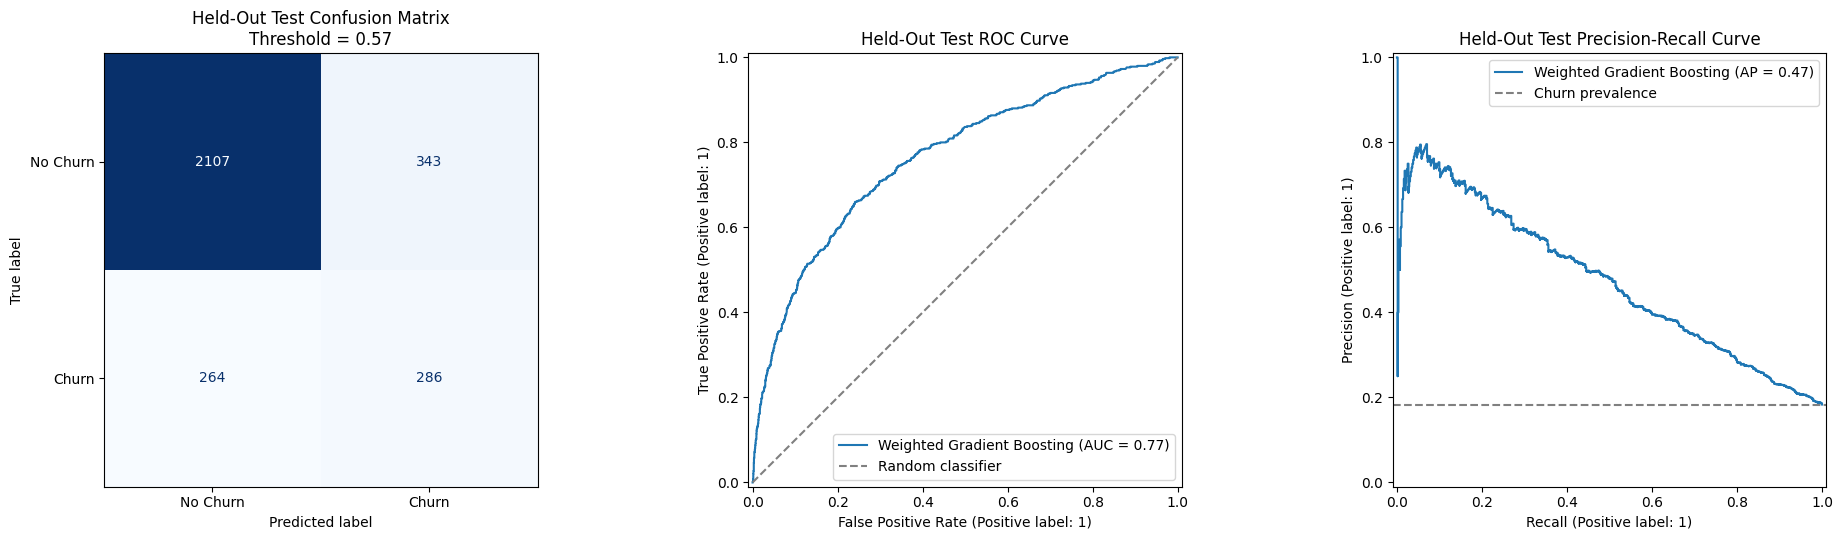


Final model evaluated: Weighted Gradient Boosting
Fixed threshold used: 0.57
Held-out customers evaluated: 3000
Model or threshold changed after evaluation: False

Final held-out test evaluation completed successfully.
The test results were not used for model or threshold selection.


In [47]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    classification_report
)


# Generate probabilities for the held-out test customers

test_churn_probabilities = (
    selected_final_model.predict_proba(X_test)[:, 1]
)


# Apply the classification threshold fixed in Step 6.13

test_churn_predictions = (
    test_churn_probabilities
    >= selected_classification_threshold
).astype(int)


# Calculate the held-out confusion counts

test_true_negatives, test_false_positives, \
test_false_negatives, test_true_positives = (
    confusion_matrix(
        y_test,
        test_churn_predictions,
        labels=[0, 1]
    ).ravel()
)


# Calculate the final evaluation metrics

test_evaluation_metrics = {
    "Model": selected_model_name,

    "Classification Threshold":
        selected_classification_threshold,

    "Accuracy": accuracy_score(
        y_test,
        test_churn_predictions
    ),

    "Churn Precision": precision_score(
        y_test,
        test_churn_predictions,
        pos_label=1,
        zero_division=0
    ),

    "Churn Recall": recall_score(
        y_test,
        test_churn_predictions,
        pos_label=1,
        zero_division=0
    ),

    "Churn F1-Score": f1_score(
        y_test,
        test_churn_predictions,
        pos_label=1,
        zero_division=0
    ),

    "Balanced Accuracy": balanced_accuracy_score(
        y_test,
        test_churn_predictions
    ),

    "ROC-AUC": roc_auc_score(
        y_test,
        test_churn_probabilities
    ),

    "Precision-Recall AUC": average_precision_score(
        y_test,
        test_churn_probabilities
    ),

    "Actual Churn Rate": y_test.mean(),

    "Predicted Churn Rate":
        test_churn_predictions.mean()
}


final_test_performance = pd.DataFrame(
    [test_evaluation_metrics]
)


# Store the test confusion counts

final_test_confusion_counts = pd.DataFrame({
    "Model": [selected_model_name],

    "Classification Threshold": [
        selected_classification_threshold
    ],

    "True Negatives": [test_true_negatives],
    "False Positives": [test_false_positives],
    "False Negatives": [test_false_negatives],
    "True Positives": [test_true_positives]
})


# Compare development performance with held-out performance

development_test_comparison = pd.DataFrame({
    "Metric": [
        "Churn Precision",
        "Churn Recall",
        "Churn F1-Score",
        "Balanced Accuracy",
        "ROC-AUC",
        "Precision-Recall AUC"
    ],

    "Development Out-of-Fold": [
        selected_model_record[
            "Selected Churn Precision"
        ],
        selected_model_record[
            "Selected Churn Recall"
        ],
        selected_model_record[
            "Selected Churn F1-Score"
        ],
        selected_model_record[
            "Selected Balanced Accuracy"
        ],
        selected_model_record[
            "Out-of-Fold ROC-AUC"
        ],
        selected_model_record[
            "Out-of-Fold PR-AUC"
        ]
    ],

    "Held-Out Test": [
        test_evaluation_metrics[
            "Churn Precision"
        ],
        test_evaluation_metrics[
            "Churn Recall"
        ],
        test_evaluation_metrics[
            "Churn F1-Score"
        ],
        test_evaluation_metrics[
            "Balanced Accuracy"
        ],
        test_evaluation_metrics[
            "ROC-AUC"
        ],
        test_evaluation_metrics[
            "Precision-Recall AUC"
        ]
    ]
})

development_test_comparison[
    "Test Minus Development"
] = (
    development_test_comparison["Held-Out Test"]
    - development_test_comparison[
        "Development Out-of-Fold"
    ]
)


# Prepare the detailed classification report

final_classification_report = pd.DataFrame(
    classification_report(
        y_test,
        test_churn_predictions,
        labels=[0, 1],
        target_names=[
            "No Churn",
            "Churn"
        ],
        output_dict=True,
        zero_division=0
    )
).transpose()


# Validate the final evaluation results

assert len(test_churn_probabilities) == len(y_test), (
    "The number of test probabilities is incorrect."
)

assert len(test_churn_predictions) == len(y_test), (
    "The number of test predictions is incorrect."
)

assert np.isfinite(
    test_churn_probabilities
).all(), (
    "The test probabilities contain invalid values."
)

assert (
    (test_churn_probabilities >= 0)
    & (test_churn_probabilities <= 1)
).all(), (
    "One or more probabilities fall outside 0 and 1."
)

assert (
    test_true_negatives
    + test_false_positives
    + test_false_negatives
    + test_true_positives
) == len(y_test), (
    "The confusion counts do not equal the test size."
)

assert all(
    0 <= metric_value <= 1
    for metric_name, metric_value
    in test_evaluation_metrics.items()
    if metric_name not in [
        "Model",
        "Classification Threshold"
    ]
), "One or more evaluation metrics are invalid."

assert selected_model_name == (
    selected_model_record["Model"]
), "The selected model changed unexpectedly."

assert np.isclose(
    selected_classification_threshold,
    selected_model_record["Selected Threshold"]
), "The selected threshold changed unexpectedly."


# Display the final numerical results

print("Final held-out test performance:")

display(
    final_test_performance.round(4)
)

print("\nHeld-out test confusion counts:")

display(
    final_test_confusion_counts
)

print(
    "\nDevelopment versus held-out test performance:"
)

display(
    development_test_comparison.round(4)
)

print("\nDetailed classification report:")

display(
    final_classification_report.round(4)
)


# Visualise the final held-out results

figure, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(20, 5.5)
)


ConfusionMatrixDisplay(
    confusion_matrix=np.array([
        [
            test_true_negatives,
            test_false_positives
        ],
        [
            test_false_negatives,
            test_true_positives
        ]
    ]),
    display_labels=[
        "No Churn",
        "Churn"
    ]
).plot(
    ax=axes[0],
    cmap="Blues",
    colorbar=False
)

axes[0].set_title(
    "Held-Out Test Confusion Matrix\n"
    f"Threshold = "
    f"{selected_classification_threshold:.2f}"
)


RocCurveDisplay.from_predictions(
    y_test,
    test_churn_probabilities,
    name=selected_model_name,
    ax=axes[1]
)

axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey",
    label="Random classifier"
)

axes[1].set_title(
    "Held-Out Test ROC Curve"
)

axes[1].legend(loc="lower right")


PrecisionRecallDisplay.from_predictions(
    y_test,
    test_churn_probabilities,
    name=selected_model_name,
    ax=axes[2]
)

axes[2].axhline(
    y=y_test.mean(),
    linestyle="--",
    color="grey",
    label="Churn prevalence"
)

axes[2].set_title(
    "Held-Out Test Precision-Recall Curve"
)

axes[2].legend(loc="upper right")


plt.tight_layout()
plt.show()


# Confirm the completed evaluation stage

print(
    "\nFinal model evaluated:",
    selected_model_name
)

print(
    "Fixed threshold used:",
    selected_classification_threshold
)

print(
    "Held-out customers evaluated:",
    len(y_test)
)

print(
    "Model or threshold changed after evaluation:",
    False
)

print(
    "\nFinal held-out test evaluation "
    "completed successfully."
)

print(
    "The test results were not used for "
    "model or threshold selection."
)

#### 6.14.1 Interpretation of the Final Held-Out Evaluation

The final Weighted Gradient Boosting model produced performance on the held-out test set that was very close to its out-of-fold development performance. Its test churn F1-score was 0.4852, compared with 0.4798 during development, while all reported metric differences were smaller than 0.01. This indicates stable generalisation, with no clear sign of material overfitting.

The confusion matrix shows that the model correctly identified 286 of the 550 customers who churned, giving a churn recall of 52.00%. It missed 264 churners and incorrectly classified 343 non-churners as likely to churn. Among the 629 customers flagged as potential churners, 286 actually churned, producing a churn precision of 45.47%.

The ROC-AUC of 0.7660 indicates that the model has useful ability to rank churners above non-churners. More importantly for this imbalanced dataset, the precision-recall AUC was 0.4740, substantially higher than the churn prevalence baseline of approximately 0.1833.

Although the model's overall accuracy was 79.77%, accuracy alone is not the most appropriate measure because non-churners represent 81.67% of the dataset. The balanced accuracy of 69.00%, together with the ROC-AUC, precision-recall AUC and churn-class results, provides a more informative assessment.

Overall, the model demonstrates moderate but useful predictive performance. It can support the prioritisation of customers for retention intervention, but its predictions should not be treated as certain outcomes or used as the sole basis for customer decisions.

### 6.15 Explanation of the Final Model Using Permutation Importance

Permutation importance is used to identify the variables that contribute most strongly to the predictive performance of the final Weighted Gradient Boosting model.

Each predictor is shuffled repeatedly in the held-out test data while the remaining predictors are left unchanged. The resulting decrease in precision-recall AUC indicates how much the model depends on that variable when identifying customers at risk of churn.

This model-agnostic method is appropriate for the selected tree-based model and measures importance using the original predictor names. The analysis is performed only after the model and classification threshold have been fixed. It does not retrain the model or influence model selection.

Top 20 predictors by permutation importance:


,Importance Rank,Feature,Mean PR-AUC Decrease,Importance Standard Deviation
0,1,Months_Inactive_12M,0.10277,0.01140
1,2,Active_Member,0.07940,0.01314
2,3,Transaction_Change_Pct_3M,0.04356,0.00503
3,4,Number_of_Products,0.01552,0.00459
4,5,Active_Account_at_Another_Bank,0.00632,0.00219
5,6,Fee_to_Income_Pct,0.00533,0.00372
6,7,Satisfaction_Score,0.00255,0.00164
7,8,Unresolved_Complaints_6M,0.00217,0.00127
8,9,Balance_Change_Pct_3M,0.00165,0.00121
9,10,Loan_Status,0.00157,0.00081


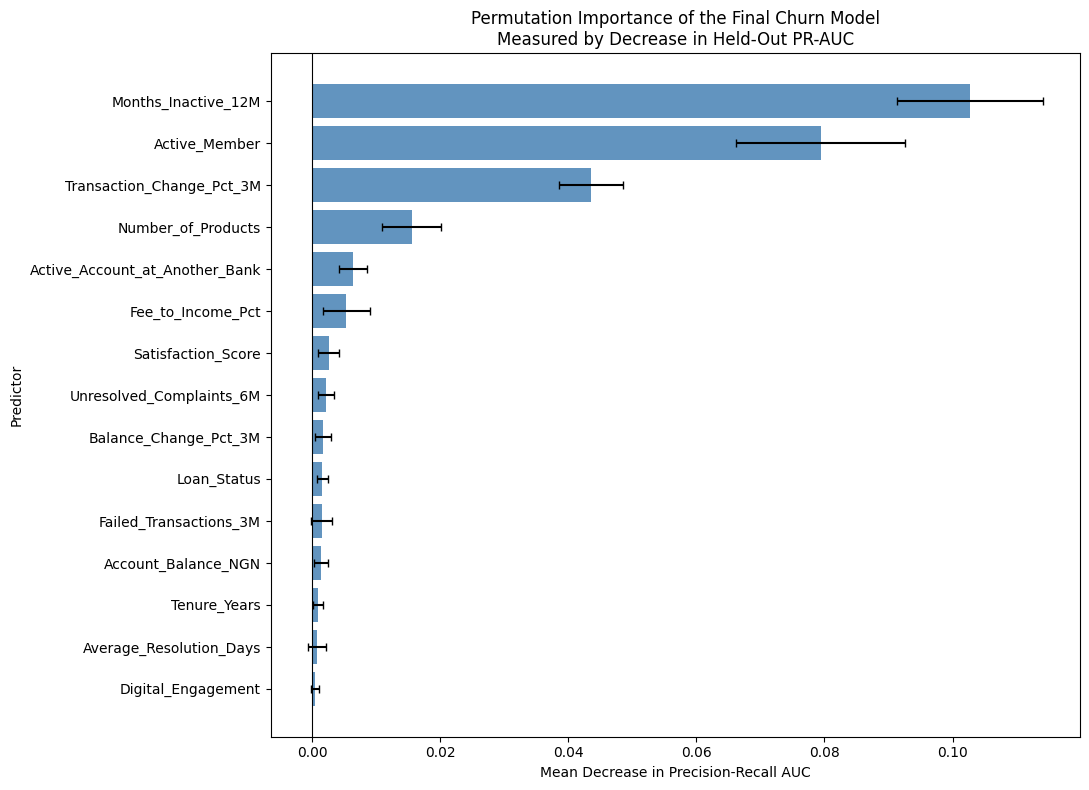


Predictors evaluated: 45
Predictors with positive mean importance: 18
Highest-ranked predictor: Months_Inactive_12M
Model predictions unchanged: True

Permutation-importance analysis completed successfully.
The model was not retrained or modified.
The results will not be used to change the selected model or threshold.


In [48]:
from sklearn.inspection import permutation_importance


# Preserve the existing predictions so that we can confirm
# that the explanation process does not change the model

probabilities_before_explanation = (
    selected_final_model.predict_proba(X_test)[:, 1].copy()
)


# Measure how much the held-out PR-AUC changes when
# each predictor is shuffled

permutation_results = permutation_importance(
    estimator=selected_final_model,
    X=X_test,
    y=y_test,
    scoring="average_precision",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)


# Organise the results using the original predictor names

permutation_importance_table = pd.DataFrame({
    "Feature": X_test.columns,

    "Mean PR-AUC Decrease":
        permutation_results.importances_mean,

    "Importance Standard Deviation":
        permutation_results.importances_std
})


permutation_importance_table = (
    permutation_importance_table
    .sort_values(
        by="Mean PR-AUC Decrease",
        ascending=False
    )
    .reset_index(drop=True)
)


permutation_importance_table.insert(
    0,
    "Importance Rank",
    range(
        1,
        len(permutation_importance_table) + 1
    )
)


# Keep the 15 highest-ranked predictors for the chart

top_permutation_features = (
    permutation_importance_table
    .head(15)
    .copy()
)


# Confirm that the explanation did not alter the model

probabilities_after_explanation = (
    selected_final_model.predict_proba(X_test)[:, 1]
)


assert len(permutation_importance_table) == X_test.shape[1], (
    "Not all predictors were included."
)

assert permutation_results.importances.shape == (
    X_test.shape[1],
    10
), "The permutation-importance dimensions are incorrect."

assert np.isfinite(
    permutation_results.importances
).all(), (
    "The permutation results contain invalid values."
)

assert np.allclose(
    probabilities_before_explanation,
    probabilities_after_explanation
), "The fitted model changed during explanation."

assert selected_model_name == "Weighted Gradient Boosting", (
    "The final model changed unexpectedly."
)


# Display the 20 highest-ranked predictors

print("Top 20 predictors by permutation importance:")

display(
    permutation_importance_table
    .head(20)
    .round(5)
)


# Plot the 15 highest-ranked predictors

importance_plot_data = (
    top_permutation_features
    .sort_values(
        by="Mean PR-AUC Decrease",
        ascending=True
    )
)


plt.figure(figsize=(11, 8))

plt.barh(
    importance_plot_data["Feature"],
    importance_plot_data["Mean PR-AUC Decrease"],
    xerr=importance_plot_data[
        "Importance Standard Deviation"
    ],
    color="steelblue",
    alpha=0.85,
    capsize=3
)

plt.axvline(
    x=0,
    color="black",
    linewidth=0.8
)

plt.title(
    "Permutation Importance of the Final Churn Model\n"
    "Measured by Decrease in Held-Out PR-AUC"
)

plt.xlabel(
    "Mean Decrease in Precision-Recall AUC"
)

plt.ylabel("Predictor")

plt.tight_layout()
plt.show()


# Summarise the completed explanation stage

positive_importance_count = int(
    (
        permutation_importance_table[
            "Mean PR-AUC Decrease"
        ] > 0
    ).sum()
)


print(
    "\nPredictors evaluated:",
    len(permutation_importance_table)
)

print(
    "Predictors with positive mean importance:",
    positive_importance_count
)

print(
    "Highest-ranked predictor:",
    permutation_importance_table.loc[
        0,
        "Feature"
    ]
)

print(
    "Model predictions unchanged:",
    np.allclose(
        probabilities_before_explanation,
        probabilities_after_explanation
    )
)

print(
    "\nPermutation-importance analysis "
    "completed successfully."
)

print(
    "The model was not retrained or modified."
)

print(
    "The results will not be used to change "
    "the selected model or threshold."
)

#### 6.15.1 Interpretation of the Permutation-Importance Results

The permutation-importance analysis shows that the final model depends most strongly on recent customer inactivity and engagement-related variables when distinguishing customers at risk of churn.

`Months_Inactive_12M` was the highest-ranked predictor. Shuffling this variable reduced the held-out precision-recall AUC by approximately 0.1028 on average. `Active_Member` ranked second with a mean decrease of approximately 0.0794, while `Transaction_Change_Pct_3M` ranked third with a decrease of approximately 0.0436. These three variables had substantially greater importance than the remaining predictors, indicating that recent inactivity, active-member status and changes in transaction behaviour contain the strongest predictive information used by the model.

`Number_of_Products` provided a smaller but still noticeable contribution, with a mean PR-AUC decrease of approximately 0.0155. Other variables—including `Active_Account_at_Another_Bank`, `Fee_to_Income_Pct`, `Satisfaction_Score`, `Unresolved_Complaints_6M`, `Balance_Change_Pct_3M` and `Loan_Status`—made smaller positive contributions to the model's predictive performance.

The importance values became very small for the lower-ranked predictors. For variables such as `Failed_Transactions_3M`, `Average_Resolution_Days`, `Digital_Engagement` and `Income_Regularity`, the uncertainty indicated by the error bars was similar to or greater than their mean importance. Their individual contributions should therefore be interpreted cautiously. Predictors with zero or negative mean importance did not provide a measurable improvement under this permutation procedure, although this does not necessarily mean that they contain no information. Their contribution may overlap with information already represented by other correlated predictors.

Permutation importance measures predictive contribution rather than direction or causation. For example, the results show that the model relies strongly on `Months_Inactive_12M`, but they do not independently establish that inactivity causes churn or indicate the precise effect of each additional inactive month. Directional relationships should be examined using the earlier exploratory analysis or an appropriate effect-analysis method.

Overall, the results suggest that customer inactivity, engagement status and recent transaction changes are the most useful indicators for prioritising customers for retention attention. However, because the dataset is synthetic, these findings primarily reflect the patterns represented in the generated data and should be validated with genuine operational banking data before being used for real customer decisions.

### 6.16 Analyse the Final Model's Prediction Errors

Error analysis is performed to understand where the final model succeeds and where it makes incorrect predictions on the held-out test set.

The customers are divided into four prediction outcomes: true negatives, false positives, false negatives and true positives. Their predicted probabilities and important predictor profiles are compared, with particular attention given to false positives and false negatives.

False positives represent non-churners who may receive unnecessary retention attention, while false negatives represent actual churners whom the model failed to identify. Understanding these errors helps clarify the model's practical limitations and the trade-off created by the fixed classification threshold of 0.57.

This analysis is diagnostic only. It does not retrain the model, alter its hyperparameters or change the selected classification threshold.

Held-out prediction-group summary:


,Count,Percentage of Test Set,Mean_Churn_Probability,Median_Churn_Probability,Mean_Distance_From_Threshold
Prediction Outcome,,,,,
True Negative,2107,70.2333,0.3481,0.3380,0.2219
False Positive,343,11.4333,0.7144,0.7112,0.1444
False Negative,264,8.8000,0.4040,0.4151,0.1660
True Positive,286,9.5333,0.7749,0.7906,0.2049



Mean values of important numerical predictors by prediction outcome:


Prediction Outcome,True Negative,False Positive,False Negative,True Positive
Months_Inactive_12M,1.2316,3.1778,1.6023,3.7483
Transaction_Change_Pct_3M,0.0817,-0.1363,0.0373,-0.1693
Number_of_Products,2.0024,1.7726,1.7727,1.5909
Fee_to_Income_Pct,1.2970,1.7802,1.4020,1.8019
Satisfaction_Score,3.9487,3.6589,3.8674,3.7727
Unresolved_Complaints_6M,0.0209,0.0612,0.0568,0.0559
Balance_Change_Pct_3M,0.0269,0.0271,0.0131,-0.0046



Most common values of important categorical or binary predictors:


,Feature,Prediction Outcome,Most Common Value,Within-Group Share (%)
0,Active_Member,True Negative,Yes,99.38
1,Active_Member,False Positive,No,61.52
2,Active_Member,False Negative,Yes,99.62
3,Active_Member,True Positive,No,73.78
4,Active_Account_at_Another_Bank,True Negative,No,61.41
5,Active_Account_at_Another_Bank,False Positive,No,54.23
6,Active_Account_at_Another_Bank,False Negative,No,57.95
7,Active_Account_at_Another_Bank,True Positive,Yes,50.00
8,Loan_Status,True Negative,No Loan,55.72
9,Loan_Status,False Positive,No Loan,60.93



Five most confident false-positive predictions:


,Predicted Churn Probability,Months_Inactive_12M,Active_Member,Transaction_Change_Pct_3M,Number_of_Products,Active_Account_at_Another_Bank,Fee_to_Income_Pct
12405,0.9682,4,No,0.450,1,Yes,12.50
12890,0.9474,7,No,0.062,2,Yes,12.92
485,0.9455,5,No,-0.500,1,Yes,0.58
3304,0.9396,5,No,-0.500,1,Yes,0.54
5851,0.9270,5,No,-0.522,1,No,1.14



Five most confident false-negative predictions:


,Predicted Churn Probability,Months_Inactive_12M,Active_Member,Transaction_Change_Pct_3M,Number_of_Products,Active_Account_at_Another_Bank,Fee_to_Income_Pct
2943,0.1788,0,Yes,0.000,4,Yes,0.69
1484,0.1888,1,Yes,0.429,3,Yes,1.45
12064,0.1908,0,Yes,0.172,3,Yes,0.81
12223,0.1927,1,Yes,0.500,4,No,2.93
4178,0.1995,0,Yes,0.345,3,No,1.71


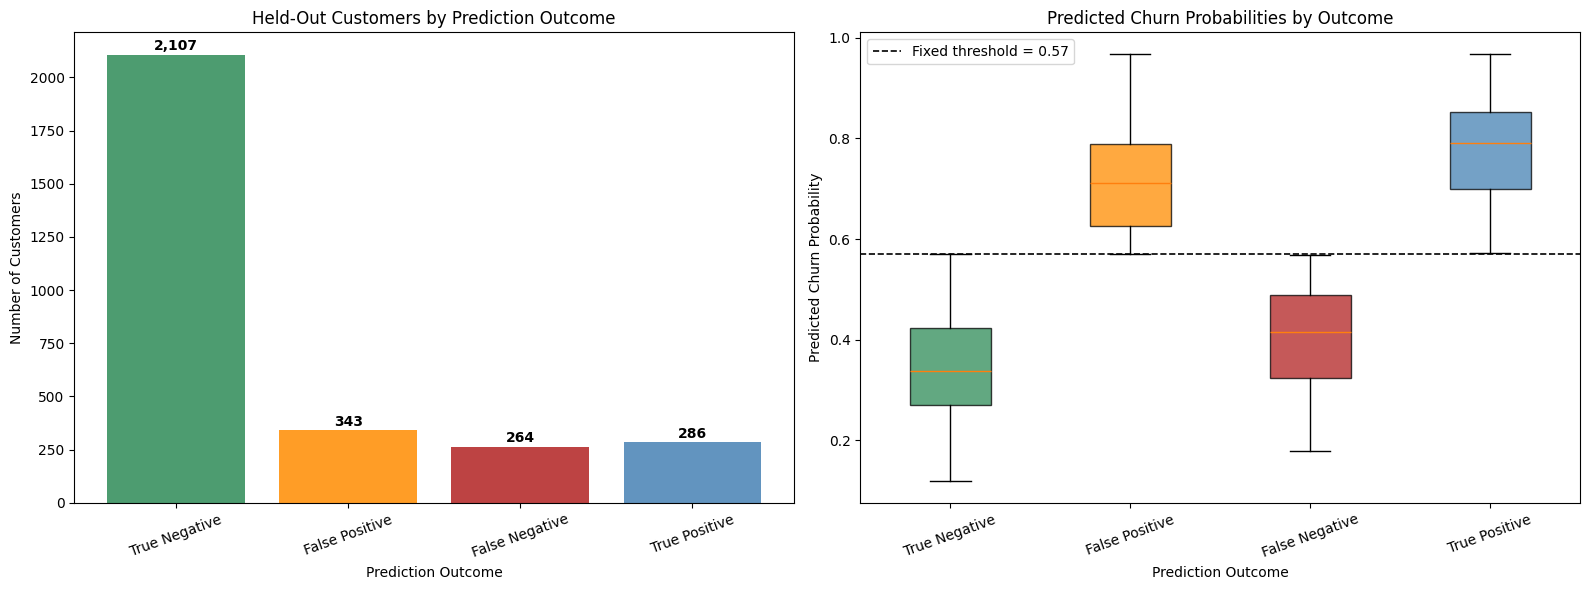

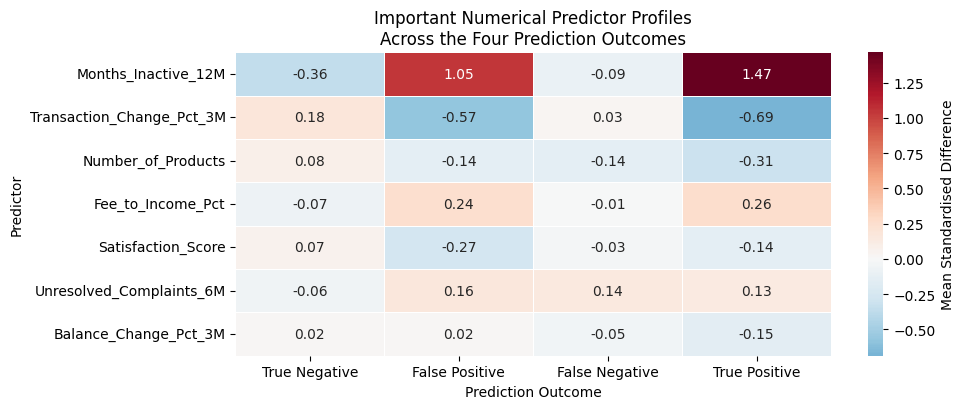


Prediction outcomes analysed: 4
Held-out customers analysed: 3000
False positives identified: 343
False negatives identified: 264
Model predictions unchanged: True

Final-model error analysis completed successfully.
The model and classification threshold were not changed.


In [49]:
import seaborn as sns


# Keep the four prediction outcomes in a consistent order

prediction_outcome_order = [
    "True Negative",
    "False Positive",
    "False Negative",
    "True Positive"
]


# Combine the held-out predictors with their actual outcomes,
# predicted outcomes and churn probabilities

error_analysis_data = X_test.copy()

error_analysis_data.insert(
    0,
    "Actual Churn",
    np.asarray(y_test, dtype=int)
)

error_analysis_data.insert(
    1,
    "Predicted Churn",
    test_churn_predictions
)

error_analysis_data.insert(
    2,
    "Predicted Churn Probability",
    test_churn_probabilities
)


# Assign each held-out customer to one prediction outcome

prediction_outcomes = np.select(
    condlist=[
        (
            (error_analysis_data["Actual Churn"] == 0)
            & (error_analysis_data["Predicted Churn"] == 0)
        ),
        (
            (error_analysis_data["Actual Churn"] == 0)
            & (error_analysis_data["Predicted Churn"] == 1)
        ),
        (
            (error_analysis_data["Actual Churn"] == 1)
            & (error_analysis_data["Predicted Churn"] == 0)
        ),
        (
            (error_analysis_data["Actual Churn"] == 1)
            & (error_analysis_data["Predicted Churn"] == 1)
        )
    ],
    choicelist=prediction_outcome_order,
    default="Unclassified"
)


assert "Unclassified" not in prediction_outcomes, (
    "One or more test customers could not be classified."
)


error_analysis_data.insert(
    3,
    "Prediction Outcome",
    pd.Categorical(
        prediction_outcomes,
        categories=prediction_outcome_order,
        ordered=True
    )
)


# Measure how far each probability lies from the fixed threshold

error_analysis_data[
    "Distance From Threshold"
] = np.abs(
    error_analysis_data[
        "Predicted Churn Probability"
    ]
    - selected_classification_threshold
)


# Summarise the four prediction outcomes

error_group_summary = (
    error_analysis_data
    .groupby(
        "Prediction Outcome",
        observed=True
    )
    .agg(
        Count=("Actual Churn", "size"),

        Mean_Churn_Probability=(
            "Predicted Churn Probability",
            "mean"
        ),

        Median_Churn_Probability=(
            "Predicted Churn Probability",
            "median"
        ),

        Mean_Distance_From_Threshold=(
            "Distance From Threshold",
            "mean"
        )
    )
    .reindex(prediction_outcome_order)
)


error_group_summary[
    "Percentage of Test Set"
] = (
    error_group_summary["Count"]
    / len(error_analysis_data)
    * 100
)


error_group_summary = error_group_summary[
    [
        "Count",
        "Percentage of Test Set",
        "Mean_Churn_Probability",
        "Median_Churn_Probability",
        "Mean_Distance_From_Threshold"
    ]
]


# Use the most important predictors from Step 6.15
# to profile the four prediction outcomes

top_error_predictors = (
    permutation_importance_table
    .head(10)["Feature"]
    .tolist()
)


# Separate continuous or multi-level numerical predictors
# from binary and categorical predictors

key_numerical_error_predictors = [
    feature
    for feature in top_error_predictors
    if (
        pd.api.types.is_numeric_dtype(
            error_analysis_data[feature]
        )
        and error_analysis_data[feature].nunique(
            dropna=True
        ) > 2
    )
]


key_categorical_error_predictors = [
    feature
    for feature in top_error_predictors
    if feature not in key_numerical_error_predictors
]


# Compare the mean numerical profiles of the four groups

if key_numerical_error_predictors:

    numerical_error_profiles = (
        error_analysis_data
        .groupby(
            "Prediction Outcome",
            observed=True
        )[key_numerical_error_predictors]
        .mean()
        .reindex(prediction_outcome_order)
        .transpose()
    )

else:

    numerical_error_profiles = pd.DataFrame()


# Identify the most common value of each important
# categorical or binary predictor within each group

categorical_profile_records = []

for feature in key_categorical_error_predictors:

    for prediction_outcome in prediction_outcome_order:

        group_values = (
            error_analysis_data.loc[
                error_analysis_data[
                    "Prediction Outcome"
                ] == prediction_outcome,
                feature
            ]
            .astype("object")
            .fillna("Missing")
        )

        value_counts = group_values.value_counts(
            dropna=False
        )

        if len(value_counts) > 0:

            most_common_value = value_counts.index[0]

            most_common_share = (
                value_counts.iloc[0]
                / len(group_values)
                * 100
            )

            categorical_profile_records.append({
                "Feature": feature,
                "Prediction Outcome":
                    prediction_outcome,
                "Most Common Value":
                    most_common_value,
                "Within-Group Share (%)":
                    most_common_share
            })


categorical_error_profiles = pd.DataFrame(
    categorical_profile_records
)


# Find the strongest incorrect predictions

error_example_predictors = (
    top_error_predictors[:6]
)

error_example_columns = [
    "Predicted Churn Probability"
] + error_example_predictors


most_confident_false_positives = (
    error_analysis_data.loc[
        error_analysis_data[
            "Prediction Outcome"
        ] == "False Positive",
        error_example_columns
    ]
    .nlargest(
        5,
        "Predicted Churn Probability"
    )
)


most_confident_false_negatives = (
    error_analysis_data.loc[
        error_analysis_data[
            "Prediction Outcome"
        ] == "False Negative",
        error_example_columns
    ]
    .nsmallest(
        5,
        "Predicted Churn Probability"
    )
)


# Validate the error-analysis results

observed_error_counts = (
    error_group_summary["Count"]
    .astype(int)
    .to_dict()
)


assert len(error_analysis_data) == len(y_test), (
    "The error-analysis data has an incorrect size."
)

assert error_group_summary["Count"].sum() == len(
    y_test
), "The prediction-group counts do not equal the test size."

assert observed_error_counts["True Negative"] == (
    test_true_negatives
), "The true-negative count is inconsistent."

assert observed_error_counts["False Positive"] == (
    test_false_positives
), "The false-positive count is inconsistent."

assert observed_error_counts["False Negative"] == (
    test_false_negatives
), "The false-negative count is inconsistent."

assert observed_error_counts["True Positive"] == (
    test_true_positives
), "The true-positive count is inconsistent."

assert error_group_summary["Count"].gt(0).all(), (
    "One or more prediction groups are empty."
)

assert set(top_error_predictors).issubset(
    X_test.columns
), "One or more important predictors are unavailable."


# Confirm once more that the model has not changed

probabilities_after_error_analysis = (
    selected_final_model.predict_proba(
        X_test
    )[:, 1]
)


assert np.allclose(
    test_churn_probabilities,
    probabilities_after_error_analysis
), "The model predictions changed during error analysis."


# Display the numerical findings

print("Held-out prediction-group summary:")

display(
    error_group_summary.round(4)
)


if not numerical_error_profiles.empty:

    print(
        "\nMean values of important numerical "
        "predictors by prediction outcome:"
    )

    display(
        numerical_error_profiles.round(4)
    )


if not categorical_error_profiles.empty:

    print(
        "\nMost common values of important categorical "
        "or binary predictors:"
    )

    display(
        categorical_error_profiles.round(2)
    )


print(
    "\nFive most confident false-positive predictions:"
)

display(
    most_confident_false_positives.round(4)
)


print(
    "\nFive most confident false-negative predictions:"
)

display(
    most_confident_false_negatives.round(4)
)


# Visualise the size of each group and the distribution
# of its predicted churn probabilities

figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6)
)


group_colours = [
    "seagreen",
    "darkorange",
    "firebrick",
    "steelblue"
]


axes[0].bar(
    prediction_outcome_order,
    error_group_summary["Count"],
    color=group_colours,
    alpha=0.85
)

axes[0].set_title(
    "Held-Out Customers by Prediction Outcome"
)

axes[0].set_xlabel("Prediction Outcome")
axes[0].set_ylabel("Number of Customers")
axes[0].tick_params(axis="x", rotation=20)


for position, count in enumerate(
    error_group_summary["Count"]
):

    axes[0].text(
        position,
        count + 20,
        f"{int(count):,}",
        ha="center",
        fontweight="bold"
    )


probability_groups = [
    error_analysis_data.loc[
        error_analysis_data[
            "Prediction Outcome"
        ] == prediction_outcome,
        "Predicted Churn Probability"
    ]
    for prediction_outcome in prediction_outcome_order
]


boxplot = axes[1].boxplot(
    probability_groups,
    labels=prediction_outcome_order,
    patch_artist=True,
    showfliers=False
)


for patch, colour in zip(
    boxplot["boxes"],
    group_colours
):

    patch.set_facecolor(colour)
    patch.set_alpha(0.75)


axes[1].axhline(
    y=selected_classification_threshold,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=(
        "Fixed threshold = "
        f"{selected_classification_threshold:.2f}"
    )
)

axes[1].set_title(
    "Predicted Churn Probabilities by Outcome"
)

axes[1].set_xlabel("Prediction Outcome")
axes[1].set_ylabel("Predicted Churn Probability")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(loc="upper left")


plt.tight_layout()
plt.show()


# Compare standardised numerical profiles where available

if key_numerical_error_predictors:

    numerical_means = error_analysis_data[
        key_numerical_error_predictors
    ].mean()

    numerical_standard_deviations = (
        error_analysis_data[
            key_numerical_error_predictors
        ]
        .std(ddof=0)
        .replace(0, np.nan)
    )

    standardised_numerical_data = (
        error_analysis_data[
            key_numerical_error_predictors
        ]
        - numerical_means
    ) / numerical_standard_deviations

    standardised_numerical_data[
        "Prediction Outcome"
    ] = error_analysis_data[
        "Prediction Outcome"
    ]

    standardised_group_profiles = (
        standardised_numerical_data
        .groupby(
            "Prediction Outcome",
            observed=True
        )
        .mean()
        .reindex(prediction_outcome_order)
        .transpose()
        .dropna(how="all")
    )


    plt.figure(
        figsize=(
            10,
            max(
                4,
                0.6
                * len(standardised_group_profiles)
            )
        )
    )

    sns.heatmap(
        standardised_group_profiles,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        linewidths=0.5,
        cbar_kws={
            "label":
                "Mean Standardised Difference"
        }
    )

    plt.title(
        "Important Numerical Predictor Profiles\n"
        "Across the Four Prediction Outcomes"
    )

    plt.xlabel("Prediction Outcome")
    plt.ylabel("Predictor")

    plt.tight_layout()
    plt.show()


# Confirm completion without changing the final model

print(
    "\nPrediction outcomes analysed:",
    len(error_group_summary)
)

print(
    "Held-out customers analysed:",
    len(error_analysis_data)
)

print(
    "False positives identified:",
    observed_error_counts["False Positive"]
)

print(
    "False negatives identified:",
    observed_error_counts["False Negative"]
)

print(
    "Model predictions unchanged:",
    np.allclose(
        test_churn_probabilities,
        probabilities_after_error_analysis
    )
)

print(
    "\nFinal-model error analysis "
    "completed successfully."
)

print(
    "The model and classification threshold "
    "were not changed."
)

#### 6.16.1 Interpretation of the Final Model's Prediction Errors

The error analysis confirms the four outcomes previously reported for the 3,000 held-out customers. The model correctly classified 2,107 non-churners and 286 churners, while producing 343 false positives and 264 false negatives.

The probability distributions show that incorrect predictions were generally closer to the fixed threshold of 0.57 than correct predictions. False positives had a mean predicted churn probability of 0.7144 and a mean distance of 0.1444 from the threshold, while false negatives had a mean probability of 0.4040 and a mean distance of 0.1660. In comparison, true negatives and true positives were farther from the threshold on average. This indicates that many errors occurred among customers whose behavioural profiles were less clearly separated.

Recent inactivity and active-member status produced the clearest differences between the prediction groups. True positives averaged approximately 3.75 inactive months and false positives averaged 3.18 months, compared with 1.23 months for true negatives and 1.60 months for false negatives. Similarly, 73.78% of true positives and 61.52% of false positives were not active members, whereas more than 99% of both true negatives and false negatives were active members.

Recent transaction behaviour followed a similar pattern. True positives and false positives had average transaction changes of approximately -0.169 and -0.136 respectively, while true negatives and false negatives had averages of approximately 0.082 and 0.037. Customers classified as likely churners also generally held fewer products and had somewhat higher fee-to-income percentages than customers classified as non-churners.

The most confident false positives resembled the model's typical high-risk profile: they were generally inactive for several months, were not active members and held relatively few products. However, these customers did not actually churn. Conversely, the most confident false negatives were active members with only zero or one inactive month, generally positive transaction changes and three or four products. Although these characteristics resembled the model's lower-risk profile, the customers nevertheless churned.

These cases illustrate an important limitation. The model is more likely to miss churners who continue to appear active and engaged, while it may incorrectly flag non-churners who display inactivity or declining engagement. Such errors may arise from overlapping customer profiles, outcome variability or influential factors not fully represented by the available predictors.

The categorical profiles for `Active_Account_at_Another_Bank` and `Loan_Status` showed less distinct separation across the four outcomes than `Active_Member`. In particular, the most common loan status was `No Loan` in every group, so this category alone does not clearly distinguish correct from incorrect predictions.

Overall, the error analysis supports the earlier conclusion that the model provides useful but imperfect customer prioritisation. False-positive alerts should therefore be treated as opportunities for low-cost engagement rather than proof that a customer will churn. False negatives also show that apparently active customers should not be assumed to have no churn risk. These patterns describe predictive associations in the synthetic dataset and should not be interpreted as causal relationships or applied operationally without validation using genuine banking data.

### 6.17 Classify Held-Out Customers by Predicted Churn Risk

The final model's predicted probabilities are converted into four ordered risk tiers to demonstrate how a bank could prioritise customers for retention attention.

Customers with probabilities below 0.30 are classified as low risk, while those between 0.30 and the fixed classification threshold of 0.57 are classified as moderate risk. Customers at or above the fixed threshold are classified as high risk, with probabilities of 0.75 or higher placed in a very-high-risk group for the most urgent review.

The 0.30 and 0.75 boundaries are transparent operational bands introduced for prioritisation. They were not selected by optimising the held-out outcomes and do not replace the model's fixed classification threshold of 0.57.

The observed churn rate within each tier is examined to determine whether higher predicted-risk groups contain progressively greater concentrations of actual churners. A ranked retention-priority queue is also produced without displaying the actual churn outcome.

This is a retrospective demonstration using the held-out synthetic data. The tiers should not be treated as calibrated probabilities or deployed in a real bank without validation, cost analysis and appropriate customer-protection review.

In [50]:
# Define transparent risk bands around the fixed
# classification threshold selected during development

risk_tier_labels = [
    "Low",
    "Moderate",
    "High",
    "Very High"
]

moderate_risk_boundary = 0.30
very_high_risk_boundary = 0.75


assert (
    0
    < moderate_risk_boundary
    < selected_classification_threshold
    < very_high_risk_boundary
    < 1
), "The risk-tier boundaries are not correctly ordered."


risk_bin_boundaries = [
    -np.inf,
    moderate_risk_boundary,
    selected_classification_threshold,
    very_high_risk_boundary,
    np.inf
]


# Recover the customer identifiers belonging to the
# held-out observations

assert "Customer_ID" in df.columns, (
    "Customer_ID is unavailable in the original dataset."
)

held_out_customer_ids = (
    df.loc[X_test.index, "Customer_ID"]
    .reindex(X_test.index)
)


assert held_out_customer_ids.notna().all(), (
    "One or more held-out customer identifiers are missing."
)

assert held_out_customer_ids.is_unique, (
    "The held-out customer identifiers are not unique."
)


# Retain a small number of influential predictors so that
# the priority queue can show useful customer profiles

priority_profile_features = (
    top_error_predictors[:6]
)


risk_classification_data = pd.DataFrame(
    {
        "Customer_ID":
            held_out_customer_ids.to_numpy(),

        "Actual Churn":
            np.asarray(y_test, dtype=int),

        "Predicted Churn":
            np.asarray(
                test_churn_predictions,
                dtype=int
            ),

        "Predicted Churn Probability":
            np.asarray(
                test_churn_probabilities,
                dtype=float
            )
    },
    index=X_test.index
)


for feature in priority_profile_features:

    risk_classification_data[feature] = (
        X_test[feature].to_numpy()
    )


# Assign every held-out customer to one ordered risk tier

risk_classification_data["Risk Tier"] = pd.cut(
    risk_classification_data[
        "Predicted Churn Probability"
    ],
    bins=risk_bin_boundaries,
    labels=risk_tier_labels,
    right=False,
    ordered=True
)


# Document the meaning of each probability band

risk_definition_table = pd.DataFrame(
    {
        "Risk Tier": risk_tier_labels,

        "Predicted Probability Range": [
            "Below 0.30",

            (
                "0.30 to below "
                f"{selected_classification_threshold:.2f}"
            ),

            (
                f"{selected_classification_threshold:.2f} "
                "to below 0.75"
            ),

            "0.75 and above"
        ],

        "Illustrative Retention Priority": [
            "Routine monitoring",
            "Low-cost engagement",
            "Proactive retention review",
            "Immediate priority review"
        ]
    }
)


# Summarise the size and observed performance
# of each risk tier

risk_tier_summary = (
    risk_classification_data
    .groupby(
        "Risk Tier",
        observed=False
    )
    .agg(
        Count=("Customer_ID", "size"),

        Actual_Churners=(
            "Actual Churn",
            "sum"
        ),

        Customers_Above_Fixed_Threshold=(
            "Predicted Churn",
            "sum"
        ),

        Mean_Predicted_Probability=(
            "Predicted Churn Probability",
            "mean"
        ),

        Median_Predicted_Probability=(
            "Predicted Churn Probability",
            "median"
        )
    )
    .reindex(risk_tier_labels)
)


risk_tier_summary[
    "Percentage of Test Set (%)"
] = (
    risk_tier_summary["Count"]
    / len(risk_classification_data)
    * 100
)


risk_tier_summary[
    "Observed Churn Rate (%)"
] = (
    risk_tier_summary["Actual_Churners"]
    / risk_tier_summary["Count"]
    * 100
)


total_held_out_churners = int(
    risk_classification_data[
        "Actual Churn"
    ].sum()
)


risk_tier_summary[
    "Share of All Churners (%)"
] = (
    risk_tier_summary["Actual_Churners"]
    / total_held_out_churners
    * 100
)


risk_tier_summary = (
    risk_tier_summary
    .rename(
        columns={
            "Actual_Churners":
                "Actual Churners",

            "Customers_Above_Fixed_Threshold":
                "Customers Above Fixed Threshold",

            "Mean_Predicted_Probability":
                "Mean Predicted Probability",

            "Median_Predicted_Probability":
                "Median Predicted Probability"
        }
    )
    [
        [
            "Count",
            "Percentage of Test Set (%)",
            "Actual Churners",
            "Observed Churn Rate (%)",
            "Share of All Churners (%)",
            "Customers Above Fixed Threshold",
            "Mean Predicted Probability",
            "Median Predicted Probability"
        ]
    ]
)


# Show how much of the held-out population must be reviewed
# when the bank works downward from the highest-risk tier

priority_review_order = [
    "Very High",
    "High",
    "Moderate",
    "Low"
]


retention_coverage_summary = (
    risk_tier_summary
    .loc[
        priority_review_order,
        [
            "Count",
            "Actual Churners"
        ]
    ]
    .copy()
)


retention_coverage_summary[
    "Cumulative Customers Reviewed"
] = (
    retention_coverage_summary[
        "Count"
    ].cumsum()
)


retention_coverage_summary[
    "Cumulative Test-Set Coverage (%)"
] = (
    retention_coverage_summary[
        "Cumulative Customers Reviewed"
    ]
    / len(risk_classification_data)
    * 100
)


retention_coverage_summary[
    "Cumulative Churners Captured"
] = (
    retention_coverage_summary[
        "Actual Churners"
    ].cumsum()
)


retention_coverage_summary[
    "Cumulative Churner Coverage (%)"
] = (
    retention_coverage_summary[
        "Cumulative Churners Captured"
    ]
    / total_held_out_churners
    * 100
)


retention_coverage_summary.insert(
    0,
    "Priority Scope",
    [
        "Very High only",
        "Very High and High",
        "Very High through Moderate",
        "All risk tiers"
    ]
)


# Validate the classifications and their relationship
# to the fixed operating threshold

expected_threshold_predictions = (
    risk_classification_data[
        "Predicted Churn Probability"
    ]
    >= selected_classification_threshold
).astype(int)


assert len(risk_classification_data) == len(
    X_test
), "The risk-classification data has an incorrect size."

assert risk_classification_data[
    "Risk Tier"
].notna().all(), (
    "One or more customers were not assigned a risk tier."
)

assert risk_tier_summary["Count"].sum() == len(
    X_test
), "The risk-tier counts do not equal the test-set size."

assert np.array_equal(
    expected_threshold_predictions.to_numpy(),
    risk_classification_data[
        "Predicted Churn"
    ].to_numpy()
), "The risk tiers conflict with the fixed threshold."

assert (
    risk_tier_summary.loc[
        ["High", "Very High"],
        "Count"
    ].sum()
    ==
    risk_classification_data[
        "Predicted Churn"
    ].sum()
), "The high-risk counts do not match the model alerts."


print("Risk-tier definitions:")

display(
    risk_definition_table
)


print("\nHeld-out customer risk-tier summary:")

display(
    risk_tier_summary.round(4)
)


print(
    "\nCumulative retention-review coverage "
    "from highest to lowest risk:"
)

display(
    retention_coverage_summary.round(4)
)

Risk-tier definitions:


,Risk Tier,Predicted Probability Range,Illustrative Retention Priority
0,Low,Below 0.30,Routine monitoring
1,Moderate,0.30 to below 0.57,Low-cost engagement
2,High,0.57 to below 0.75,Proactive retention review
3,Very High,0.75 and above,Immediate priority review



Held-out customer risk-tier summary:


,Count,Percentage of Test Set (%),Actual Churners,Observed Churn Rate (%),Share of All Churners (%),Customers Above Fixed Threshold,Mean Predicted Probability,Median Predicted Probability
Risk Tier,,,,,,,,
Low,825,27.5000,51,6.1818,9.2727,0,0.2453,0.2511
Moderate,1546,51.5333,213,13.7775,38.7273,0,0.4125,0.4052
High,333,11.1000,112,33.6336,20.3636,333,0.6597,0.6622
Very High,296,9.8667,174,58.7838,31.6364,296,0.8344,0.8293



Cumulative retention-review coverage from highest to lowest risk:


,Priority Scope,Count,Actual Churners,Cumulative Customers Reviewed,Cumulative Test-Set Coverage (%),Cumulative Churners Captured,Cumulative Churner Coverage (%)
Risk Tier,,,,,,,
Very High,Very High only,296,174,296,9.8667,174,31.6364
High,Very High and High,333,112,629,20.9667,286,52.0000
Moderate,Very High through Moderate,1546,213,2175,72.5000,499,90.7273
Low,All risk tiers,825,51,3000,100.0000,550,100.0000


#### 6.17.1 Interpretation of the Customer Risk-Tier Results

The risk-tier analysis demonstrates that the final model meaningfully ranks held-out customers according to their relative likelihood of churn. The observed churn rate increased consistently across the four tiers, rising from 6.18% in the Low-risk group to 13.78% in Moderate, 33.63% in High and 58.78% in Very High. This progressive increase indicates that customers receiving higher model scores contained greater concentrations of actual churners.

The Very-High-risk tier contained 296 customers, representing only 9.87% of the held-out test set. However, it included 174 actual churners, equivalent to 31.64% of all 550 held-out churners. This makes the Very-High-risk group the most concentrated priority segment for retention review.

Combining the High- and Very-High-risk tiers produced a priority queue of 629 customers, representing 20.97% of the test set. This group contained 286 actual churners and therefore captured 52.00% of all held-out churners. Consequently, reviewing approximately one-fifth of the customers would identify just over half of the actual churners in the held-out data.

The Moderate-risk tier was the largest group, containing 1,546 customers or 51.53% of the test set. It included 213 actual churners, representing 38.73% of all churners. Extending retention review from the High- and Very-High-risk groups to include Moderate-risk customers would increase churner coverage from 52.00% to 90.73%, but it would also increase the proportion of customers reviewed from 20.97% to 72.50%. This illustrates the operational trade-off between capturing more potential churners and using retention resources efficiently.

The Low-risk tier contained 825 customers and 51 actual churners. Although its observed churn rate was comparatively low at 6.18%, it still contained 9.27% of all held-out churners. Therefore, Low risk should be interpreted as lower relative priority rather than certainty that a customer will remain with the bank.

The mean predicted probability in every tier was higher than the corresponding observed churn rate. For example, the Very-High-risk tier had a mean predicted probability of 0.8344 but an observed churn rate of 58.78%. This indicates that the model scores are effective for ranking customers but should not automatically be interpreted as precisely calibrated probabilities of churn. Probability calibration would require separate assessment before operational deployment.

Overall, the analysis supports a tiered retention strategy. Very-High-risk customers would receive the most urgent review, High-risk customers would receive proactive retention attention, Moderate-risk customers could receive lower-cost engagement, and Low-risk customers could remain under routine monitoring. These actions are illustrative because the data is synthetic and no actual retention costs, customer lifetime values or intervention benefits were available.

### 6.18 Business Recommendations and Retention Action Framework

The final model can support a tiered retention strategy by helping the bank direct greater attention towards customers with stronger predicted churn signals. The model should be used for prioritisation rather than as proof that an individual customer will leave the bank.

The High- and Very-High-risk tiers contained 629 customers, representing 20.97% of the held-out test population. These tiers captured 286 of the 550 actual churners, equivalent to 52.00% of all held-out churners. This suggests that the model could help concentrate retention resources on a relatively smaller group while identifying approximately half of the customers who eventually churned.

| Risk Tier | Observed Result | Illustrative Retention Approach |
|---|---|---|
| Very High | 296 customers, with an observed churn rate of 58.78% | Give the customer prompt human review. Examine recent service difficulties, unresolved complaints, transaction problems, account charges and changing banking activity before deciding on an appropriate intervention. |
| High | 333 customers, with an observed churn rate of 33.63% | Conduct proactive engagement through personalised check-ins, account reviews, service support and relevant retention offers where justified. |
| Moderate | 1,546 customers, with an observed churn rate of 13.78% | Use lower-cost engagement such as service reminders, digital-support messages, satisfaction checks and continued behavioural monitoring. |
| Low | 825 customers, with an observed churn rate of 6.18% | Maintain routine service-quality monitoring without assuming that churn cannot occur. Avoid unnecessary costly interventions. |

The model's most influential predictors suggest that the bank should pay particular attention to prolonged inactivity, active-member status, recent transaction decline, the number of products held and the relationship between account fees and income. These variables should be treated as indicators for further investigation rather than confirmed causes of churn.

For example, when a customer displays declining transaction activity or prolonged inactivity, the bank could investigate whether the customer is experiencing service problems, has moved activity to another institution, considers the account unsuitable or has unresolved complaints. The appropriate response should depend on the customer's circumstances rather than being automatically determined by the model.

Retention actions should remain proportionate. Expensive incentives should not be offered to every flagged customer because false-positive predictions are present. Lower-cost engagement can be used initially, followed by more personalised intervention when additional customer information supports it.

Before operational use, the bank should validate the model using genuine and recent customer data, assess probability calibration, estimate the costs and benefits of different interventions and confirm that the selected threshold matches available retention capacity. Model performance, fairness and data drift should then be monitored regularly.

Predictions should support human decision-making and must not be used to deny services, impose penalties or make other adverse decisions about customers. The present recommendations are illustrative because the dataset is synthetic and no genuine intervention costs, customer lifetime values or retention outcomes were available.

### 6.19 Project Limitations, Ethical Considerations and Deployment Cautions

Although the final model produced useful churn-risk rankings on the held-out data, several limitations must be considered when interpreting the results or considering future operational use.

#### 6.19.1 Project and Data Limitations

The most important limitation is that the dataset is synthetic. Although it was designed to represent a Nigerian banking context, it does not contain genuine customer behaviour collected from an operating bank. The relationships identified by the model may therefore reflect the assumptions and rules used to generate the dataset rather than the full complexity of real customer behaviour.

The observed churn prevalence of approximately 18.33% may also differ from the rate experienced by an actual bank. A change in churn prevalence, customer composition or banking conditions could affect model precision, probability calibration and the number of customers flagged for retention attention.

The final model was evaluated on one held-out test set of 3,000 customers. Although stratified cross-validation was used during model development, the model has not been validated using data from another bank, another period or a genuinely unseen operational environment. Its ability to generalise beyond the present dataset therefore remains unconfirmed.

The model is based only on the predictors available in the dataset. Other potentially influential factors—such as detailed complaint history, service interruptions, competitor offers, branch experiences, changes in customer circumstances and the outcomes of previous retention efforts—may not be fully represented.

Permutation importance and the prediction-error analysis describe predictive associations rather than causal relationships. For example, inactivity or declining transactions may be associated with churn, but the analysis does not prove that these factors directly cause customers to leave.

#### 6.19.2 Model and Decision Limitations

The final held-out confusion matrix contained 343 false positives and 264 false negatives. False positives represent customers who could receive unnecessary retention attention despite not churning, while false negatives represent actual churners whom the model failed to flag. Predictions should therefore support prioritisation rather than be treated as certainty.

The selected classification threshold of 0.57 was derived from development data by prioritising churn-class F1 score. It was not selected using actual financial costs, customer lifetime value, retention-team capacity or the measured effectiveness of retention interventions. A real bank may require a different threshold depending on its operational objectives and available resources.

The additional 0.30 and 0.75 risk-tier boundaries were introduced as transparent, illustrative operational bands. They were not statistically optimised and should not be described as universal or optimal churn-risk boundaries.

The risk-tier analysis showed that the model scores were useful for ranking customers, but the mean predicted probabilities were higher than the observed churn rates within the corresponding tiers. Consequently, the scores should not automatically be interpreted as precisely calibrated probabilities of churn. Probability calibration would require separate assessment using genuine validation data.

#### 6.19.3 Ethical and Customer-Protection Considerations

Model predictions should not be used to deny services, impose additional charges, reduce account access or make other adverse decisions about customers. A churn prediction indicates a possible need for supportive engagement; it does not indicate wrongdoing or reduced customer value.

Customer characteristics such as gender, location, marital status or other potentially sensitive attributes require careful treatment. The present project did not conduct a complete fairness audit across demographic groups. Before operational use, the bank should evaluate false-positive rates, false-negative rates and other performance measures across relevant customer groups to identify possible unfair differences.

Human review should remain part of any retention process. Staff should consider customer circumstances and recent service experiences before deciding whether an intervention is appropriate. Customers should not be pressured, manipulated or repeatedly contacted solely because an algorithm assigns them a high risk score.

If genuine banking data is used in the future, appropriate privacy, access-control, data-retention and cybersecurity measures must be applied. Only information necessary for the stated retention purpose should be processed.

#### 6.19.4 Deployment Cautions

Before deployment, the model should be retrained and validated using recent, representative and properly governed real banking data. The complete fitted preprocessing-and-model pipeline must be deployed so that new customer information receives the same transformations used during training.

The deployed application must preserve the required feature names, formats and accepted categories, together with the fixed model version and its approved classification threshold. Input validation should prevent missing, impossible or incorrectly formatted values from producing unreliable predictions.

Performance should be monitored after deployment because customer behaviour, economic conditions, competitors and banking services can change over time. Monitoring should cover data drift, churn prevalence, predictive performance, probability calibration, fairness, customer complaints and the outcomes of retention interventions.

The model and its interface should be version-controlled and tested against known notebook examples. Any retraining, feature change or threshold adjustment should be documented and re-evaluated before replacing the existing version.

Overall, the present system should be regarded as a proof-of-concept demonstrating how machine learning could support customer-retention prioritisation. It is not yet a production-ready banking decision system.

### 6.20 Project Conclusion and Final Analytical Summary

This project developed a machine-learning proof of concept for predicting whether a bank customer would churn within six months. The objective was not only to generate churn predictions, but also to identify useful predictive patterns and demonstrate how a bank could prioritise customers for appropriate retention attention.

The analysis used a synthetic dataset containing 15,000 customer records within a Nigerian banking context. The target variable, `Churn_Within_6M`, was imbalanced: approximately 18.33% of customers were classified as churners, while 81.67% were non-churners. Consequently, model selection was not based on accuracy alone. Greater attention was given to churn-class precision, recall, F1 score, balanced accuracy and the ability to identify a useful proportion of actual churners.

Following data-quality checks, exploratory analysis and preprocessing, Logistic Regression, Random Forest and Gradient Boosting models were developed and compared. The final selected model was the weighted Gradient Boosting pipeline because it provided the most suitable performance for the project's churn-identification objective during cross-validation and model comparison.

A classification threshold of 0.57 was selected using out-of-fold probabilities from the training and development data. Candidate thresholds were compared using churn-class F1 score, with balanced accuracy and recall used as tie-breaking measures. The threshold was fixed before the final evaluation on the untouched test set and was therefore not selected by examining the final test outcomes.

On the held-out test set of 3,000 customers, the final model produced the following confusion matrix:

| Outcome | Number of Customers |
|---|---:|
| True negatives | 2,107 |
| False positives | 343 |
| False negatives | 264 |
| True positives | 286 |

These results corresponded to an accuracy of approximately 79.77%, churn-class precision of 45.47%, churn recall of 52.00%, churn-class F1 score of 48.52% and balanced accuracy of 69.00%. The model correctly identified 286 of the 550 actual churners while generating 343 false-positive alerts.

The results demonstrate that the model provides useful but imperfect churn-risk prioritisation. Its accuracy should not be considered in isolation because a model predicting the majority non-churn class for every customer would already obtain relatively high accuracy. The more operationally meaningful result is that the final model identified 52.00% of actual churners while flagging 20.97% of the held-out customer population.

The feature-importance and error analyses indicated that variables relating to customer inactivity, active-member status, recent transaction decline, the number of products held and the relationship between account fees and income were among the influential predictors. These variables describe predictive associations within the synthetic dataset and should not be interpreted as confirmed causes of churn.

The risk-tier analysis further demonstrated the model's ranking ability. Observed churn increased progressively from 6.18% in the Low-risk tier to 13.78% in Moderate, 33.63% in High and 58.78% in Very High. The Very-High-risk tier contained 296 customers but captured 174 actual churners, representing 31.64% of all churners in the test set.

Combining the High- and Very-High-risk tiers produced a priority queue of 629 customers. This represented 20.97% of the held-out population and captured 286 actual churners, equivalent to 52.00% of all held-out churners. Extending the review to include Moderate-risk customers would increase churner coverage to 90.73%, but it would also require reviewing 72.50% of the test population. This illustrates the trade-off between wider churner coverage and efficient use of retention resources.

The risk tiers support a proportionate retention framework. Very-High-risk customers could receive urgent human review, High-risk customers could receive proactive engagement, Moderate-risk customers could receive lower-cost communication and monitoring, and Low-risk customers could remain under routine observation. These actions should be guided by additional customer information rather than automatically determined by model predictions.

Several limitations prevent the present model from being treated as a production-ready banking system. The data is synthetic, the probability estimates have not been shown to be fully calibrated, the 0.30 and 0.75 risk boundaries are illustrative, and the model has not been externally validated using genuine data from another bank or operational period. The project also did not include actual customer lifetime values, intervention costs, retention outcomes or a complete demographic fairness audit.

Overall, the project demonstrates that machine learning can support more focused customer-retention prioritisation. However, the model should be regarded as a decision-support tool rather than proof that an individual customer will churn. Before real-world use, it would require retraining and validation with recent genuine banking data, probability-calibration assessment, fairness testing, cost-sensitive threshold selection, privacy safeguards, human oversight and continuous performance monitoring.

The project therefore answers the business problem by showing how predicted churn risk can help a bank concentrate retention attention on a smaller, higher-risk customer group while recognising that some alerts will be incorrect and some churners will remain unidentified.

### 6.21 AI-Assisted Development Disclosure

OpenAI ChatGPT was used as an AI-assisted development tool during this project. Its assistance included supporting the generation and validation of the synthetic dataset and data dictionary, planning parts of the analytical workflow, generating and refining portions of the Python code, suggesting debugging approaches, explaining model outputs, and helping draft and improve parts of the notebook documentation and interpretation.

The project team executed the notebook, examined the resulting outputs and made the final decisions concerning data preparation, model selection, threshold selection, interpretation, limitations and recommendations. Responsibility for the accuracy, integrity and presentation of the submitted project remains entirely with the project team.

ChatGPT was not treated as an empirical source of banking evidence. The numerical results reported in this project were produced by executing the documented code on the disclosed synthetic dataset. No genuine or confidential bank-customer data was provided to the AI tool.

## 7. Final Verification and Model Export

### 7.1 Final Pipeline and Results Verification

This section performs a final programmatic check of the selected pipeline, classification threshold and held-out results before the model is exported for interface development.

In [51]:
# Confirm that the final fitted object includes pipeline steps

from sklearn.metrics import confusion_matrix
import numpy as np


print("Final fitted object:", type(selected_final_model).__name__)


if not hasattr(selected_final_model, "named_steps"):

    raise TypeError(
        "The selected final model does not appear to be "
        "a complete preprocessing-and-model pipeline."
    )


print("\nPipeline steps:")

for step_name, step_object in selected_final_model.named_steps.items():

    print(
        f"- {step_name}: "
        f"{type(step_object).__name__}"
    )


# Reproduce the final held-out predictions

verification_probabilities = (
    selected_final_model.predict_proba(
        X_test
    )[:, 1]
)


verification_predictions = (
    verification_probabilities
    >= selected_classification_threshold
).astype(int)


tn, fp, fn, tp = confusion_matrix(
    y_test,
    verification_predictions,
    labels=[0, 1]
).ravel()


actual_results = {
    "Test customers": len(X_test),
    "Actual churners": int(np.asarray(y_test).sum()),
    "True negatives": int(tn),
    "False positives": int(fp),
    "False negatives": int(fn),
    "True positives": int(tp),
    "Customers flagged": int(
        verification_predictions.sum()
    )
}


expected_results = {
    "Test customers": 3000,
    "Actual churners": 550,
    "True negatives": 2107,
    "False positives": 343,
    "False negatives": 264,
    "True positives": 286,
    "Customers flagged": 629
}


print(
    "\nSelected classification threshold:",
    f"{selected_classification_threshold:.2f}"
)

print("\nFinal held-out verification:")

for item, expected_value in expected_results.items():

    actual_value = actual_results[item]

    print(
        f"- {item}: {actual_value:,} "
        f"(expected {expected_value:,})"
    )

    assert actual_value == expected_value, (
        f"{item} changed: expected "
        f"{expected_value}, obtained {actual_value}."
    )


assert np.isclose(
    selected_classification_threshold,
    0.57
), "The selected classification threshold is no longer 0.57."


# Check the model's recorded input schema, where available

if hasattr(selected_final_model, "feature_names_in_"):

    exported_feature_names = list(
        selected_final_model.feature_names_in_
    )

    assert exported_feature_names == list(
        X_test.columns
    ), (
        "The model's recorded input columns do not "
        "match the held-out feature columns."
    )

    print(
        "\nRecorded model inputs:",
        len(exported_feature_names)
    )

    print(
        "Input schema matches X_test:",
        True
    )

else:

    print(
        "\nThe pipeline does not expose "
        "feature_names_in_. The input schema will "
        "be saved separately during export."
    )


print(
    "\nFinal pipeline and results verification "
    "completed successfully."
)

print(
    "The model is ready for controlled export."
)

Final fitted object: Pipeline

Pipeline steps:
- preprocessing: ColumnTransformer
- model: BalancedSampleWeightClassifier

Selected classification threshold: 0.57

Final held-out verification:
- Test customers: 3,000 (expected 3,000)
- Actual churners: 550 (expected 550)
- True negatives: 2,107 (expected 2,107)
- False positives: 343 (expected 343)
- False negatives: 264 (expected 264)
- True positives: 286 (expected 286)
- Customers flagged: 629 (expected 629)

Recorded model inputs: 45
Input schema matches X_test: True

Final pipeline and results verification completed successfully.
The model is ready for controlled export.


### 7.2 Export of the Verified Model Package

The complete fitted preprocessing-and-model pipeline is exported together with
the selected classification threshold, risk-tier boundaries, feature schema,
software versions and a sample input. The exported pipeline is reloaded and
tested against the notebook predictions before being accepted.

In [52]:
# Export the verified model and its deployment information

from pathlib import Path
import json
import platform
import shutil

import cloudpickle
import numpy as np
import pandas as pd
import sklearn


export_directory = Path(
    "/content/bank_churn_export"
)

export_directory.mkdir(
    parents=True,
    exist_ok=True
)


# Preserve the exact model-input order

feature_names = list(
    selected_final_model.feature_names_in_
)

assert feature_names == list(
    X_test.columns
), "The export feature order does not match X_test."


# Use both development and test records to document
# the complete observed input schema

reference_inputs = pd.concat(
    [
        X_train[feature_names],
        X_test[feature_names]
    ],
    axis=0,
    ignore_index=True
)


categorical_values = {}

numeric_ranges = {}


for column_name in feature_names:

    column_data = reference_inputs[
        column_name
    ]

    if (
        pd.api.types.is_bool_dtype(column_data)
        or
        not pd.api.types.is_numeric_dtype(column_data)
    ):

        categorical_values[column_name] = sorted(
            column_data
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )

    else:

        available_values = column_data.dropna()

        numeric_ranges[column_name] = {
            "minimum_observed": float(
                available_values.min()
            ),
            "maximum_observed": float(
                available_values.max()
            ),
            "median": float(
                available_values.median()
            )
        }


feature_schema = {
    "number_of_features": len(feature_names),
    "feature_names_in_order": feature_names,
    "feature_dtypes": {
        column_name: str(
            reference_inputs[column_name].dtype
        )
        for column_name in feature_names
    },
    "categorical_values_observed": categorical_values,
    "numeric_ranges_observed": numeric_ranges
}


model_metadata = {
    "project": "Bank Customer Churn Prediction",
    "model_name": "Weighted Gradient Boosting",
    "classification_threshold": 0.57,
    "risk_tier_boundaries": {
        "low": "0.00 <= probability < 0.30",
        "moderate": "0.30 <= probability < 0.57",
        "high": "0.57 <= probability < 0.75",
        "very_high": "0.75 <= probability <= 1.00"
    },
    "held_out_results": {
        "test_customers": 3000,
        "actual_churners": 550,
        "true_negatives": 2107,
        "false_positives": 343,
        "false_negatives": 264,
        "true_positives": 286,
        "customers_flagged": 629
    },
    "software_versions": {
        "python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__,
        "cloudpickle": cloudpickle.__version__
    },
    "data_notice": (
        "This proof-of-concept model was trained "
        "and evaluated using synthetic data."
    )
}


deployment_bundle = {
    "pipeline": selected_final_model,
    "classification_threshold": 0.57,
    "risk_tier_boundaries": {
        "low_upper": 0.30,
        "moderate_upper": 0.57,
        "high_upper": 0.75
    },
    "feature_schema": feature_schema,
    "metadata": model_metadata
}


model_path = (
    export_directory
    / "bank_churn_model_bundle.pkl"
)


with open(model_path, "wb") as model_file:

    cloudpickle.dump(
        deployment_bundle,
        model_file
    )


with open(
    export_directory / "model_metadata.json",
    "w",
    encoding="utf-8"
) as metadata_file:

    json.dump(
        model_metadata,
        metadata_file,
        indent=4
    )


with open(
    export_directory / "feature_schema.json",
    "w",
    encoding="utf-8"
) as schema_file:

    json.dump(
        feature_schema,
        schema_file,
        indent=4
    )


# Save one customer record for future interface testing

sample_customer = (
    X_test[feature_names]
    .iloc[[0]]
    .copy()
)

sample_customer.to_csv(
    export_directory
    / "sample_customer_input.csv",
    index=False
)


sample_probability = float(
    selected_final_model.predict_proba(
        sample_customer
    )[0, 1]
)


if sample_probability < 0.30:

    sample_risk_tier = "Low"

elif sample_probability < 0.57:

    sample_risk_tier = "Moderate"

elif sample_probability < 0.75:

    sample_risk_tier = "High"

else:

    sample_risk_tier = "Very High"


sample_expected_output = {
    "churn_probability": sample_probability,
    "predicted_class": int(
        sample_probability >= 0.57
    ),
    "risk_tier": sample_risk_tier
}


with open(
    export_directory
    / "sample_expected_output.json",
    "w",
    encoding="utf-8"
) as sample_output_file:

    json.dump(
        sample_expected_output,
        sample_output_file,
        indent=4
    )


# Record the exact core package versions

requirements_text = "\n".join(
    [
        f"cloudpickle=={cloudpickle.__version__}",
        f"numpy=={np.__version__}",
        f"pandas=={pd.__version__}",
        f"scikit-learn=={sklearn.__version__}"
    ]
)


(
    export_directory
    / "model_requirements.txt"
).write_text(
    requirements_text,
    encoding="utf-8"
)


# Reload the exported object and reproduce all test probabilities

with open(model_path, "rb") as model_file:

    reloaded_bundle = cloudpickle.load(
        model_file
    )


reloaded_pipeline = reloaded_bundle[
    "pipeline"
]


original_probabilities = (
    selected_final_model.predict_proba(
        X_test[feature_names]
    )[:, 1]
)


reloaded_probabilities = (
    reloaded_pipeline.predict_proba(
        X_test[feature_names]
    )[:, 1]
)


np.testing.assert_allclose(
    reloaded_probabilities,
    original_probabilities,
    rtol=0,
    atol=1e-12
)


reloaded_predictions = (
    reloaded_probabilities >= 0.57
).astype(int)


assert np.array_equal(
    reloaded_predictions,
    verification_predictions
), "Reloaded predictions differ from the notebook predictions."


print(
    "Export round-trip verification passed:",
    True
)

print(
    "Exported model inputs:",
    len(feature_names)
)

print(
    "Classification threshold:",
    reloaded_bundle[
        "classification_threshold"
    ]
)

print(
    "\nExported files:"
)

for exported_file in sorted(
    export_directory.iterdir()
):

    print(
        f"- {exported_file.name}: "
        f"{exported_file.stat().st_size:,} bytes"
    )


# Compress everything into one downloadable file

archive_path = shutil.make_archive(
    "/content/bank_churn_deployment_bundle",
    "zip",
    export_directory
)


print(
    "\nDeployment package created:",
    archive_path
)

Export round-trip verification passed: True
Exported model inputs: 45
Classification threshold: 0.57

Exported files:
- bank_churn_model_bundle.pkl: 121,945 bytes
- feature_schema.json: 10,173 bytes
- model_metadata.json: 901 bytes
- model_requirements.txt: 65 bytes
- sample_customer_input.csv: 1,060 bytes
- sample_expected_output.json: 102 bytes

Deployment package created: /content/bank_churn_deployment_bundle.zip


In [53]:
from google.colab import files

files.download(
    "/content/bank_churn_deployment_bundle.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>